# Importing Required Libraries

In [1]:
import duckdb
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import math
import pickle
from scipy import stats


from scipy.sparse import csr_matrix
from scipy.sparse import save_npz
from sklearn.preprocessing import normalize
from sparse_dot_topn import sp_matmul_topn
import time
from collections import defaultdict
from implicit.als import AlternatingLeastSquares

# Local DuckDb database

## Creating the DuckDB database

In [2]:
con = duckdb.connect("../database/hotelrec.db")

print("DuckDB connected")

DuckDB connected


## Registering the CSV as a view

In [3]:
con.execute("""
CREATE OR REPLACE VIEW hotelrec_raw AS
SELECT *
FROM read_csv_auto(
    '../data/hotelrec_5core_raw.csv',
    header=True,
    sample_size=-1,
    ignore_errors=True
);
""")

print("View created")


View created


## Verifying rows and column count

In [4]:
con.execute("DESCRIBE hotelrec_raw").fetchdf()

,column_name,column_type,null,key,default,extra
0,user_id,VARCHAR,YES,None,None,None
1,hotel_id,VARCHAR,YES,None,None,None
2,rating,DOUBLE,YES,None,None,None
3,date,TIMESTAMP,YES,None,None,None
4,title,VARCHAR,YES,None,None,None
5,text,VARCHAR,YES,None,None,None
6,service,DOUBLE,YES,None,None,None
7,location,DOUBLE,YES,None,None,None
8,value,DOUBLE,YES,None,None,None
9,cleanliness,DOUBLE,YES,None,None,None


In [5]:
con.execute("""
SELECT COUNT(*) AS total_rows
FROM hotelrec_raw
""").fetchdf()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,total_rows
0,22518482


In [6]:
con.execute("""
SELECT *
FROM hotelrec_raw
LIMIT 5
""").fetchdf()

,user_id,hotel_id,rating,date,title,text,service,location,value,cleanliness,sleep_quality,rooms
0,ashleyn763,Hotel_Review-g194775-d1121769-Reviews-Hotel_Ba...,5.0,2014-10-01,Excellent in every way!,I visited Hotel Baltic with my husband for som...,5.0,5.0,5.0,NaN,None,NaN
1,TwoMonkeysTravel,Hotel_Review-g303503-d1735469-Reviews-Pousada_...,5.0,2017-03-01,Natural Luxury,"The property is surrounded by trees, which are...",5.0,NaN,5.0,NaN,None,NaN
2,BiancaB3358,Hotel_Review-g303503-d1735469-Reviews-Pousada_...,4.0,2016-12-01,Quaint Pousada,"We really enjoyed our stay here, it was peacef...",NaN,NaN,NaN,NaN,None,NaN
3,Brett-Sweden,Hotel_Review-g303503-d1735469-Reviews-Pousada_...,4.0,2016-12-01,Quiet and spacious,Nice place to stay. Good pool and area to rela...,NaN,NaN,NaN,NaN,None,NaN
4,analuizade,Hotel_Review-g303503-d1735469-Reviews-Pousada_...,5.0,2016-09-01,Very cozy!,I had a very pleasant stay at this hotel! All ...,5.0,NaN,4.0,4.0,None,NaN


## Creating, verifying and saving cleaned dataset

In [7]:
con.execute("""
CREATE OR REPLACE TABLE hotelrec_clean AS
SELECT
    user_id,
    hotel_id,
    rating,
    date,
    title,
    text,
    service,
    location,
    value,
    cleanliness,
    rooms
FROM hotelrec_raw;
""")

print("hotelrec_clean table created")


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

hotelrec_clean table created


In [8]:
con.execute("""
DESCRIBE hotelrec_clean
""").fetchdf()

,column_name,column_type,null,key,default,extra
0,user_id,VARCHAR,YES,None,None,None
1,hotel_id,VARCHAR,YES,None,None,None
2,rating,DOUBLE,YES,None,None,None
3,date,TIMESTAMP,YES,None,None,None
4,title,VARCHAR,YES,None,None,None
5,text,VARCHAR,YES,None,None,None
6,service,DOUBLE,YES,None,None,None
7,location,DOUBLE,YES,None,None,None
8,value,DOUBLE,YES,None,None,None
9,cleanliness,DOUBLE,YES,None,None,None


In [9]:
con.execute("""
SELECT COUNT(*) AS total_rows
FROM hotelrec_clean
""").fetchdf()

,total_rows
0,22518482


In [10]:
con.execute("""
SELECT
    COUNT(*) AS reviews,
    COUNT(DISTINCT user_id) AS users,
    COUNT(DISTINCT hotel_id) AS hotels,
    AVG(rating) AS avg_rating
FROM hotelrec_clean;
""").fetchdf()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,reviews,users,hotels,avg_rating
0,22518482,2030353,362455,4.084475


In [11]:
hotel_stats = con.execute("""
SELECT
    hotel_id,
    COUNT(*) AS review_count,
    AVG(rating) AS avg_rating
FROM hotelrec_clean
GROUP BY hotel_id
ORDER BY review_count DESC
LIMIT 10;
""").fetchdf()

hotel_stats

,hotel_id,review_count,avg_rating
0,Hotel_Review-g187051-d243420-Reviews-Sofitel_L...,6673,4.309906
1,Hotel_Review-g187069-d210728-Reviews-Radisson_...,5131,4.224323
2,Hotel_Review-g60763-d93450-Reviews-Grand_Hyatt...,4698,3.721371
3,Hotel_Review-g154998-d278011-Reviews-Embassy_S...,4627,3.997190
4,Hotel_Review-g294265-d302294-Reviews-Pan_Pacif...,4514,4.553611
5,Hotel_Review-g35805-d87617-Reviews-Hyatt_Regen...,4456,4.028501
6,Hotel_Review-g293924-d299548-Reviews-Sofitel_L...,4427,4.754913
7,Hotel_Review-g294265-d301573-Reviews-Swissotel...,4073,4.152467
8,Hotel_Review-g186338-d672863-Reviews-Park_Plaz...,4069,4.281396
9,Hotel_Review-g60763-d93555-Reviews-Sheraton_Ne...,4020,3.762687


## Creating Hotel profiles

In [12]:
con.execute("""
CREATE OR REPLACE TABLE hotel_profiles AS
SELECT
    hotel_id,

    COUNT(*) AS review_count,

    AVG(rating) AS avg_rating,

    AVG(service) AS avg_service,

    AVG(location) AS avg_location,

    AVG(value) AS avg_value,

    AVG(cleanliness) AS avg_cleanliness,

    AVG(rooms) AS avg_rooms

FROM hotelrec_clean

GROUP BY hotel_id;
""")

print("Hotel profiles created")

Hotel profiles created


In [13]:
con.execute("""
SELECT *
FROM hotel_profiles
LIMIT 10
""").fetchdf()

,hotel_id,review_count,avg_rating,avg_service,avg_location,avg_value,avg_cleanliness,avg_rooms
0,Hotel_Review-g44952-d589488-Reviews-Lakeview_R...,36,3.666667,4.322581,4.333333,4.000000,3.600000,3.681818
1,Hotel_Review-g11714018-d1154412-Reviews-Ashoka...,69,4.072464,4.300000,4.023810,3.820000,4.022222,3.777778
2,Hotel_Review-g31953-d275139-Reviews-Scottish_I...,65,2.707692,2.966102,3.611111,3.017857,3.000000,2.849057
3,Hotel_Review-g57201-d675195-Reviews-G_G_T_Tibe...,51,3.137255,3.250000,3.814815,3.878788,4.222222,3.680000
4,Hotel_Review-g150792-d2546263-Reviews-Las_7_Ma...,11,4.909091,5.000000,4.750000,4.500000,5.000000,5.000000
5,Hotel_Review-g668546-d1395287-Reviews-Hotel_Ca...,18,4.722222,4.818182,4.555556,4.555556,4.875000,4.666667
6,Hotel_Review-g1370407-d1754669-Reviews-Hotel_R...,6,3.500000,3.400000,3.500000,2.750000,3.666667,2.666667
7,Hotel_Review-g660243-d2000592-Reviews-Seehotel...,14,3.785714,3.916667,4.125000,3.800000,4.142857,4.111111
8,Hotel_Review-g33451-d1649737-Reviews-Black_Bea...,37,4.243243,4.454545,4.153846,4.333333,4.461538,3.750000
9,Hotel_Review-g44737-d650677-Reviews-Residence_...,77,4.025974,4.145161,4.250000,4.075000,4.119048,4.365854


## Creating User profiles

In [14]:
con.execute("""
CREATE OR REPLACE TABLE user_profiles AS

SELECT

user_id,

COUNT(*) AS reviews_written,

AVG(rating) AS average_rating_given

FROM hotelrec_clean

GROUP BY user_id;
""")

print("User profiles created")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

User profiles created


## Creating Review text

In [15]:
con.execute("""
CREATE OR REPLACE TABLE review_text AS

SELECT

user_id,

hotel_id,

title,

text

FROM hotelrec_clean;
""")

print("Review text table created")


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Review text table created


## Creating Hotel Aspect profiles

In [16]:
con.execute("""
CREATE OR REPLACE TABLE hotel_aspects AS

SELECT

hotel_id,

AVG(service) AS service,

AVG(location) AS location,

AVG(value) AS value,

AVG(cleanliness) AS cleanliness,

AVG(rooms) AS rooms

FROM hotelrec_clean

GROUP BY hotel_id;
""")

print("Hotel aspects table created")


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Hotel aspects table created


# Data Validation

In [17]:
overview = con.execute("""
SELECT
    COUNT(*) AS total_reviews,
    COUNT(DISTINCT user_id) AS total_users,
    COUNT(DISTINCT hotel_id) AS total_hotels,
    AVG(rating) AS average_rating,
    MIN(rating) AS minimum_rating,
    MAX(rating) AS maximum_rating
FROM hotelrec_clean;
""").fetchdf()

overview

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,total_reviews,total_users,total_hotels,average_rating,minimum_rating,maximum_rating
0,22518482,2030353,362455,4.084475,1.0,5.0


In [18]:
schema = con.execute("""
DESCRIBE hotelrec_clean;
""").fetchdf()

schema

,column_name,column_type,null,key,default,extra
0,user_id,VARCHAR,YES,None,None,None
1,hotel_id,VARCHAR,YES,None,None,None
2,rating,DOUBLE,YES,None,None,None
3,date,TIMESTAMP,YES,None,None,None
4,title,VARCHAR,YES,None,None,None
5,text,VARCHAR,YES,None,None,None
6,service,DOUBLE,YES,None,None,None
7,location,DOUBLE,YES,None,None,None
8,value,DOUBLE,YES,None,None,None
9,cleanliness,DOUBLE,YES,None,None,None


## Checking Duplicate rows

In [19]:
duplicates = con.execute("""
SELECT COUNT(*) AS duplicate_groups
FROM (
    SELECT *,
           COUNT(*) AS duplicate_count
    FROM hotelrec_clean
    GROUP BY ALL
    HAVING COUNT(*) > 1
);
""").fetchdf()

duplicates

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,duplicate_groups
0,18


In [20]:
user_hotel_duplicates = con.execute("""
SELECT
    COUNT(*) AS repeated_user_hotel_pairs
FROM (
    SELECT
        user_id,
        hotel_id,
        COUNT(*) AS interactions
    FROM hotelrec_clean
    GROUP BY user_id, hotel_id
    HAVING COUNT(*) > 1
);
""").fetchdf()

user_hotel_duplicates

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,repeated_user_hotel_pairs
0,685410


In [21]:
exact_duplicate_summary = con.execute("""
SELECT
    COUNT(*) AS duplicate_groups,
    SUM(duplicate_count) AS rows_in_duplicate_groups,
    SUM(duplicate_count - 1) AS removable_duplicate_rows
FROM (
    SELECT
        COUNT(*) AS duplicate_count
    FROM hotelrec_clean
    GROUP BY ALL
    HAVING COUNT(*) > 1
);
""").fetchdf()

exact_duplicate_summary

,duplicate_groups,rows_in_duplicate_groups,removable_duplicate_rows
0,1,22518482.0,22518481.0


## Repeated user-hotel interactions
- Checking to see if the user reviewed the same hotel twice, or more.

In [22]:
repeated_pair_distribution = con.execute("""
SELECT
    interaction_count,
    COUNT(*) AS number_of_user_hotel_pairs
FROM (
    SELECT
        user_id,
        hotel_id,
        COUNT(*) AS interaction_count
    FROM hotelrec_clean
    GROUP BY user_id, hotel_id
)
WHERE interaction_count > 1
GROUP BY interaction_count
ORDER BY interaction_count
LIMIT 30;
""").fetchdf()

repeated_pair_distribution

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,interaction_count,number_of_user_hotel_pairs
0,2,530976
1,3,88674
2,4,28134
3,5,12796
4,6,5680
5,7,2927
6,8,1724
7,9,1084
8,10,714
9,11,585


In [23]:
repeated_pair_summary = con.execute("""
SELECT
    COUNT(*) AS repeated_pairs,
    SUM(interaction_count) AS reviews_in_repeated_pairs,
    SUM(interaction_count - 1) AS additional_interactions
FROM (
    SELECT
        user_id,
        hotel_id,
        COUNT(*) AS interaction_count
    FROM hotelrec_clean
    GROUP BY user_id, hotel_id
    HAVING COUNT(*) > 1
);
""").fetchdf()

repeated_pair_summary

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,repeated_pairs,reviews_in_repeated_pairs,additional_interactions
0,685410,2723980.0,2038570.0


In [24]:
repeated_pair_examples = con.execute("""
SELECT
    user_id,
    hotel_id,
    COUNT(*) AS interaction_count,
    MIN(date) AS first_review,
    MAX(date) AS latest_review,
    MIN(rating) AS minimum_rating,
    MAX(rating) AS maximum_rating
FROM hotelrec_clean
GROUP BY user_id, hotel_id
HAVING COUNT(*) > 1
ORDER BY interaction_count DESC
LIMIT 20;
""").fetchdf()

repeated_pair_examples

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,user_id,hotel_id,interaction_count,first_review,latest_review,minimum_rating,maximum_rating
0,/undefined,Hotel_Review-g42881-d3692251-Reviews-Radisson_...,2061,2014-12-01,2019-05-04 11:26:03,1.0,5.0
1,/undefined,Hotel_Review-g34515-d2207809-Reviews-Wyndham_G...,1968,2012-10-01,2018-04-01 00:00:00,1.0,5.0
2,/undefined,Hotel_Review-g35805-d2042562-Reviews-Radisson_...,1537,2012-07-01,2019-05-07 13:53:33,1.0,5.0
3,/undefined,Hotel_Review-g612490-d652947-Reviews-Radisson_...,1499,2014-12-01,2019-05-11 00:00:00,1.0,5.0
4,/undefined,Hotel_Review-g186338-d672863-Reviews-Park_Plaz...,1455,2012-05-01,2019-05-09 17:10:14,1.0,5.0
5,/undefined,Hotel_Review-g186338-d548136-Reviews-Park_Plaz...,1330,2012-04-01,2019-05-05 15:22:16,1.0,5.0
6,/undefined,Hotel_Review-g52024-d96118-Reviews-Ramada_by_W...,1271,2012-10-01,2018-04-01 00:00:00,1.0,5.0
7,/undefined,Hotel_Review-g154998-d182937-Reviews-Ramada_by...,1223,2012-10-01,2018-04-01 00:00:00,1.0,5.0
8,/undefined,Hotel_Review-g60750-d556822-Reviews-Days_Inn_b...,1176,2012-10-01,2018-04-01 00:00:00,1.0,5.0
9,/undefined,Hotel_Review-g255100-d256813-Reviews-Mercure_W...,1156,2010-10-01,2019-04-01 00:00:00,1.0,5.0


## Missing Value Analysis

In [25]:
missing_values = con.execute("""
SELECT
    COUNT(*) AS total_rows,

    SUM(user_id IS NULL) AS missing_user_id,
    SUM(hotel_id IS NULL) AS missing_hotel_id,
    SUM(rating IS NULL) AS missing_rating,
    SUM(date IS NULL) AS missing_date,
    SUM(title IS NULL) AS missing_title,
    SUM(text IS NULL) AS missing_text,

    SUM(service IS NULL) AS missing_service,
    SUM(location IS NULL) AS missing_location,
    SUM(value IS NULL) AS missing_value,
    SUM(cleanliness IS NULL) AS missing_cleanliness,
    SUM(rooms IS NULL) AS missing_rooms

FROM hotelrec_clean;
""").fetchdf()

missing_values

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,total_rows,missing_user_id,missing_hotel_id,missing_rating,missing_date,missing_title,missing_text,missing_service,missing_location,missing_value,missing_cleanliness,missing_rooms
0,22518482,0.0,0.0,0.0,0.0,195.0,3.0,6133634.0,11200984.0,10829521.0,10829157.0,11300567.0


In [26]:
missing_percentages = con.execute("""
SELECT
    ROUND(100.0 * COUNT(*) FILTER (WHERE user_id IS NULL) / COUNT(*), 4) AS user_id_missing_pct,
    ROUND(100.0 * COUNT(*) FILTER (WHERE hotel_id IS NULL) / COUNT(*), 4) AS hotel_id_missing_pct,
    ROUND(100.0 * COUNT(*) FILTER (WHERE rating IS NULL) / COUNT(*), 4) AS rating_missing_pct,
    ROUND(100.0 * COUNT(*) FILTER (WHERE date IS NULL) / COUNT(*), 4) AS date_missing_pct,
    ROUND(100.0 * COUNT(*) FILTER (WHERE title IS NULL) / COUNT(*), 4) AS title_missing_pct,
    ROUND(100.0 * COUNT(*) FILTER (WHERE text IS NULL) / COUNT(*), 4) AS text_missing_pct,

    ROUND(100.0 * COUNT(*) FILTER (WHERE service IS NULL) / COUNT(*), 4) AS service_missing_pct,
    ROUND(100.0 * COUNT(*) FILTER (WHERE location IS NULL) / COUNT(*), 4) AS location_missing_pct,
    ROUND(100.0 * COUNT(*) FILTER (WHERE value IS NULL) / COUNT(*), 4) AS value_missing_pct,
    ROUND(100.0 * COUNT(*) FILTER (WHERE cleanliness IS NULL) / COUNT(*), 4) AS cleanliness_missing_pct,
    ROUND(100.0 * COUNT(*) FILTER (WHERE rooms IS NULL) / COUNT(*), 4) AS rooms_missing_pct
FROM hotelrec_clean;
""").fetchdf()

missing_percentages

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,user_id_missing_pct,hotel_id_missing_pct,rating_missing_pct,date_missing_pct,title_missing_pct,text_missing_pct,service_missing_pct,location_missing_pct,value_missing_pct,cleanliness_missing_pct,rooms_missing_pct
0,0.0,0.0,0.0,0.0,0.0009,0.0,27.2382,49.7413,48.0917,48.0901,50.1835


## Rating distribution

In [27]:
rating_distribution = con.execute("""
SELECT
    rating,
    COUNT(*) AS review_count,
    ROUND(
        100.0 * COUNT(*) / SUM(COUNT(*)) OVER (),
        4
    ) AS percentage
FROM hotelrec_clean
GROUP BY rating
ORDER BY rating;
""").fetchdf()

rating_distribution

,rating,review_count,percentage
0,1.0,709121,3.1491
1,2.0,1145932,5.0889
2,3.0,3369985,14.9654
3,4.0,7601983,33.7589
4,5.0,9691461,43.0378


In [28]:
invalid_ratings = con.execute("""
SELECT
    COUNT(*) AS invalid_rating_rows
FROM hotelrec_clean
WHERE rating IS NULL
   OR rating < 1
   OR rating > 5;
""").fetchdf()

invalid_ratings

,invalid_rating_rows
0,0


In [29]:
non_integer_ratings = con.execute("""
SELECT
    COUNT(*) AS non_integer_rating_rows
FROM hotelrec_clean
WHERE rating IS NOT NULL
  AND rating <> FLOOR(rating);
""").fetchdf()

non_integer_ratings

,non_integer_rating_rows
0,0


## Aspect Rating Validation

In [30]:
aspect_ranges = con.execute("""
SELECT
    MIN(service) AS service_min,
    MAX(service) AS service_max,

    MIN(location) AS location_min,
    MAX(location) AS location_max,

    MIN(value) AS value_min,
    MAX(value) AS value_max,

    MIN(cleanliness) AS cleanliness_min,
    MAX(cleanliness) AS cleanliness_max,

    MIN(rooms) AS rooms_min,
    MAX(rooms) AS rooms_max

FROM hotelrec_clean;
""").fetchdf()

aspect_ranges

,service_min,service_max,location_min,location_max,value_min,value_max,cleanliness_min,cleanliness_max,rooms_min,rooms_max
0,0.0,5.0,0.0,5.0,0.0,5.0,0.0,5.0,0.0,5.0


In [31]:
invalid_aspects = con.execute("""
SELECT
    SUM(service IS NOT NULL AND (service < 1 OR service > 5))
        AS invalid_service,

    SUM(location IS NOT NULL AND (location < 1 OR location > 5))
        AS invalid_location,

    SUM(value IS NOT NULL AND (value < 1 OR value > 5))
        AS invalid_value,

    SUM(cleanliness IS NOT NULL AND (cleanliness < 1 OR cleanliness > 5))
        AS invalid_cleanliness,

    SUM(rooms IS NOT NULL AND (rooms < 1 OR rooms > 5))
        AS invalid_rooms

FROM hotelrec_clean;
""").fetchdf()

invalid_aspects

,invalid_service,invalid_location,invalid_value,invalid_cleanliness,invalid_rooms
0,3.0,2.0,2.0,3.0,12.0


## Date Validation

In [32]:
date_summary = con.execute("""
SELECT
    MIN(date) AS earliest_review,
    MAX(date) AS latest_review,
    COUNT(*) AS total_reviews,
    SUM(date IS NULL) AS missing_dates
FROM hotelrec_clean;
""").fetchdf()

date_summary

,earliest_review,latest_review,total_reviews,missing_dates
0,2001-02-01,2019-09-20,22518482,0.0


In [33]:
invalid_dates = con.execute("""
SELECT
    COUNT(*) AS invalid_date_rows
FROM hotelrec_clean
WHERE date IS NULL
   OR date > CURRENT_DATE
   OR date < DATE '1990-01-01';
""").fetchdf()

invalid_dates

,invalid_date_rows
0,0


In [34]:
reviews_by_year = con.execute("""
SELECT
    YEAR(date) AS review_year,
    COUNT(*) AS review_count
FROM hotelrec_clean
WHERE date IS NOT NULL
GROUP BY YEAR(date)
ORDER BY review_year;
""").fetchdf()

reviews_by_year

,review_year,review_count
0,2001,226
1,2002,2888
2,2003,5670
3,2004,22403
4,2005,52904
5,2006,98982
6,2007,168084
7,2008,228563
8,2009,377136
9,2010,526494


## User and Hotel Activity Validation

In [35]:
user_activity = con.execute("""
SELECT
    MIN(review_count) AS minimum_reviews_per_user,
    AVG(review_count) AS mean_reviews_per_user,
    MEDIAN(review_count) AS median_reviews_per_user,
    MAX(review_count) AS maximum_reviews_per_user
FROM (
    SELECT
        user_id,
        COUNT(*) AS review_count
    FROM hotelrec_clean
    GROUP BY user_id
);
""").fetchdf()

user_activity

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,minimum_reviews_per_user,mean_reviews_per_user,median_reviews_per_user,maximum_reviews_per_user
0,4,11.09092,7.0,1193016


In [36]:
hotel_activity = con.execute("""
SELECT
    MIN(review_count) AS minimum_reviews_per_hotel,
    AVG(review_count) AS mean_reviews_per_hotel,
    MEDIAN(review_count) AS median_reviews_per_hotel,
    MAX(review_count) AS maximum_reviews_per_hotel
FROM (
    SELECT
        hotel_id,
        COUNT(*) AS review_count
    FROM hotelrec_clean
    GROUP BY hotel_id
);
""").fetchdf()

hotel_activity

,minimum_reviews_per_hotel,mean_reviews_per_hotel,median_reviews_per_hotel,maximum_reviews_per_hotel
0,1,62.127663,18.0,6673


## Interaction-matrix sparsity

In [37]:
sparsity = con.execute("""
WITH dataset_counts AS (
    SELECT
        COUNT(DISTINCT user_id) AS users,
        COUNT(DISTINCT hotel_id) AS hotels
    FROM hotelrec_clean
),
interaction_counts AS (
    SELECT
        COUNT(*) AS unique_interactions
    FROM (
        SELECT DISTINCT user_id, hotel_id
        FROM hotelrec_clean
    )
)
SELECT
    users,
    hotels,
    unique_interactions,
    CAST(users AS HUGEINT) * CAST(hotels AS HUGEINT)
        AS possible_interactions,
    100.0 * unique_interactions
        / (
            CAST(users AS DOUBLE)
            * CAST(hotels AS DOUBLE)
        ) AS density_percentage,
    100.0 * (
        1.0
        - unique_interactions
          / (
              CAST(users AS DOUBLE)
              * CAST(hotels AS DOUBLE)
          )
    ) AS sparsity_percentage
FROM dataset_counts
CROSS JOIN interaction_counts;
""").fetchdf()

sparsity

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,users,hotels,unique_interactions,possible_interactions,density_percentage,sparsity_percentage
0,2030353,362455,20479912,7.359116e+11,0.002783,99.997217


In [38]:

result = con.execute("""
SELECT
COUNT(*) AS undefined_reviews
FROM hotelrec_clean
WHERE user_id='/undefined';

""").fetchdf()

result

,undefined_reviews
0,1193016


In [39]:
result = con.execute("""
SELECT
COUNT(DISTINCT hotel_id)
FROM hotelrec_clean
WHERE user_id='/undefined';""").fetchdf()

result

,count(DISTINCT hotel_id)
0,38827


## Summary from Data Validation
1. There are missing aspect ratings, but that was to be expected, as users don't have to rate every aspect.
2. Anonymous users are saved as '/undefined' which causes some problems like:
    - Collaborative filtering cannot learn meaningful user preferences from them.
    - This also combines many anonymous reviewers into a single artificial user, which creates a major outlier.
3. Rating and date are valid.
4. Hotels have an average of 62 reviews and a maximum of 6673 reviews, which is completely reasonable.
5. The data has heavy sparsity.

# Exploratory Data Analyis

## Rating Distribution


,rating,reviews
0,1.0,709121
1,2.0,1145932
2,3.0,3369985
3,4.0,7601983
4,5.0,9691461


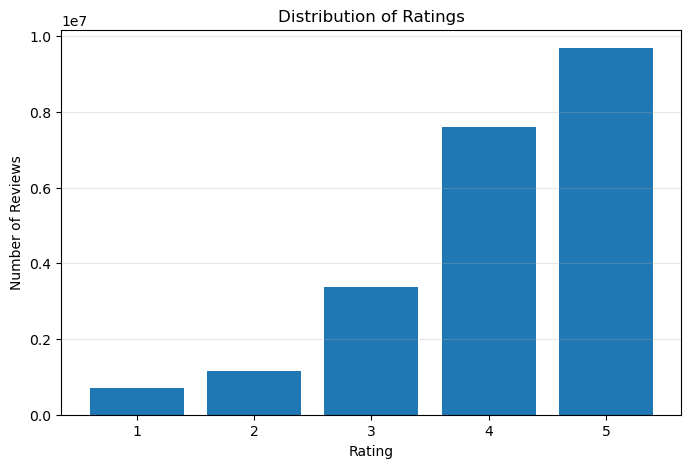

In [40]:
rating_dist = con.execute("""
SELECT
    rating,
    COUNT(*) AS reviews
FROM hotelrec_clean
GROUP BY rating
ORDER BY rating
""").fetchdf()

display(rating_dist)

plt.figure(figsize=(8,5))
plt.bar(rating_dist["rating"], rating_dist["reviews"])
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.title("Distribution of Ratings")
plt.grid(axis="y", alpha=0.3)
plt.show()

## User Activity Distribution
To check if every user has very few interactions as we found out the average user has about 11 reviews

In [41]:
user_reviews = con.execute("""
SELECT
COUNT(*) AS reviews
FROM hotelrec_clean WHERE user_id <> '/undefined' GROUP BY user_id
""").fetchdf()


user_reviews.describe()

,reviews
count,2.030352e+06
mean,1.050333e+01
std,9.434803e+00
min,4.000000e+00
25%,6.000000e+00
50%,7.000000e+00
75%,1.200000e+01
max,6.120000e+02


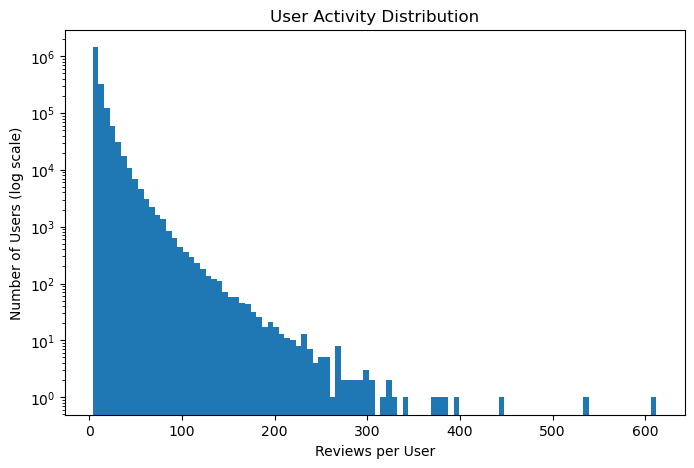

In [42]:
plt.figure(figsize=(8,5))

plt.hist(
    user_reviews["reviews"],
    bins=100,
    log=True
)

plt.xlabel("Reviews per User")
plt.ylabel("Number of Users (log scale)")
plt.title("User Activity Distribution")

plt.show()

## Hotel Popularity Distribution

In [43]:
hotel_reviews = con.execute("""
SELECT
COUNT(*) AS reviews
FROM hotelrec_clean
GROUP BY hotel_id
""").fetchdf()

hotel_reviews.describe()

,reviews
count,362455.000000
mean,62.127663
std,153.447570
min,1.000000
25%,7.000000
50%,18.000000
75%,57.000000
max,6673.000000


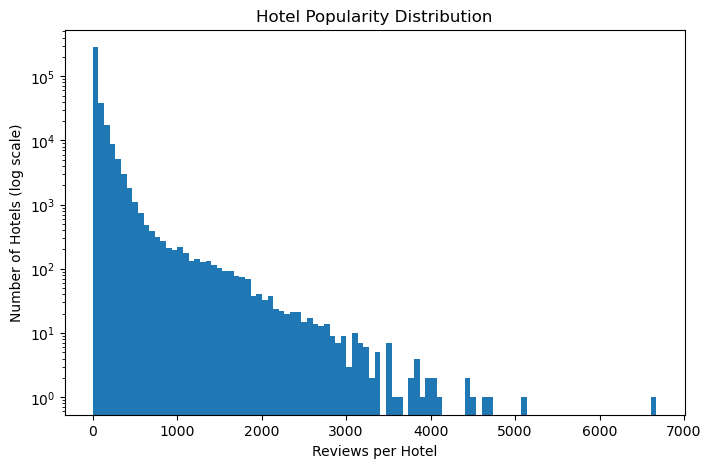

In [44]:
plt.figure(figsize=(8,5))

plt.hist(
    hotel_reviews["reviews"],
    bins=100,
    log=True
)

plt.xlabel("Reviews per Hotel")
plt.ylabel("Number of Hotels (log scale)")
plt.title("Hotel Popularity Distribution")

plt.show()

## Review Timeline

In [45]:
reviews_year = con.execute("""
SELECT
YEAR(date) AS year,
COUNT(*) AS reviews
FROM hotelrec_clean
GROUP BY year
ORDER BY year
""").fetchdf()

display(reviews_year)

,year,reviews
0,2001,226
1,2002,2888
2,2003,5670
3,2004,22403
4,2005,52904
5,2006,98982
6,2007,168084
7,2008,228563
8,2009,377136
9,2010,526494


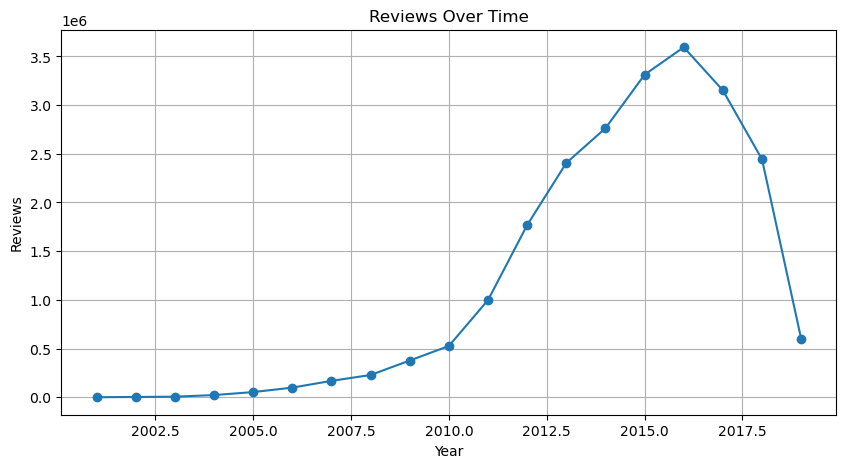

In [46]:
plt.figure(figsize=(10,5))

plt.plot(
    reviews_year["year"],
    reviews_year["reviews"],
    marker="o"
)

plt.title("Reviews Over Time")
plt.xlabel("Year")
plt.ylabel("Reviews")

plt.grid(True)

plt.show()

## Aspect Rating Distribution

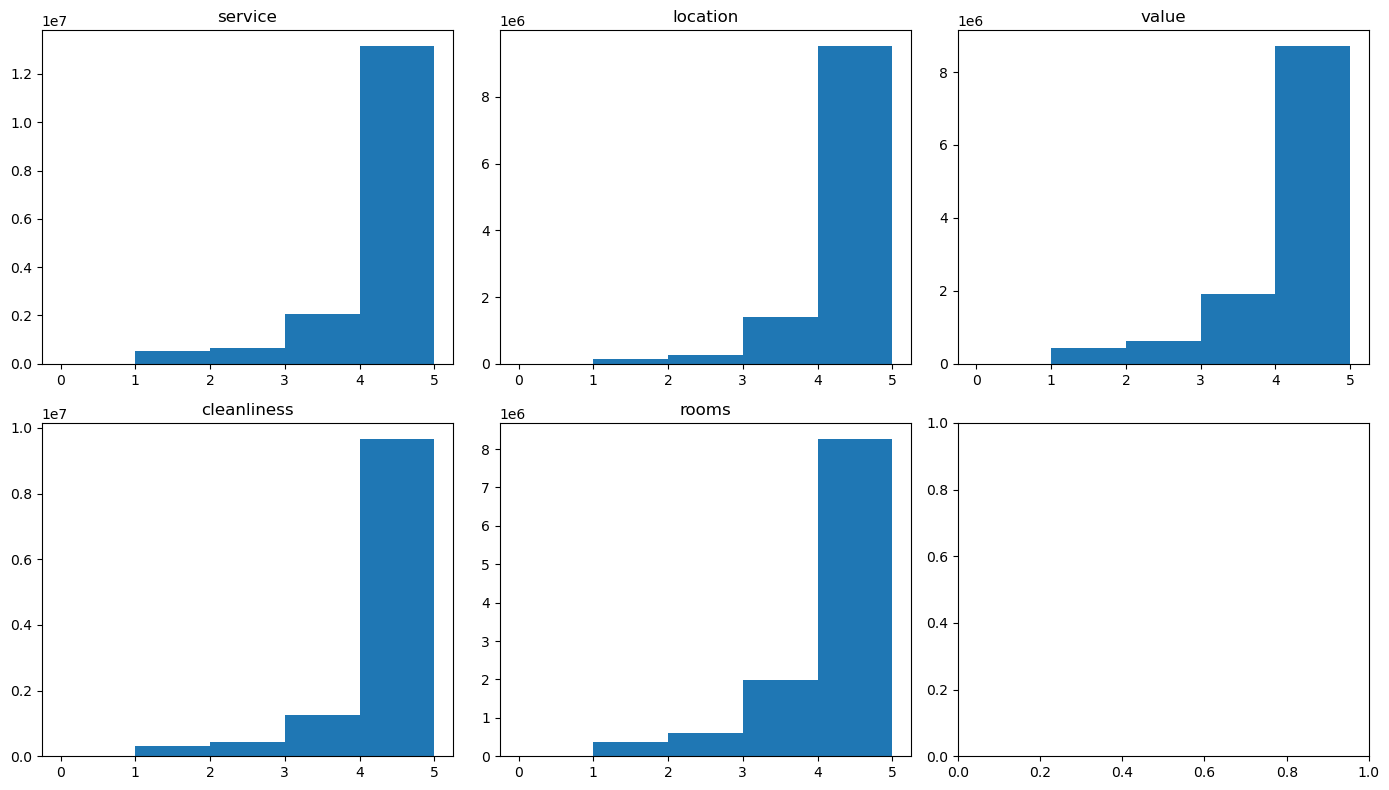

In [47]:
aspect_columns = [
    "service",
    "location",
    "value",
    "cleanliness",
    "rooms"
]

fig, axes = plt.subplots(2,3, figsize=(14,8))

axes = axes.flatten()

for i, col in enumerate(aspect_columns):

    data = con.execute(f"""
    SELECT {col}
    FROM hotelrec_clean
    WHERE {col} IS NOT NULL
    """).fetchdf()

    axes[i].hist(data[col], bins=5)

    axes[i].set_title(col)

plt.tight_layout()

plt.show()

## Review Length
To determine whether review text contains enough information for sentence embedding/

In [48]:
review_lengths = con.execute("""
SELECT
    LENGTH(text) AS characters,
    LENGTH(REGEXP_REPLACE(text, '\\s+', ' ', 'g')) AS cleaned_characters
FROM hotelrec_clean
WHERE text IS NOT NULL
""").fetchdf()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [49]:
review_lengths = con.execute("""
SELECT
    LENGTH(text) - LENGTH(REPLACE(text,' ','')) + 1 AS words
FROM hotelrec_clean
WHERE text IS NOT NULL
""").fetchdf()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [50]:
review_lengths.describe()

,words
count,2.251848e+07
mean,1.386544e+02
std,1.352570e+02
min,1.000000e+00
25%,6.000000e+01
50%,9.900000e+01
75%,1.670000e+02
max,1.165300e+04


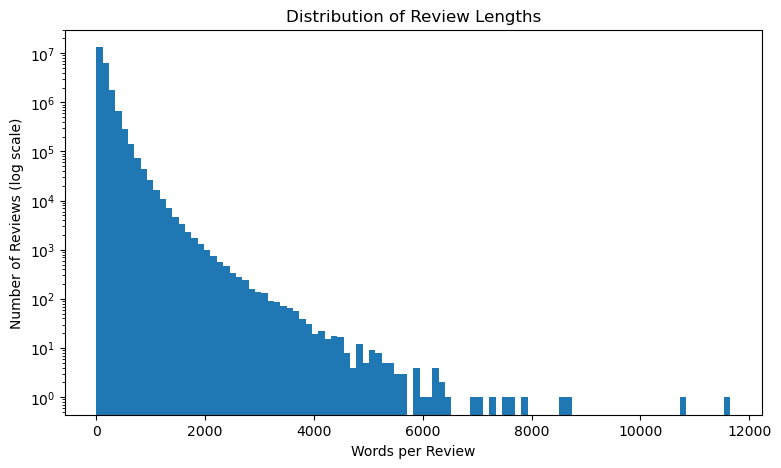

In [51]:
plt.figure(figsize=(9,5))

plt.hist(
    review_lengths["words"],
    bins=100,
    log=True
)

plt.xlabel("Words per Review")
plt.ylabel("Number of Reviews (log scale)")
plt.title("Distribution of Review Lengths")

plt.show()

# Feature Engineering

## Creating a model ready interaction table
Removing the /undefined users

In [52]:
con.execute("""
CREATE OR REPLACE TABLE model_interactions AS
SELECT
    user_id,
    hotel_id,
    rating,
    date
FROM hotelrec_clean
WHERE
    user_id IS NOT NULL
    AND hotel_id IS NOT NULL
    AND rating IS NOT NULL
    AND user_id <> '/undefined';
""")

print("model_interactions created")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

model_interactions created


In [53]:
interaction_overview = con.execute("""
SELECT
    COUNT(*) AS interactions,
    COUNT(DISTINCT user_id) AS users,
    COUNT(DISTINCT hotel_id) AS hotels,
    AVG(rating) AS average_rating
FROM model_interactions;
""").fetchdf()

interaction_overview

,interactions,users,hotels,average_rating
0,21325466,2030352,362400,4.107194


## Checking repeated user-hotel pairs

In [54]:
repeat_summary = con.execute("""
SELECT
    COUNT(*) AS repeated_pairs,
    SUM(interaction_count - 1) AS extra_interactions
FROM (
    SELECT
        user_id,
        hotel_id,
        COUNT(*) AS interaction_count
    FROM model_interactions
    GROUP BY user_id, hotel_id
    HAVING COUNT(*) > 1
);
""").fetchdf()

repeat_summary

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,repeated_pairs,extra_interactions
0,660551,884381.0


In [55]:
repeat_examples = con.execute("""
SELECT
    user_id,
    hotel_id,
    COUNT(*) AS interaction_count,
    MIN(date) AS first_date,
    MAX(date) AS latest_date,
    MIN(rating) AS minimum_rating,
    MAX(rating) AS maximum_rating
FROM model_interactions
GROUP BY user_id, hotel_id
HAVING COUNT(*) > 1
ORDER BY interaction_count DESC
LIMIT 20;
""").fetchdf()

repeat_examples

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,user_id,hotel_id,interaction_count,first_date,latest_date,minimum_rating,maximum_rating
0,maureendavies55,Hotel_Review-g187870-d229001-Reviews-Hotel_Sav...,23,2010-12-01,2018-07-01,5.0,5.0
1,1diva,Hotel_Review-g150812-d153142-Reviews-Royal_Hid...,22,2009-10-01,2019-03-01,5.0,5.0
2,larad427,Hotel_Review-g45963-d91907-Reviews-The_Orleans...,22,2011-01-01,2019-02-01,5.0,5.0
3,DarleyDaleGirl,Hotel_Review-g147290-d150764-Reviews-VH_Gran_V...,22,2010-01-01,2019-03-01,4.0,5.0
4,CINDYD412,Hotel_Review-g60853-d216925-Reviews-Best_Weste...,22,2012-12-01,2017-06-01,5.0,5.0
5,12brentm,Hotel_Review-g51463-d95710-Reviews-Best_Wester...,21,2015-01-01,2019-02-01,5.0,5.0
6,AlexanderS736,Hotel_Review-g190724-d6509096-Reviews-Lawton_L...,20,2011-12-01,2019-03-01,5.0,5.0
7,cheersmateStockport,Hotel_Review-g311425-d647908-Reviews-Three_Cor...,20,2010-05-01,2016-10-01,5.0,5.0
8,Dr-Bellamy,Hotel_Review-g48908-d75581-Reviews-Best_Wester...,20,2013-01-01,2018-07-01,5.0,5.0
9,Debi1979,Hotel_Review-g666384-d1537827-Reviews-Lakeside...,19,2011-08-01,2018-09-01,5.0,5.0


## Creating one interaction per user-hotel pair

In [56]:
con.execute("""
CREATE OR REPLACE TABLE unique_interactions AS
SELECT
    user_id,
    hotel_id,
    rating,
    date
FROM (
    SELECT
        user_id,
        hotel_id,
        rating,
        date,
        ROW_NUMBER() OVER (
            PARTITION BY user_id, hotel_id
            ORDER BY date DESC
        ) AS row_number
    FROM model_interactions
)
WHERE row_number = 1;
""")

print("unique_interactions created")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

unique_interactions created


In [57]:
unique_overview = con.execute("""
SELECT
    COUNT(*) AS interactions,
    COUNT(DISTINCT user_id) AS users,
    COUNT(DISTINCT hotel_id) AS hotels
FROM unique_interactions;
""").fetchdf()

unique_overview

,interactions,users,hotels
0,20441085,2030352,362400


## Encoding users and hotels
So that machine learning models can work directly with the integers.

### Creating user encoder

In [58]:
con.execute("""
CREATE OR REPLACE TABLE user_mapping AS
SELECT
    user_id,
    ROW_NUMBER() OVER (ORDER BY user_id) - 1 AS user_index
FROM (
    SELECT DISTINCT user_id
    FROM unique_interactions
);
""")

print("User mapping created")

User mapping created


### Creating hotel encoder

In [59]:
con.execute("""
CREATE OR REPLACE TABLE hotel_mapping AS
SELECT
    hotel_id,
    ROW_NUMBER() OVER (ORDER BY hotel_id) - 1 AS hotel_index
FROM (
    SELECT DISTINCT hotel_id
    FROM unique_interactions
);
""")

print("Hotel mapping created")

Hotel mapping created


### Validating user and hotel encoder

In [60]:
user_mapping_stats = con.execute("""
SELECT
COUNT(*) AS users,
MIN(user_index) AS min_index,
MAX(user_index) AS max_index
FROM user_mapping;
""").fetchdf()

hotel_mapping_stats = con.execute("""
SELECT
COUNT(*) AS hotels,
MIN(hotel_index) AS min_index,
MAX(hotel_index) AS max_index
FROM hotel_mapping;
""").fetchdf()

display(user_mapping_stats)
display(hotel_mapping_stats)

,users,min_index,max_index
0,2030352,0,2030351


,hotels,min_index,max_index
0,362400,0,362399


### Creating the encoded interaction table

In [61]:
con.execute("""
CREATE OR REPLACE TABLE encoded_interactions AS
SELECT
    u.user_index,
    h.hotel_index,
    i.rating,
    i.date
FROM unique_interactions i
JOIN user_mapping u
ON i.user_id = u.user_id
JOIN hotel_mapping h
ON i.hotel_id = h.hotel_id;
""")

print("Encoded interactions created")

Encoded interactions created


### Validating the encoded interaction table

In [62]:
encoded_stats = con.execute("""
SELECT
COUNT(*) AS interactions,
COUNT(DISTINCT user_index) AS users,
COUNT(DISTINCT hotel_index) AS hotels
FROM encoded_interactions;
""").fetchdf()

encoded_stats

,interactions,users,hotels
0,20441085,2030352,362400


In [63]:
encoded_df = con.execute("""
SELECT
    user_index,
    hotel_index,
    rating
FROM encoded_interactions
""").fetchdf()

encoded_df.head()

,user_index,hotel_index,rating
0,621256,103318,5.0
1,388676,103318,5.0
2,1384019,103318,4.0
3,2689,103318,4.0
4,220986,103318,5.0


In [64]:
encoded_df.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20441085 entries, 0 to 20441084
Data columns (total 3 columns):
 #   Column       Dtype  
---  ------       -----  
 0   user_index   int64  
 1   hotel_index  int64  
 2   rating       float64
dtypes: float64(1), int64(2)
memory usage: 467.9 MB


## Creating Sparse User-Item Matrix

In [65]:
interaction_matrix = csr_matrix(
    (
        encoded_df["rating"],
        (
            encoded_df["user_index"],
            encoded_df["hotel_index"]
        )
    )
)

In [66]:
print(interaction_matrix.shape)
print(interaction_matrix.nnz)

(2030352, 362400)
20441085


## Checking Sparsity

In [67]:
num_users, num_hotels = interaction_matrix.shape

possible = num_users * num_hotels
actual = interaction_matrix.nnz

density = actual / possible
sparsity = 1 - density

print(f"Users: {num_users:,}")
print(f"Hotels: {num_hotels:,}")
print(f"Ratings: {actual:,}")
print(f"Density: {density:.6%}")
print(f"Sparsity: {sparsity:.6%}")

Users: 2,030,352
Hotels: 362,400
Ratings: 20,441,085
Density: 0.002778%
Sparsity: 99.997222%


## Saving the matrix 
As it takes alot of time to run each time

In [68]:
save_npz(
    "../matrix/user_item_matrix.npz",
    interaction_matrix
)

# Train Test Data

## Creating the training table

In [69]:
con.execute("""
CREATE OR REPLACE TABLE train_interactions AS
SELECT
    user_index,
    hotel_index,
    rating,
    date
FROM (
    SELECT *,
           ROW_NUMBER() OVER (
               PARTITION BY user_index
               ORDER BY date DESC
           ) AS rn
    FROM encoded_interactions
)
WHERE rn > 1;
""")

print("Training table created.")

Training table created.


## Creating the testing table

In [70]:
con.execute("""
CREATE OR REPLACE TABLE test_interactions AS
SELECT
    user_index,
    hotel_index,
    rating,
    date
FROM (
    SELECT *,
           ROW_NUMBER() OVER (
               PARTITION BY user_index
               ORDER BY date DESC
           ) AS rn
    FROM encoded_interactions
)
WHERE rn = 1;
""")

print("Testing table created.")

Testing table created.


## Verifying the split

In [71]:
train_stats = con.execute("""
SELECT
    COUNT(*) AS interactions,
    COUNT(DISTINCT user_index) AS users,
    COUNT(DISTINCT hotel_index) AS hotels
FROM train_interactions;
""").fetchdf()

test_stats = con.execute("""
SELECT
    COUNT(*) AS interactions,
    COUNT(DISTINCT user_index) AS users,
    COUNT(DISTINCT hotel_index) AS hotels
FROM test_interactions;
""").fetchdf()

display(train_stats)
display(test_stats)

,interactions,users,hotels
0,18410733,2027012,360504


,interactions,users,hotels
0,2030352,2030352,261426


**Checking if every user has one test interaction**

In [72]:
test_check = con.execute("""
SELECT
    MIN(c) AS minimum_test_reviews,
    MAX(c) AS maximum_test_reviews
FROM (
    SELECT
        user_index,
        COUNT(*) AS c
    FROM test_interactions
    GROUP BY user_index
);
""").fetchdf()

display(test_check)

,minimum_test_reviews,maximum_test_reviews
0,1,1


## Checking for Overlap

In [73]:
overlap = con.execute("""
SELECT COUNT(*) AS overlap_rows
FROM train_interactions t
JOIN test_interactions s
ON t.user_index = s.user_index
AND t.hotel_index = s.hotel_index;
""").fetchdf()

display(overlap)

,overlap_rows
0,287982


**Split not valid** 

292501 user-hotel pairs appear in both train and test, this occured because the train and test tables were created with two separate ranking operations. Also there is a gap of 3,340 usershave no training history after repeated hotel visits were collapsed and collaborative filtering cannot generate personalized recommendations for those users.

## Cerating one deterministic ranked table

Using the hotel index as a tie-breaker when two interactions have the same date, and this performs the ranking once, so train and test cannot disagree.

In [74]:
con.execute("""
CREATE OR REPLACE TABLE ranked_interactions AS
SELECT
    user_index,
    hotel_index,
    rating,
    date,
    ROW_NUMBER() OVER (
        PARTITION BY user_index
        ORDER BY date DESC, hotel_index DESC
    ) AS interaction_rank,
    COUNT(*) OVER (
        PARTITION BY user_index
    ) AS user_interaction_count
FROM encoded_interactions;
""")

print("Ranked interactions created")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Ranked interactions created


## Keeping users with at least two unique hotels

This is required as the 3,340 users with no usable hostory will be removed, this is necessary for the collaborative-filtering evaluation

In [75]:
con.execute("""
CREATE OR REPLACE TABLE eligible_ranked_interactions AS
SELECT *
FROM ranked_interactions
WHERE user_interaction_count >= 2;
""")

print("Eligible interactions created")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Eligible interactions created


## Recreating the test set

In [76]:
con.execute("""
CREATE OR REPLACE TABLE test_interactions AS
SELECT
    user_index,
    hotel_index,
    rating,
    date
FROM eligible_ranked_interactions
WHERE interaction_rank = 1;
""")

print("Test set recreated")

Test set recreated


## Recreating the training set

In [77]:
con.execute("""
CREATE OR REPLACE TABLE train_interactions AS
SELECT
    user_index,
    hotel_index,
    rating,
    date
FROM eligible_ranked_interactions
WHERE interaction_rank > 1;
""")

print("Training set recreated")

Training set recreated


## Validating the final split

In [78]:
train_stats = con.execute("""
SELECT
    COUNT(*) AS interactions,
    COUNT(DISTINCT user_index) AS users,
    COUNT(DISTINCT hotel_index) AS hotels
FROM train_interactions;
""").fetchdf()

test_stats = con.execute("""
SELECT
    COUNT(*) AS interactions,
    COUNT(DISTINCT user_index) AS users,
    COUNT(DISTINCT hotel_index) AS hotels
FROM test_interactions;
""").fetchdf()

display(train_stats)
display(test_stats)

,interactions,users,hotels
0,18410733,2027012,360485


,interactions,users,hotels
0,2027012,2027012,262367


In [79]:
overlap = con.execute("""
SELECT COUNT(*) AS overlap_rows
FROM train_interactions AS train
INNER JOIN test_interactions AS test
    ON train.user_index = test.user_index
   AND train.hotel_index = test.hotel_index;
""").fetchdf()

overlap

,overlap_rows
0,0


## Checking test hotels that never appeared in training

In [80]:
unseen_test_hotels = con.execute("""
SELECT
    COUNT(*) AS test_interactions_with_unseen_hotels,
    COUNT(DISTINCT test.hotel_index) AS unseen_hotels
FROM test_interactions AS test
LEFT JOIN (
    SELECT DISTINCT hotel_index
    FROM train_interactions
) AS train_hotels
    ON test.hotel_index = train_hotels.hotel_index
WHERE train_hotels.hotel_index IS NULL;
""").fetchdf()

unseen_test_hotels

,test_interactions_with_unseen_hotels,unseen_hotels
0,3212,1914


# Machine learning Models

**Creating test set excluding the 3212 test interaction which never appeared in training**

In [81]:
con.execute("""
CREATE OR REPLACE TABLE warm_test_interactions AS
SELECT test.*
FROM test_interactions AS test
INNER JOIN (
    SELECT DISTINCT hotel_index
    FROM train_interactions
) AS train_hotels
    ON test.hotel_index = train_hotels.hotel_index;
""")

warm_test_stats = con.execute("""
SELECT
    COUNT(*) AS interactions,
    COUNT(DISTINCT user_index) AS users,
    COUNT(DISTINCT hotel_index) AS hotels
FROM warm_test_interactions;
""").fetchdf()

warm_test_stats

,interactions,users,hotels
0,2023800,2023800,260453


## Popularity Baseline

In [82]:
con.execute("""
CREATE OR REPLACE TABLE popularity_scores AS
SELECT
    hotel_index,
    COUNT(*) AS interaction_count,
    AVG(rating) AS average_rating
FROM train_interactions
GROUP BY hotel_index;
""")

popularity_preview = con.execute("""
SELECT *
FROM popularity_scores
ORDER BY interaction_count DESC
LIMIT 10;
""").fetchdf()

popularity_preview

,hotel_index,interaction_count,average_rating
0,63145,4831,4.273235
1,41442,4127,3.994185
2,63526,3886,4.185280
3,165782,3877,4.544493
4,154165,3875,4.747097
5,313118,3537,3.703138
6,249768,3526,3.983834
7,165778,3490,4.130086
8,92546,3483,4.256675
9,313137,3313,3.747057


### Most popular hotels

In [83]:
top_popular_hotels = con.execute("""
SELECT
    p.hotel_index,
    p.interaction_count,
    p.average_rating,
    h.hotel_id
FROM popularity_scores AS p
LEFT JOIN hotel_mapping AS h
    ON p.hotel_index = h.hotel_index
ORDER BY p.interaction_count DESC
LIMIT 20;
""").fetchdf()

top_popular_hotels

,hotel_index,interaction_count,average_rating,hotel_id
0,63145,4831,4.273235,Hotel_Review-g187051-d243420-Reviews-Sofitel_L...
1,41442,4127,3.994185,Hotel_Review-g154998-d278011-Reviews-Embassy_S...
2,63526,3886,4.185280,Hotel_Review-g187069-d210728-Reviews-Radisson_...
3,165782,3877,4.544493,Hotel_Review-g294265-d302294-Reviews-Pan_Pacif...
4,154165,3875,4.747097,Hotel_Review-g293924-d299548-Reviews-Sofitel_L...
5,313118,3537,3.703138,Hotel_Review-g60763-d93450-Reviews-Grand_Hyatt...
6,249768,3526,3.983834,Hotel_Review-g35805-d87617-Reviews-Hyatt_Regen...
7,165778,3490,4.130086,Hotel_Review-g294265-d301573-Reviews-Swissotel...
8,92546,3483,4.256675,Hotel_Review-g188590-d1946024-Reviews-DoubleTr...
9,313137,3313,3.747057,Hotel_Review-g60763-d93555-Reviews-Sheraton_Ne...


**Creating a reproducible evaluation sample**

Starting with 50,000 users, after confirming that the evaluation works, the users will be increased.

In [84]:
evaluation_users = con.execute("""
SELECT
    user_index,
    hotel_index AS positive_hotel
FROM warm_test_interactions
USING SAMPLE 50000 ROWS (reservoir, 42);
""").fetchdf()

print(evaluation_users.shape)
evaluation_users.head()

(50000, 2)


,user_index,positive_hotel
0,902891,273945
1,1604715,56781
2,665747,100504
3,566774,99150
4,1765013,126685


### Loading hotel popularity

In [85]:
popularity_df = con.execute("""
SELECT
    hotel_index,
    interaction_count
FROM popularity_scores;
""").fetchdf()

popularity_lookup = dict(
    zip(
        popularity_df["hotel_index"].astype(int),
        popularity_df["interaction_count"].astype(float)
    )
)

all_train_hotels = popularity_df["hotel_index"].astype(int).to_numpy()

print("Hotels available for recommendation:", len(all_train_hotels))

Hotels available for recommendation: 360485


### Loading each sampled user's training history

This records which hotels each sampled user already interacted with, these hotels must not be included as negative candidates.

In [86]:
sampled_user_ids = evaluation_users["user_index"].astype(int).tolist()

con.register(
    "sampled_users_df",
    evaluation_users[["user_index"]]
)

sampled_histories = con.execute("""
SELECT
    train.user_index,
    train.hotel_index
FROM train_interactions AS train
INNER JOIN sampled_users_df AS sampled
    ON train.user_index = sampled.user_index;
""").fetchdf()

user_history = (
    sampled_histories
    .groupby("user_index")["hotel_index"]
    .apply(lambda values: set(values.astype(int)))
    .to_dict()
)

print("User histories loaded:", len(user_history))

User histories loaded: 50000


### Generating 99 negatives per user

Now, each user has:
- 1 positive hotel
- 99 negative hotels
- 100 candidate hotels total

In [87]:
rng = np.random.default_rng(42)

negative_count = 99
candidate_sets = []

for row in evaluation_users.itertuples(index=False):
    user_index = int(row.user_index)
    positive_hotel = int(row.positive_hotel)

    seen_hotels = user_history.get(user_index, set())
    excluded_hotels = seen_hotels | {positive_hotel}

    negatives = []

    while len(negatives) < negative_count:
        sampled_hotel = int(rng.choice(all_train_hotels))

        if (
            sampled_hotel not in excluded_hotels
            and sampled_hotel not in negatives
        ):
            negatives.append(sampled_hotel)

    candidate_sets.append({
        "user_index": user_index,
        "positive_hotel": positive_hotel,
        "negative_hotels": negatives
    })

print("Candidate sets created:", len(candidate_sets))

Candidate sets created: 50000


### Defining function to rank candidates using popularity

In [88]:
def popularity_recommendations(
    positive_hotel: int,
    negative_hotels: list[int],
) -> list[int]:
    candidates = [positive_hotel] + negative_hotels

    return sorted(
        candidates,
        key=lambda hotel: (
            popularity_lookup.get(hotel, 0.0),
            -hotel
        ),
        reverse=True
    )

### Defining function for HR and NDCG

In [89]:
def hit_ratio_at_k(
    ranked_hotels: list[int],
    positive_hotel: int,
    k: int,
) -> float:
    return float(positive_hotel in ranked_hotels[:k])


def ndcg_at_k(
    ranked_hotels: list[int],
    positive_hotel: int,
    k: int,
) -> float:
    top_k = ranked_hotels[:k]

    if positive_hotel not in top_k:
        return 0.0

    rank = top_k.index(positive_hotel) + 1
    return 1.0 / math.log2(rank + 1)

### Evaluating the popularity baseline

In [90]:
results = {
    "HR@5": [],
    "NDCG@5": [],
    "HR@10": [],
    "NDCG@10": [],
    "HR@20": [],
    "NDCG@20": [],
}

for candidate in candidate_sets:
    positive_hotel = candidate["positive_hotel"]

    ranked_hotels = popularity_recommendations(
        positive_hotel=positive_hotel,
        negative_hotels=candidate["negative_hotels"],
    )

    for k in [5, 10, 20]:
        results[f"HR@{k}"].append(
            hit_ratio_at_k(ranked_hotels, positive_hotel, k)
        )

        results[f"NDCG@{k}"].append(
            ndcg_at_k(ranked_hotels, positive_hotel, k)
        )

In [91]:
popularity_results = pd.DataFrame({
    metric: [np.mean(values)]
    for metric, values in results.items()
})

popularity_results.insert(0, "model", "Popularity")

popularity_results

,model,HR@5,NDCG@5,HR@10,NDCG@10,HR@20,NDCG@20
0,Popularity,0.38724,0.276828,0.52908,0.322516,0.69918,0.36547


### Saving the evaluation sample

The same users and negative candidates must be used for every model so the comparision is fair.

In [92]:
with open("evaluation_candidates_50k.pkl", "wb") as file:
    pickle.dump(candidate_sets, file)

popularity_results.to_csv(
    "popularity_baseline_results.csv",
    index=False
)

print("Evaluation candidates and baseline results saved.")

Evaluation candidates and baseline results saved.


## Item Collaborative Filtering

**Checking if there are enough inteactions in the training data**

In [93]:
hotel_train_counts = con.execute("""
SELECT
    hotel_index,
    COUNT(*) AS interaction_count
FROM train_interactions
GROUP BY hotel_index
""").fetchdf()

hotel_train_counts.describe()

,hotel_index,interaction_count
count,360485.000000,360485.000000
mean,181140.361188,51.072120
std,104583.869339,125.445851
min,0.000000,1.000000
25%,90549.000000,6.000000
50%,181133.000000,16.000000
75%,271712.000000,48.000000
max,362399.000000,4831.000000


**Choosing the threshold to use to create an ItemCF-specific subset**

In [94]:
thresholds = [5, 10, 20, 50, 100]

for threshold in thresholds:
    count = (hotel_train_counts["interaction_count"] >= threshold).sum()
    print(f"Hotels with >= {threshold} interactions: {count:,}")

Hotels with >= 5 interactions: 299,002
Hotels with >= 10 interactions: 226,837
Hotels with >= 20 interactions: 160,062
Hotels with >= 50 interactions: 87,428
Hotels with >= 100 interactions: 45,703


**From the threshold test we can see that 50 interaction is the best for this pipeline as**
- 87,428 hotels is a large catalogue not too large not too small.
- Every hotel has sufficient history to calculate cosine similarity.
- And the runtime is more manageable.

### ItemCF dataset
**Creating a table containing only the hotels with >=50 interactions(87,428)**

In [95]:
con.execute("""
CREATE OR REPLACE TABLE itemcf_train AS

SELECT t.*
FROM train_interactions t

JOIN (
    SELECT hotel_index
    FROM train_interactions
    GROUP BY hotel_index
    HAVING COUNT(*) >= 50
) h

ON t.hotel_index = h.hotel_index;
""")

print("ItemCF training table created.")

ItemCF training table created.


### Verifying the size

In [96]:
itemcf_stats = con.execute("""
SELECT
    COUNT(*) AS interactions,
    COUNT(DISTINCT user_index) AS users,
    COUNT(DISTINCT hotel_index) AS hotels
FROM itemcf_train;
""").fetchdf()

itemcf_stats

,interactions,users,hotels
0,14530252,2012814,87428


### Building the sparse matrix

#### Creating the interaction matrix

In [97]:
itemcf_df = con.execute("""
SELECT
    user_index,
    hotel_index,
    rating
FROM itemcf_train
""").fetchdf()

itemcf_df.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14530252 entries, 0 to 14530251
Data columns (total 3 columns):
 #   Column       Dtype  
---  ------       -----  
 0   user_index   int64  
 1   hotel_index  int64  
 2   rating       float64
dtypes: float64(1), int64(2)
memory usage: 332.6 MB


#### Building the sparse matrix

In [98]:
item_matrix = csr_matrix(
    (
        itemcf_df["rating"],
        (
            itemcf_df["hotel_index"],
            itemcf_df["user_index"]
        )
    )
)

print(item_matrix.shape)
print(item_matrix.nnz)

(362394, 2030352)
14530252


#### Checking sparsity
**Table contained 87,428 hotels but the sparse matrix shows 362,394 hotels this is wasting RAM and slowing the operation.**

In [99]:
num_hotels, num_users = item_matrix.shape

possible = num_hotels * num_users
actual = item_matrix.nnz

density = actual / possible
sparsity = 1 - density

print(f"Hotels: {num_hotels:,}")
print(f"Users: {num_users:,}")
print(f"Ratings: {actual:,}")
print(f"Density: {density:.6%}")
print(f"Sparsity: {sparsity:.6%}")

Hotels: 362,394
Users: 2,030,352
Ratings: 14,530,252
Density: 0.001975%
Sparsity: 99.998025%


#### Creating a compact ItemCF hotel mapping
**To fix the hotel size problem**

In [100]:
con.execute("""
CREATE OR REPLACE TABLE itemcf_hotel_mapping AS

SELECT
    hotel_index,
    ROW_NUMBER() OVER (ORDER BY hotel_index) - 1 AS itemcf_hotel_index
FROM (
    SELECT DISTINCT hotel_index
    FROM itemcf_train
);
""")

print("ItemCF hotel mapping created.")

ItemCF hotel mapping created.


#### Verifying the mapping

In [101]:
mapping_stats = con.execute("""
SELECT
    COUNT(*) AS hotels,
    MIN(itemcf_hotel_index) AS min_index,
    MAX(itemcf_hotel_index) AS max_index
FROM itemcf_hotel_mapping;
""").fetchdf()

mapping_stats

,hotels,min_index,max_index
0,87428,0,87427


#### Creating the encoded ItemCF table

In [102]:
con.execute("""
CREATE OR REPLACE TABLE itemcf_encoded AS

SELECT
    t.user_index,
    m.itemcf_hotel_index,
    t.rating
FROM itemcf_train t

JOIN itemcf_hotel_mapping m
ON t.hotel_index = m.hotel_index;
""")

print("Encoded ItemCF table created.")

Encoded ItemCF table created.


#### Lodaing the encoded table into pandas

In [103]:
itemcf_encoded = con.execute("""
SELECT
    user_index,
    itemcf_hotel_index,
    rating
FROM itemcf_encoded;
""").fetchdf()

itemcf_encoded.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14530252 entries, 0 to 14530251
Data columns (total 3 columns):
 #   Column              Dtype  
---  ------              -----  
 0   user_index          int64  
 1   itemcf_hotel_index  int64  
 2   rating              float64
dtypes: float64(1), int64(2)
memory usage: 332.6 MB


#### Final Sparse matrix

In [104]:
item_matrix = csr_matrix(
    (
        itemcf_encoded["rating"],
        (
            itemcf_encoded["itemcf_hotel_index"],
            itemcf_encoded["user_index"]
        )
    )
)

print(item_matrix.shape)
print(item_matrix.nnz)

(87428, 2030352)
14530252


#### Verifying the sparsity

In [105]:
num_hotels, num_users = item_matrix.shape

possible = num_hotels * num_users
actual = item_matrix.nnz

density = actual / possible
sparsity = 1 - density

print(f"Hotels: {num_hotels:,}")
print(f"Users: {num_users:,}")
print(f"Ratings: {actual:,}")
print(f"Density: {density:.6%}")
print(f"Sparsity: {sparsity:.6%}")

Hotels: 87,428
Users: 2,030,352
Ratings: 14,530,252
Density: 0.008186%
Sparsity: 99.991814%


### Reduce memory and normalize hotel vectors

In [106]:
item_matrix = item_matrix.astype(np.float32)

item_matrix_norm = normalize(
    item_matrix,
    norm="l2",
    axis=1,
    copy=True
)

print(item_matrix_norm.shape)
print(item_matrix_norm.nnz)
print(item_matrix_norm.dtype)

(87428, 2030352)
14530252
float32


### Testing on sample 1000 hotel

In [107]:
test_items = item_matrix_norm[:1000]

start = time.time()

test_similarity = sp_matmul_topn(
    test_items,
    item_matrix_norm.T,
    top_n=51,
    threshold=0.0,
    sort=True,
    n_threads=4
)

elapsed = time.time() - start

print("Shape:", test_similarity.shape)
print("Stored similarities:", test_similarity.nnz)
print(f"Time: {elapsed:.2f} seconds")

Shape: (1000, 87428)
Stored similarities: 51000
Time: 0.34 seconds


In [108]:
hotel = 0

start = test_similarity.indptr[hotel]
end = test_similarity.indptr[hotel + 1]

neighbor_indices = test_similarity.indices[start:end]
similarities = test_similarity.data[start:end]

print("Hotel:", hotel)

for idx, similarity in zip(
    neighbor_indices[:10],
    similarities[:10]
):
    print(
        f"Similar hotel: {idx}, "
        f"cosine similarity: {similarity:.4f}"
    )

Hotel: 0
Similar hotel: 0, cosine similarity: 1.0000
Similar hotel: 6, cosine similarity: 0.0213
Similar hotel: 4843, cosine similarity: 0.0187
Similar hotel: 4833, cosine similarity: 0.0167
Similar hotel: 4930, cosine similarity: 0.0166
Similar hotel: 5, cosine similarity: 0.0161
Similar hotel: 4774, cosine similarity: 0.0159
Similar hotel: 8, cosine similarity: 0.0154
Similar hotel: 31044, cosine similarity: 0.0148
Similar hotel: 54295, cosine similarity: 0.0141


### Building the ItemCF model

In [109]:
start = time.time()

item_similarity = sp_matmul_topn(
    item_matrix_norm,
    item_matrix_norm.T,
    top_n=51,          # self + top 50 neighbours
    threshold=0.0,
    sort=True,
    n_threads=4
)

elapsed = time.time() - start

print(item_similarity.shape)
print(item_similarity.nnz)
print(f"Finished in {elapsed:.2f} seconds")

(87428, 87428)
4458828
Finished in 1.37 seconds


### Svaing the model
We are implementing top-50 item based collaborative filtering because:
- each hotel only remembers its 50 nearest neighbours
- memory stays thin and recommendation are generated fast

In [110]:
save_npz(
    "../matrix/item_similarity_top50.npz",
    item_similarity
)

print("Similarity matrix saved.")

Similarity matrix saved.


### Computing the complete ItemCF similarity matrix

In [111]:
start = time.time()

item_similarity = sp_matmul_topn(
    item_matrix_norm,
    item_matrix_norm.T,
    top_n=51,          # self + top 50 neighbours
    threshold=0.0,
    sort=True,
    n_threads=4
)

elapsed = time.time() - start

print(item_similarity.shape)
print(item_similarity.nnz)
print(f"Finished in {elapsed:.2f} seconds")

(87428, 87428)
4458828
Finished in 1.39 seconds


### Saving the model

In [112]:
save_npz(
    "../matrix/item_similarity_top50.npz",
    item_similarity
)

print("Similarity matrix saved.")

Similarity matrix saved.


In [113]:
hotel = np.random.randint(item_similarity.shape[0])

start = item_similarity.indptr[hotel]
end = item_similarity.indptr[hotel + 1]

neighbors = item_similarity.indices[start:end]
scores = item_similarity.data[start:end]

print(f"Hotel {hotel}")

for n, s in zip(neighbors[:10], scores[:10]):
    print(f"{n:6d}  {s:.4f}")

Hotel 37472
 37472  1.0000
 44652  0.0283
 63086  0.0262
 26832  0.0248
 37014  0.0239
 10380  0.0235
 35656  0.0204
 66347  0.0202
 37057  0.0201
 84000  0.0195


### Creating recommendor

In [114]:
itemcf_mapping = con.execute("""
SELECT
    hotel_index,
    itemcf_hotel_index
FROM itemcf_hotel_mapping
""").fetchdf()

global_to_itemcf = dict(
    zip(
        itemcf_mapping.hotel_index,
        itemcf_mapping.itemcf_hotel_index
    )
)

itemcf_to_global = dict(
    zip(
        itemcf_mapping.itemcf_hotel_index,
        itemcf_mapping.hotel_index
    )
)

print(len(global_to_itemcf))

87428


In [115]:
sample_user = int(evaluation_users.iloc[0]["user_index"])

history = con.execute(f"""
SELECT
    hotel_index,
    rating
FROM train_interactions
WHERE user_index={sample_user}
""").fetchdf()

history

,hotel_index,rating
0,312249,5.0
1,296667,5.0
2,314710,1.0
3,314697,5.0


#### Defining the recommendation function

In [116]:
def recommend_itemcf(history_df,
                     top_k=20,
                     neighbours=50):

    scores = defaultdict(float)

    seen = set(history_df.hotel_index.astype(int))

    for row in history_df.itertuples(index=False):
        

        hotel = int(row.hotel_index)
        rating = float(row.rating)

        if hotel not in global_to_itemcf:
            continue

        idx = global_to_itemcf[hotel]

        start = item_similarity.indptr[idx]
        end = item_similarity.indptr[idx+1]

        neighbour_ids = item_similarity.indices[start:end]
        similarities = item_similarity.data[start:end]

        for n, sim in zip(neighbour_ids, similarities):

            if n == idx:
                continue

            global_hotel = itemcf_to_global[int(n)]

            if global_hotel in seen:
                continue

            scores[global_hotel] += sim * rating

    ranked = sorted(
        scores.items(),
        key=lambda x: x[1],
        reverse=True
    )

    return ranked[:top_k]

In [117]:
recommendations = recommend_itemcf(history)

recommendations[:10]

[(296596, np.float32(0.46852434)),
 (314704, np.float32(0.23954438)),
 (296728, np.float32(0.23662987)),
 (314685, np.float32(0.2361275)),
 (296684, np.float32(0.22119081)),
 (296633, np.float32(0.21410283)),
 (314706, np.float32(0.19671941)),
 (292737, np.float32(0.18325907)),
 (296618, np.float32(0.17967574)),
 (314484, np.float32(0.17755242))]

In [118]:
itemcf_results = {
    "HR@5": [],
    "NDCG@5": [],
    "HR@10": [],
    "NDCG@10": [],
    "HR@20": [],
    "NDCG@20": [],
}

for candidate in candidate_sets:
    user_index = candidate["user_index"]
    positive_hotel = candidate["positive_hotel"]
    negative_hotels = candidate["negative_hotels"]

    history_df = con.execute(f"""
    SELECT
        hotel_index,
        rating
    FROM train_interactions
    WHERE user_index = {user_index}
    """).fetchdf()

    ranked_recommendations = recommend_itemcf(
        history_df,
        top_k=100
    )

    score_lookup = dict(ranked_recommendations)

    candidates = [positive_hotel] + negative_hotels

    ranked_candidates = sorted(
        candidates,
        key=lambda hotel: score_lookup.get(hotel, 0.0),
        reverse=True
    )

    for k in [5, 10, 20]:

        hit = float(
            positive_hotel in ranked_candidates[:k]
        )

        itemcf_results[f"HR@{k}"].append(hit)

        if positive_hotel in ranked_candidates[:k]:
            rank = ranked_candidates[:k].index(positive_hotel) + 1
            ndcg = 1.0 / math.log2(rank + 1)
        else:
            ndcg = 0.0

        itemcf_results[f"NDCG@{k}"].append(ndcg)


itemcf_results_df = pd.DataFrame({
    metric: [np.mean(values)]
    for metric, values in itemcf_results.items()
})

itemcf_results_df.insert(
    0,
    "model",
    "ItemCF"
)

itemcf_results_df

,model,HR@5,NDCG@5,HR@10,NDCG@10,HR@20,NDCG@20
0,ItemCF,1.0,0.990803,1.0,0.990803,1.0,0.990803


In [119]:
sampled_users_for_itemcf = evaluation_users[["user_index"]].copy()

con.register(
    "sampled_users_itemcf",
    sampled_users_for_itemcf
)

itemcf_histories_df = con.execute("""
SELECT
    t.user_index,
    t.hotel_index,
    t.rating
FROM train_interactions AS t
INNER JOIN sampled_users_itemcf AS s
    ON t.user_index = s.user_index
""").fetchdf()

print(itemcf_histories_df.shape)
itemcf_histories_df.head()

(454017, 3)


,user_index,hotel_index,rating
0,202306,255456,4.0
1,202306,225215,5.0
2,202306,95253,5.0
3,202306,308599,3.0
4,202306,308446,5.0


In [120]:
itemcf_user_histories = {}

for user_index, group in itemcf_histories_df.groupby("user_index"):
    itemcf_user_histories[int(user_index)] = list(
        zip(
            group["hotel_index"].astype(int),
            group["rating"].astype(float)
        )
    )

print("Histories loaded:", len(itemcf_user_histories))

Histories loaded: 50000


#### Defining a function that produces ItemCF scores 
**without truncating them to the top 100 first**

In [121]:
def get_itemcf_scores(user_history):
    scores = defaultdict(float)

    seen_hotels = {
        hotel
        for hotel, rating in user_history
    }

    for hotel, rating in user_history:

        if hotel not in global_to_itemcf:
            continue

        item_idx = global_to_itemcf[hotel]

        start = item_similarity.indptr[item_idx]
        end = item_similarity.indptr[item_idx + 1]

        neighbour_ids = item_similarity.indices[start:end]
        similarities = item_similarity.data[start:end]

        for neighbour_idx, similarity in zip(
            neighbour_ids,
            similarities
        ):
            if neighbour_idx == item_idx:
                continue

            global_hotel = int(
                itemcf_to_global[int(neighbour_idx)]
            )

            if global_hotel in seen_hotels:
                continue

            scores[global_hotel] += (
                float(similarity) * float(rating)
            )

    return scores

### Evaluation

In [122]:
rng_itemcf = np.random.default_rng(42)

itemcf_results = {
    "HR@5": [],
    "NDCG@5": [],
    "HR@10": [],
    "NDCG@10": [],
    "HR@20": [],
    "NDCG@20": [],
}

positive_scored = 0

for candidate in candidate_sets:

    user_index = int(candidate["user_index"])
    positive_hotel = int(candidate["positive_hotel"])

    user_history = itemcf_user_histories[user_index]

    score_lookup = get_itemcf_scores(user_history)

    if score_lookup.get(positive_hotel, 0.0) > 0:
        positive_scored += 1

    candidates = np.array(
        [positive_hotel] + candidate["negative_hotels"],
        dtype=int
    )

    # Random, reproducible tie-breaking
    rng_itemcf.shuffle(candidates)

    ranked_candidates = sorted(
        candidates,
        key=lambda hotel: score_lookup.get(int(hotel), 0.0),
        reverse=True
    )

    for k in [5, 10, 20]:

        top_k = ranked_candidates[:k]

        hit = float(
            positive_hotel in top_k
        )

        itemcf_results[f"HR@{k}"].append(hit)

        if hit:
            rank = top_k.index(positive_hotel) + 1
            ndcg = 1.0 / math.log2(rank + 1)
        else:
            ndcg = 0.0

        itemcf_results[f"NDCG@{k}"].append(ndcg)

### Summary of evaluation metrics

In [123]:
itemcf_results_df = pd.DataFrame({
    metric: [np.mean(values)]
    for metric, values in itemcf_results.items()
})

itemcf_results_df.insert(
    0,
    "model",
    "ItemCF"
)

print(
    f"Positive test hotel received an ItemCF score for "
    f"{positive_scored:,} / {len(candidate_sets):,} users "
    f"({100 * positive_scored / len(candidate_sets):.2f}%)"
)

itemcf_results_df

Positive test hotel received an ItemCF score for 6,071 / 50,000 users (12.14%)


,model,HR@5,NDCG@5,HR@10,NDCG@10,HR@20,NDCG@20
0,ItemCF,0.1666,0.146314,0.21132,0.160577,0.30002,0.182721


### Sensitivity analysis on ItemCF

Goal: To check if using threshold as 50 is restricting the coverage.

In [124]:
start = time.time()

item_similarity_200 = sp_matmul_topn(
    item_matrix_norm,
    item_matrix_norm.T,
    top_n=201,        # self + top 200 neighbours
    threshold=0.0,
    sort=True,
    n_threads=4
)

elapsed = time.time() - start

print("Shape:", item_similarity_200.shape)
print("Stored similarities:", item_similarity_200.nnz)
print(f"Time: {elapsed:.2f} seconds")

Shape: (87428, 87428)
Stored similarities: 17572961
Time: 2.21 seconds


In [125]:
def get_itemcf_scores_k(user_history, neighbours=50):
    scores = defaultdict(float)

    seen_hotels = {
        hotel
        for hotel, rating in user_history
    }

    for hotel, rating in user_history:

        if hotel not in global_to_itemcf:
            continue

        item_idx = global_to_itemcf[hotel]

        start = item_similarity_200.indptr[item_idx]
        end = item_similarity_200.indptr[item_idx + 1]

        neighbour_ids = item_similarity_200.indices[start:end]
        similarities = item_similarity_200.data[start:end]

        used = 0

        for neighbour_idx, similarity in zip(
            neighbour_ids,
            similarities
        ):
            if neighbour_idx == item_idx:
                continue

            global_hotel = int(
                itemcf_to_global[int(neighbour_idx)]
            )

            if global_hotel in seen_hotels:
                continue

            scores[global_hotel] += (
                float(similarity) * float(rating)
            )

            used += 1

            if used >= neighbours:
                break

    return scores

In [126]:
sensitivity_results = []

for neighbour_count in [50, 100, 200]:

    rng = np.random.default_rng(42)

    metrics = {
        "HR@5": [],
        "NDCG@5": [],
        "HR@10": [],
        "NDCG@10": [],
        "HR@20": [],
        "NDCG@20": [],
    }

    positive_scored = 0

    for candidate in candidate_sets:

        user_index = int(candidate["user_index"])
        positive_hotel = int(candidate["positive_hotel"])

        history = itemcf_user_histories[user_index]

        score_lookup = get_itemcf_scores_k(
            history,
            neighbours=neighbour_count
        )

        if score_lookup.get(positive_hotel, 0.0) > 0:
            positive_scored += 1

        candidates = np.array(
            [positive_hotel] + candidate["negative_hotels"],
            dtype=int
        )

        rng.shuffle(candidates)

        ranked_candidates = sorted(
            candidates,
            key=lambda hotel: score_lookup.get(int(hotel), 0.0),
            reverse=True
        )

        for k in [5, 10, 20]:

            top_k = ranked_candidates[:k]

            hit = float(
                positive_hotel in top_k
            )

            metrics[f"HR@{k}"].append(hit)

            if hit:
                rank = top_k.index(positive_hotel) + 1
                ndcg = 1.0 / math.log2(rank + 1)
            else:
                ndcg = 0.0

            metrics[f"NDCG@{k}"].append(ndcg)

    row = {
        "neighbors": neighbour_count,
        "coverage_pct": 100 * positive_scored / len(candidate_sets),
    }

    for metric, values in metrics.items():
        row[metric] = np.mean(values)

    sensitivity_results.append(row)

itemcf_sensitivity_df = pd.DataFrame(sensitivity_results)

itemcf_sensitivity_df

,neighbors,coverage_pct,HR@5,NDCG@5,HR@10,NDCG@10,HR@20,NDCG@20
0,50,12.190,0.16702,0.146756,0.21178,0.161033,0.30046,0.183171
1,100,15.660,0.19924,0.177704,0.24238,0.191468,0.32722,0.212649
2,200,19.836,0.23752,0.213056,0.27882,0.226259,0.35990,0.246501


### Sensitivity analysis result
1. 50 neighbours was restricting the ItemCF
2. Neighbourhood size matters but it alone doesnt solve the sparse collaborative signal.
3. 200 neighbours will be used for the thesis report.

## Matrix Factorization

In [127]:
mf_stats = con.execute("""
SELECT
    COUNT(*) AS positive_interactions,
    COUNT(DISTINCT user_index) AS users,
    COUNT(DISTINCT hotel_index) AS hotels
FROM train_interactions
WHERE rating >= 4
  AND hotel_index IN (
      SELECT hotel_index
      FROM train_interactions
      GROUP BY hotel_index
      HAVING COUNT(*) >= 50
  );
""").fetchdf()

mf_stats

,positive_interactions,users,hotels
0,11339663,1984999,87428


In [128]:
rating_distribution = con.execute("""
SELECT
    rating,
    COUNT(*) AS interactions,
    ROUND(
        100.0 * COUNT(*) /
        SUM(COUNT(*)) OVER (),
        2
    ) AS percentage
FROM train_interactions
GROUP BY rating
ORDER BY rating;
""").fetchdf()

rating_distribution

,rating,interactions,percentage
0,1.0,528477,2.87
1,2.0,905139,4.92
2,3.0,2835066,15.40
3,4.0,6437079,34.96
4,5.0,7704972,41.85


### Checking positive warm-start test interaction

In [129]:
positive_test_stats = con.execute("""
SELECT
    COUNT(*) AS positive_test_interactions,
    COUNT(DISTINCT user_index) AS users,
    COUNT(DISTINCT hotel_index) AS hotels
FROM warm_test_interactions
WHERE rating >= 4
""").fetchdf()

positive_test_stats

,positive_test_interactions,users,hotels
0,1598427,1598427,233049


### Checking rating distribution on test set

In [130]:
test_rating_distribution = con.execute("""
SELECT
    rating,
    COUNT(*) AS interactions
FROM warm_test_interactions
GROUP BY rating
ORDER BY rating
""").fetchdf()

test_rating_distribution

,rating,interactions
0,1.0,74239
1,2.0,99355
2,3.0,251779
3,4.0,586185
4,5.0,1012242



### Final fixed evaluation sample
**Exactly 50,000 users with positive (rating >= 4) test hotel**



In [131]:
evaluation_users_final = con.execute("""
SELECT
    user_index,
    hotel_index AS positive_hotel,
    rating AS positive_rating
FROM warm_test_interactions
WHERE rating >= 4
ORDER BY hash(user_index, 42)
LIMIT 50000;
""").fetchdf()

print("Evaluation rows:", len(evaluation_users_final))
print("Unique users:", evaluation_users_final["user_index"].nunique())
print("Duplicate users:", evaluation_users_final["user_index"].duplicated().sum())

print("\nRating distribution:")
print(
    evaluation_users_final["positive_rating"]
    .value_counts()
    .sort_index()
)

evaluation_users_final.head()

Evaluation rows: 50000
Unique users: 50000
Duplicate users: 0

Rating distribution:
positive_rating
4.0    18414
5.0    31586
Name: count, dtype: int64


,user_index,positive_hotel,positive_rating
0,725146,319968,5.0
1,596149,315704,4.0
2,432897,260882,5.0
3,1903707,66162,4.0
4,949506,153694,4.0


In [132]:
print(
    "Unique users:",
    evaluation_users_final["user_index"].nunique()
)

print(
    "Duplicate users:",
    evaluation_users_final["user_index"].duplicated().sum()
)

Unique users: 50000
Duplicate users: 0


### Saving the sample

In [133]:
evaluation_users_final.to_parquet(
    "evaluation_users_final.parquet",
    index=False
)

con.register(
    "evaluation_users_final_df",
    evaluation_users_final
)

con.execute("""
CREATE OR REPLACE TABLE evaluation_users_final AS
SELECT *
FROM evaluation_users_final_df
""")

print("Final evaluation users saved.")

Final evaluation users saved.


In [134]:
final_eval_stats = con.execute("""
SELECT
    COUNT(*) AS interactions,
    COUNT(DISTINCT user_index) AS users,
    COUNT(DISTINCT positive_hotel) AS positive_hotels,
    AVG(positive_rating) AS average_positive_rating
FROM evaluation_users_final
""").fetchdf()

final_eval_stats

,interactions,users,positive_hotels,average_positive_rating
0,50000,50000,35739,4.63172



### Final fixed candidate sets
**1 positive hotel + 99 negative hotels per user**


In [135]:
rng = np.random.default_rng(42)

# Hotels seen in training
all_train_hotels = con.execute("""
SELECT DISTINCT hotel_index
FROM train_interactions
""").fetchdf()["hotel_index"].astype(int).to_numpy()

# Load histories for the 50,000 evaluation users
con.register(
    "evaluation_users_final_temp",
    evaluation_users_final[["user_index"]]
)

eval_histories = con.execute("""
SELECT
    t.user_index,
    t.hotel_index
FROM train_interactions AS t
INNER JOIN evaluation_users_final_temp AS e
    ON t.user_index = e.user_index
""").fetchdf()

user_seen_hotels = (
    eval_histories
    .groupby("user_index")["hotel_index"]
    .apply(lambda x: set(x.astype(int)))
    .to_dict()
)

print("Histories loaded:", len(user_seen_hotels))

Histories loaded: 50000


### Generating the candidates

In [136]:
negative_count = 99
candidate_sets_final = []

for row in evaluation_users_final.itertuples(index=False):

    user_index = int(row.user_index)
    positive_hotel = int(row.positive_hotel)

    seen = user_seen_hotels.get(user_index, set())

    excluded = seen | {positive_hotel}

    negatives = set()

    while len(negatives) < negative_count:
        sampled = int(rng.choice(all_train_hotels))

        if sampled not in excluded:
            negatives.add(sampled)

    candidate_sets_final.append({
        "user_index": user_index,
        "positive_hotel": positive_hotel,
        "positive_rating": float(row.positive_rating),
        "negative_hotels": list(negatives)
    })

print("Candidate sets:", len(candidate_sets_final))

Candidate sets: 50000


In [137]:
check = candidate_sets_final[0]

print("User:", check["user_index"])
print("Positive hotel:", check["positive_hotel"])
print("Positive rating:", check["positive_rating"])
print("Negatives:", len(check["negative_hotels"]))
print(
    "Positive accidentally in negatives:",
    check["positive_hotel"] in check["negative_hotels"]
)

User: 725146
Positive hotel: 319968
Positive rating: 5.0
Negatives: 99
Positive accidentally in negatives: False


### Saving the set

In [138]:
with open(
    "evaluation_candidates_final_50k.pkl",
    "wb"
) as file:
    pickle.dump(candidate_sets_final, file)

print("Final candidate sets saved.")

Final candidate sets saved.


## Popularity baseline evaluation on the candidate set

In [139]:
print("Hotels in popularity lookup:", len(popularity_lookup))

Hotels in popularity lookup: 360485


In [140]:
pop_final_metrics = {
    "HR@5": [],
    "NDCG@5": [],
    "HR@10": [],
    "NDCG@10": [],
    "HR@20": [],
    "NDCG@20": []
}

for candidate in candidate_sets_final:

    positive_hotel = candidate["positive_hotel"]
    negative_hotels = candidate["negative_hotels"]

    candidates = [positive_hotel] + negative_hotels

    ranked_candidates = sorted(
        candidates,
        key=lambda hotel: popularity_lookup.get(hotel, 0.0),
        reverse=True
    )

    for k in [5, 10, 20]:

        top_k = ranked_candidates[:k]

        hit = float(positive_hotel in top_k)
        pop_final_metrics[f"HR@{k}"].append(hit)

        if hit:
            rank = top_k.index(positive_hotel) + 1
            ndcg = 1.0 / math.log2(rank + 1)
        else:
            ndcg = 0.0

        pop_final_metrics[f"NDCG@{k}"].append(ndcg)

### Results

In [141]:
popularity_final_results = pd.DataFrame({
    metric: [np.mean(values)]
    for metric, values in pop_final_metrics.items()
})

popularity_final_results.insert(
    0,
    "model",
    "Popularity"
)

popularity_final_results

,model,HR@5,NDCG@5,HR@10,NDCG@10,HR@20,NDCG@20
0,Popularity,0.39464,0.281511,0.54072,0.328562,0.70956,0.371165


### Saving the results

In [142]:
popularity_final_results.to_csv(
    "popularity_final_results.csv",
    index=False
)

print("Final popularity results saved.")

Final popularity results saved.


In [143]:
popularity_per_user = pd.DataFrame({
    "user_index": [
        c["user_index"]
        for c in candidate_sets_final
    ],
    **pop_final_metrics
})

popularity_per_user.to_parquet(
    "popularity_per_user_final.parquet",
    index=False
)

print(popularity_per_user.shape)
popularity_per_user.head()

(50000, 7)


,user_index,HR@5,NDCG@5,HR@10,NDCG@10,HR@20,NDCG@20
0,725146,1.0,0.50000,1.0,0.50000,1.0,0.50000
1,596149,1.0,1.00000,1.0,1.00000,1.0,1.00000
2,432897,1.0,0.63093,1.0,0.63093,1.0,0.63093
3,1903707,0.0,0.00000,0.0,0.00000,1.0,0.25000
4,949506,0.0,0.00000,0.0,0.00000,0.0,0.00000


## ItemCF with 200 neighbours evaluation on the candidate set

In [144]:
itemcf_final_metrics = {
    "HR@5": [],
    "NDCG@5": [],
    "HR@10": [],
    "NDCG@10": [],
    "HR@20": [],
    "NDCG@20": []
}

itemcf_positive_scored = 0

# Reproducible tie-breaking
rng = np.random.default_rng(42)

start_time = time.time()

for i, candidate in enumerate(candidate_sets_final):

    user_index = int(candidate["user_index"])
    positive_hotel = int(candidate["positive_hotel"])
    negative_hotels = [
        int(x) for x in candidate["negative_hotels"]
    ]

    history_df = con.execute(f"""
        SELECT
            hotel_index,
            rating
        FROM train_interactions
        WHERE user_index = {user_index}
    """).fetchdf()

    recommendations = recommend_itemcf(
        history_df,
        top_k=500,
        neighbours=200
    )

    score_lookup = dict(recommendations)

    if positive_hotel in score_lookup:
        itemcf_positive_scored += 1

    # 1 positive + 99 negatives
    candidates = [positive_hotel] + negative_hotels

    # Generate an independent random value for every candidate.
    # It is used ONLY when ItemCF scores are tied.
    tie_break = {
        hotel: rng.random()
        for hotel in candidates
    }

    ranked_candidates = sorted(
        candidates,
        key=lambda hotel: (
            score_lookup.get(hotel, 0.0),
            tie_break[hotel]
        ),
        reverse=True
    )

    for k in [5, 10, 20]:

        top_k = ranked_candidates[:k]

        hit = float(
            positive_hotel in top_k
        )

        itemcf_final_metrics[f"HR@{k}"].append(hit)

        if hit:
            rank = (
                top_k.index(positive_hotel) + 1
            )
            ndcg = 1.0 / math.log2(rank + 1)
        else:
            ndcg = 0.0

        itemcf_final_metrics[
            f"NDCG@{k}"
        ].append(ndcg)

    if (i + 1) % 5000 == 0:
        print(
            f"Processed {i + 1:,} / "
            f"{len(candidate_sets_final):,} users "
            f"({time.time() - start_time:.1f}s)"
        )

print("\nFinished.")

print(
    "Positive test hotel received ItemCF score:",
    f"{itemcf_positive_scored:,} / "
    f"{len(candidate_sets_final):,}",
    f"({100 * itemcf_positive_scored / len(candidate_sets_final):.2f}%)"
)

Processed 5,000 / 50,000 users (34.2s)
Processed 10,000 / 50,000 users (68.5s)
Processed 15,000 / 50,000 users (103.3s)
Processed 20,000 / 50,000 users (138.2s)
Processed 25,000 / 50,000 users (173.0s)
Processed 30,000 / 50,000 users (208.5s)
Processed 35,000 / 50,000 users (244.8s)
Processed 40,000 / 50,000 users (281.0s)
Processed 45,000 / 50,000 users (316.9s)
Processed 50,000 / 50,000 users (355.1s)

Finished.
Positive test hotel received ItemCF score: 5,817 / 50,000 (11.63%)


In [145]:
itemcf_final_metrics = {
    "HR@5": [],
    "NDCG@5": [],
    "HR@10": [],
    "NDCG@10": [],
    "HR@20": [],
    "NDCG@20": []
}

itemcf_positive_scored = 0

# Reproducible tie-breaking
rng = np.random.default_rng(42)

start_time = time.time()

for i, candidate in enumerate(candidate_sets_final):

    user_index = int(candidate["user_index"])
    positive_hotel = int(candidate["positive_hotel"])
    negative_hotels = [
        int(x) for x in candidate["negative_hotels"]
    ]

    history_df = con.execute(f"""
        SELECT
            hotel_index,
            rating
        FROM train_interactions
        WHERE user_index = {user_index}
    """).fetchdf()

    recommendations = recommend_itemcf(
        history_df,
        top_k=500,
        neighbours=200
    )

    score_lookup = dict(recommendations)

    if positive_hotel in score_lookup:
        itemcf_positive_scored += 1

    # 1 positive + 99 negatives
    candidates = [positive_hotel] + negative_hotels

    # Generate an independent random value for every candidate.
    # It is used ONLY when ItemCF scores are tied.
    tie_break = {
        hotel: rng.random()
        for hotel in candidates
    }

    ranked_candidates = sorted(
        candidates,
        key=lambda hotel: (
            score_lookup.get(hotel, 0.0),
            tie_break[hotel]
        ),
        reverse=True
    )

    for k in [5, 10, 20]:

        top_k = ranked_candidates[:k]

        hit = float(
            positive_hotel in top_k
        )

        itemcf_final_metrics[f"HR@{k}"].append(hit)

        if hit:
            rank = (
                top_k.index(positive_hotel) + 1
            )
            ndcg = 1.0 / math.log2(rank + 1)
        else:
            ndcg = 0.0

        itemcf_final_metrics[
            f"NDCG@{k}"
        ].append(ndcg)

    if (i + 1) % 5000 == 0:
        print(
            f"Processed {i + 1:,} / "
            f"{len(candidate_sets_final):,} users "
            f"({time.time() - start_time:.1f}s)"
        )

print("\nFinished.")

print(
    "Positive test hotel received ItemCF score:",
    f"{itemcf_positive_scored:,} / "
    f"{len(candidate_sets_final):,}",
    f"({100 * itemcf_positive_scored / len(candidate_sets_final):.2f}%)"
)

Processed 5,000 / 50,000 users (44.3s)
Processed 10,000 / 50,000 users (79.8s)
Processed 15,000 / 50,000 users (114.8s)
Processed 20,000 / 50,000 users (149.5s)
Processed 25,000 / 50,000 users (184.4s)
Processed 30,000 / 50,000 users (219.2s)
Processed 35,000 / 50,000 users (254.4s)
Processed 40,000 / 50,000 users (289.3s)
Processed 45,000 / 50,000 users (324.6s)
Processed 50,000 / 50,000 users (360.3s)

Finished.
Positive test hotel received ItemCF score: 5,817 / 50,000 (11.63%)


### Results

In [146]:
itemcf_final_results = pd.DataFrame({
    metric: [np.mean(values)]
    for metric, values
    in itemcf_final_metrics.items()
})

itemcf_final_results.insert(
    0,
    "model",
    "ItemCF-200"
)

itemcf_final_results

,model,HR@5,NDCG@5,HR@10,NDCG@10,HR@20,NDCG@20
0,ItemCF-200,0.15882,0.140088,0.20302,0.154185,0.29024,0.176013


### Saving the results

In [147]:
itemcf_final_results.to_csv(
    "itemcf_final_results.csv",
    index=False
)

itemcf_per_user = pd.DataFrame({
    "user_index": [
        c["user_index"]
        for c in candidate_sets_final
    ],
    **itemcf_final_metrics
})

itemcf_per_user.to_parquet(
    "itemcf_per_user_final.parquet",
    index=False
)

print(itemcf_final_results)
print(itemcf_per_user.shape)

        model     HR@5    NDCG@5    HR@10   NDCG@10    HR@20   NDCG@20
0  ItemCF-200  0.15882  0.140088  0.20302  0.154185  0.29024  0.176013
(50000, 7)


## ALS Matrix factorization

- Working with positive interactions only: rating>=4
- Hotels restricted to those with >= 50 training interactions

**GOAL:**

To learn latent user and hotoel factors from positive interactions instead of relying on direct item to item overlap.

In [148]:
als_train_df = con.execute("""
SELECT
    t.user_index,
    m.itemcf_hotel_index AS hotel_index,
    t.rating
FROM train_interactions AS t
INNER JOIN itemcf_hotel_mapping AS m
    ON t.hotel_index = m.hotel_index
WHERE t.rating >= 4
""").fetchdf()

print(als_train_df.shape)
als_train_df.head()

(11339663, 3)


,user_index,hotel_index,rating
0,1708229,38099,5.0
1,1708229,34763,4.0
2,1708229,40724,4.0
3,1708229,13895,5.0
4,1708229,86316,5.0


In [149]:
als_train_df.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11339663 entries, 0 to 11339662
Data columns (total 3 columns):
 #   Column       Dtype  
---  ------       -----  
 0   user_index   int64  
 1   hotel_index  int64  
 2   rating       float64
dtypes: float64(1), int64(2)
memory usage: 259.5 MB


### Creating Sparse Matrix

In [150]:
als_user_item = csr_matrix(
    (
        (als_train_df["rating"] - 3).astype(np.float32),
        (
            als_train_df["user_index"].astype(int),
            als_train_df["hotel_index"].astype(int)
        )
    ),
    shape=(2030352, 87428)
)

print("Shape:", als_user_item.shape)
print("Interactions:", als_user_item.nnz)
print("Values:", np.unique(als_user_item.data, return_counts=True))

Shape: (2030352, 87428)
Interactions: 11339663
Values: (array([1., 2.], dtype=float32), array([5183618, 6156045]))


### Training ALS configuration

In [151]:
als_model = AlternatingLeastSquares(
    factors=64,
    regularization=0.05,
    iterations=15,
    random_state=42,
    num_threads=4
)

start = time.time()

als_model.fit(als_user_item)

als_training_time = time.time() - start

print(f"ALS training completed in {als_training_time:.2f} seconds")
print("User factors:", als_model.user_factors.shape)
print("Item factors:", als_model.item_factors.shape)

/opt/anaconda3/lib/python3.13/site-packages/implicit/cpu/als.py:96: RuntimeWarning: OpenBLAS is configured to use 8 threads. It is highly recommended to disable its internal threadpool by setting the environment variable 'OPENBLAS_NUM_THREADS=1' or by calling 'threadpoolctl.threadpool_limits(1, "blas")'. Having OpenBLAS use a threadpool can lead to severe performance issues here.
  check_blas_config()
python(66118) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


  0%|          | 0/15 [00:00<?, ?it/s]

ALS training completed in 122.17 seconds
User factors: (2030352, 64)
Item factors: (87428, 64)


In [152]:
# Get the 87,428 hotels used by ItemCF and ALS
eligible_hotels_df = con.execute("""
SELECT hotel_index
FROM itemcf_hotel_mapping
""").fetchdf()

eligible_hotels = set(
    eligible_hotels_df["hotel_index"].astype(int)
)

print("Eligible hotels:", len(eligible_hotels))

Eligible hotels: 87428


In [153]:
eligible_positive_count = sum(
    int(c["positive_hotel"]) in eligible_hotels
    for c in candidate_sets_final
)

print(
    "Positive hotels inside common modelling catalogue:",
    f"{eligible_positive_count:,} / {len(candidate_sets_final):,}",
    f"({100 * eligible_positive_count / len(candidate_sets_final):.2f}%)"
)

Positive hotels inside common modelling catalogue: 37,946 / 50,000 (75.89%)


In [154]:
negative_coverages = []

for c in candidate_sets_final:
    inside = sum(
        int(hotel) in eligible_hotels
        for hotel in c["negative_hotels"]
    )
    negative_coverages.append(inside)

print("Average eligible negatives:", np.mean(negative_coverages))
print("Minimum eligible negatives:", np.min(negative_coverages))
print("Maximum eligible negatives:", np.max(negative_coverages))

Average eligible negatives: 24.01642
Minimum eligible negatives: 7
Maximum eligible negatives: 44


**Note**

Only 37,946 of the 50,000 held-out positive hotels (75.89%) are inside the 87,428-hotel catalogue used by ItemCF and ALS. More importantly, of the 99 sampled negatives, only 23.98 on average belong to that catalogue.

So we should not use the current 100-item candidate sets for the main three-model comparison. Popularity has access to a much larger hotel catalogue, which makes that comparison methodologically uneven.

We should now create the final common-catalogue benchmark. We keep only the 37,946 users whose positive hotel is eligible, and for each user sample 99 negatives directly from the same 87,428 eligible hotels. We still exclude hotels that the user saw in training.


## Common Catalogue Evaluation Benchmark

All candidate hotels come from the same 87,428-hotel catalogue



In [155]:
# Keep evaluation cases whose positive hotel is model-eligible
common_eval_users = evaluation_users_final[
    evaluation_users_final["positive_hotel"]
    .astype(int)
    .isin(eligible_hotels)
].copy()

print("Common evaluation users:", len(common_eval_users))
print(
    "Unique users:",
    common_eval_users["user_index"].nunique()
)

Common evaluation users: 37946
Unique users: 37946


In [156]:
con.register(
    "common_eval_users_df",
    common_eval_users[["user_index"]]
)

common_histories = con.execute("""
SELECT
    train.user_index,
    train.hotel_index
FROM train_interactions AS train
INNER JOIN common_eval_users_df AS users
    ON train.user_index = users.user_index
""").fetchdf()

common_user_history = (
    common_histories
    .groupby("user_index")["hotel_index"]
    .apply(lambda x: set(x.astype(int)))
    .to_dict()
)

print(
    "Training histories loaded:",
    len(common_user_history)
)

Training histories loaded: 37946


In [157]:
rng = np.random.default_rng(42)

eligible_hotel_array = np.array(
    sorted(eligible_hotels),
    dtype=np.int64
)

candidate_sets_common = []

for row in common_eval_users.itertuples(index=False):

    user_index = int(row.user_index)
    positive_hotel = int(row.positive_hotel)
    positive_rating = float(row.positive_rating)

    seen = common_user_history.get(user_index, set())
    excluded = seen | {positive_hotel}

    negatives = []

    while len(negatives) < 99:

        sampled = int(
            rng.choice(eligible_hotel_array)
        )

        if (
            sampled not in excluded
            and sampled not in negatives
        ):
            negatives.append(sampled)

    candidate_sets_common.append({
        "user_index": user_index,
        "positive_hotel": positive_hotel,
        "positive_rating": positive_rating,
        "negative_hotels": negatives
    })

print(
    "Common candidate sets:",
    len(candidate_sets_common)
)

Common candidate sets: 37946


In [158]:
check = candidate_sets_common[0]

print("User:", check["user_index"])
print("Positive:", check["positive_hotel"])
print("Positive rating:", check["positive_rating"])
print("Negatives:", len(check["negative_hotels"]))

print(
    "All candidates eligible:",
    check["positive_hotel"] in eligible_hotels
    and all(
        h in eligible_hotels
        for h in check["negative_hotels"]
    )
)

print(
    "Positive in negatives:",
    check["positive_hotel"]
    in check["negative_hotels"]
)

print(
    "Unique negatives:",
    len(set(check["negative_hotels"]))
)

User: 725146
Positive: 319968
Positive rating: 5.0
Negatives: 99
All candidates eligible: True
Positive in negatives: False
Unique negatives: 99


In [159]:
with open(
    "evaluation_candidates_common_37946.pkl",
    "wb"
) as file:
    pickle.dump(candidate_sets_common, file)

common_eval_users.to_parquet(
    "evaluation_users_common_37946.parquet",
    index=False
)

print("Common-catalogue benchmark saved.")

Common-catalogue benchmark saved.


### Pupularity baseline on common catalogue

In [160]:
pop_common_metrics = {
    "HR@5": [],
    "NDCG@5": [],
    "HR@10": [],
    "NDCG@10": [],
    "HR@20": [],
    "NDCG@20": []
}

for candidate in candidate_sets_common:

    positive_hotel = int(candidate["positive_hotel"])
    candidates = (
        [positive_hotel]
        + [int(h) for h in candidate["negative_hotels"]]
    )

    ranked_candidates = sorted(
        candidates,
        key=lambda hotel: popularity_lookup.get(hotel, 0.0),
        reverse=True
    )

    for k in [5, 10, 20]:

        top_k = ranked_candidates[:k]

        hit = float(positive_hotel in top_k)
        pop_common_metrics[f"HR@{k}"].append(hit)

        if hit:
            rank = top_k.index(positive_hotel) + 1
            ndcg = 1.0 / math.log2(rank + 1)
        else:
            ndcg = 0.0

        pop_common_metrics[f"NDCG@{k}"].append(ndcg)


popularity_common_results = pd.DataFrame({
    metric: [np.mean(values)]
    for metric, values in pop_common_metrics.items()
})

popularity_common_results.insert(
    0,
    "model",
    "Popularity"
)

popularity_common_results

,model,HR@5,NDCG@5,HR@10,NDCG@10,HR@20,NDCG@20
0,Popularity,0.269963,0.179815,0.380119,0.215246,0.523507,0.251287


In [161]:
popularity_common_results.to_csv(
    "popularity_common_results.csv",
    index=False
)

popularity_common_per_user = pd.DataFrame({
    "user_index": [
        c["user_index"]
        for c in candidate_sets_common
    ],
    **pop_common_metrics
})

popularity_common_per_user.to_parquet(
    "popularity_common_per_user.parquet",
    index=False
)

print(popularity_common_per_user.shape)

(37946, 7)


### ItemCF-200 on common catalogue

In [162]:
def get_itemcf_200_scores(history_df):

    scores = defaultdict(float)

    seen = set(
        history_df["hotel_index"].astype(int)
    )

    for row in history_df.itertuples(index=False):

        global_hotel = int(row.hotel_index)
        rating = float(row.rating)

        if global_hotel not in global_to_itemcf:
            continue

        item_idx = int(
            global_to_itemcf[global_hotel]
        )

        start = item_similarity_200.indptr[item_idx]
        end = item_similarity_200.indptr[item_idx + 1]

        neighbor_indices = (
            item_similarity_200.indices[start:end]
        )

        similarities = (
            item_similarity_200.data[start:end]
        )

        used = 0

        for neighbor_idx, similarity in zip(
            neighbor_indices,
            similarities
        ):

            if neighbor_idx == item_idx:
                continue

            global_neighbor = int(
                itemcf_to_global[
                    int(neighbor_idx)
                ]
            )

            if global_neighbor in seen:
                continue

            scores[global_neighbor] += (
                float(similarity) * rating
            )

            used += 1

            if used >= 200:
                break

    return scores

In [163]:
test_size = len(candidate_sets_common)


itemcf_test_metrics = {
    "HR@5": [],
    "NDCG@5": [],
    "HR@10": [],
    "NDCG@10": [],
    "HR@20": [],
    "NDCG@20": []
}

positive_scored = 0

for i, candidate in enumerate(candidate_sets_common):

    user_index = int(candidate["user_index"])
    positive_hotel = int(
        candidate["positive_hotel"]
    )

    history_df = con.execute(f"""
        SELECT
            hotel_index,
            rating
        FROM train_interactions
        WHERE user_index = {user_index}
    """).fetchdf()

    score_lookup = get_itemcf_200_scores(
        history_df
    )

    if score_lookup.get(
        positive_hotel, 0.0
    ) > 0:
        positive_scored += 1

    candidates = [
        positive_hotel
    ] + [
        int(h)
        for h in candidate["negative_hotels"]
    ]

    ranked_candidates = sorted(
        candidates,
        key=lambda hotel: (
            -score_lookup.get(hotel, 0.0),
            int(hotel)
        )
    )

    for k in [5, 10, 20]:

        top_k = ranked_candidates[:k]

        hit = float(
            positive_hotel in top_k
        )

        itemcf_test_metrics[
            f"HR@{k}"
        ].append(hit)

        if hit:
            rank = (
                top_k.index(positive_hotel) + 1
            )

            ndcg = (
                1.0 /
                math.log2(rank + 1)
            )

        else:
            ndcg = 0.0

        itemcf_test_metrics[
            f"NDCG@{k}"
        ].append(ndcg)

In [164]:
itemcf_common_results = pd.DataFrame({
    metric: [np.mean(values)]
    for metric, values
    in itemcf_test_metrics.items()
})

itemcf_common_results.insert(
    0,
    "model",
    "ItemCF-200"
)

itemcf_common_results

,model,HR@5,NDCG@5,HR@10,NDCG@10,HR@20,NDCG@20
0,ItemCF-200,0.282217,0.241866,0.32454,0.255363,0.407131,0.276037


In [165]:
itemcf_common_results.to_csv(
    "itemcf_common_results_FINAL.csv",
    index=False
)

itemcf_common_per_user = pd.DataFrame({
    "user_index": [
        c["user_index"]
        for c in candidate_sets_common
    ],
    **itemcf_test_metrics
})

itemcf_common_per_user.to_parquet(
    "itemcf_common_per_user_FINAL.parquet",
    index=False
)

print(itemcf_common_results)
print(itemcf_common_per_user.shape)

        model      HR@5    NDCG@5    HR@10   NDCG@10     HR@20   NDCG@20
0  ItemCF-200  0.282217  0.241866  0.32454  0.255363  0.407131  0.276037
(37946, 7)


### ALS on common catalogue

In [166]:
common_user_ids = np.array(
    [c["user_index"] for c in candidate_sets_common],
    dtype=np.int64
)

positive_history_counts = np.diff(
    als_user_item.indptr
)[common_user_ids]

print(
    "Users with >=1 positive ALS training interaction:",
    np.sum(positive_history_counts > 0),
    "/",
    len(common_user_ids)
)

print(
    "Percentage:",
    f"{100 * np.mean(positive_history_counts > 0):.2f}%"
)

print(
    "Median positive training interactions:",
    np.median(positive_history_counts)
)

Users with >=1 positive ALS training interaction: 37433 / 37946
Percentage: 98.65%
Median positive training interactions: 4.0


In [167]:
als_common_metrics = {
    "HR@5": [],
    "NDCG@5": [],
    "HR@10": [],
    "NDCG@10": [],
    "HR@20": [],
    "NDCG@20": []
}

start_time = time.time()

for i, candidate in enumerate(candidate_sets_common):

    user_index = int(candidate["user_index"])
    positive_hotel = int(candidate["positive_hotel"])

    candidates_global = np.array(
        [positive_hotel] +
        [int(h) for h in candidate["negative_hotels"]],
        dtype=np.int64
    )

    # Convert global hotel IDs to ALS compact hotel IDs
    candidates_compact = np.array(
        [
            global_to_itemcf[int(h)]
            for h in candidates_global
        ],
        dtype=np.int64
    )

    # ALS latent-factor prediction:
    # user vector dot hotel vector
    user_vector = als_model.user_factors[user_index]

    candidate_vectors = als_model.item_factors[
        candidates_compact
    ]

    scores = candidate_vectors @ user_vector

    # Deterministic tie-breaking using hotel ID
    order = np.lexsort((
        candidates_global,
        -scores
    ))

    ranked_candidates = candidates_global[order]

    for k in [5, 10, 20]:

        top_k = ranked_candidates[:k]

        hit = float(
            positive_hotel in top_k
        )

        als_common_metrics[f"HR@{k}"].append(hit)

        if hit:
            rank = (
                np.where(top_k == positive_hotel)[0][0]
                + 1
            )

            ndcg = (
                1.0 /
                math.log2(rank + 1)
            )

        else:
            ndcg = 0.0

        als_common_metrics[
            f"NDCG@{k}"
        ].append(ndcg)

    if (i + 1) % 5000 == 0:
        print(
            f"Processed {i + 1:,} / "
            f"{len(candidate_sets_common):,} "
            f"({time.time() - start_time:.1f}s)"
        )

print(
    f"\nALS evaluation finished in "
    f"{time.time() - start_time:.2f} seconds"
)

Processed 5,000 / 37,946 (0.3s)
Processed 10,000 / 37,946 (0.6s)
Processed 15,000 / 37,946 (0.9s)
Processed 20,000 / 37,946 (1.1s)
Processed 25,000 / 37,946 (1.4s)
Processed 30,000 / 37,946 (1.6s)
Processed 35,000 / 37,946 (1.9s)

ALS evaluation finished in 2.01 seconds


In [168]:
als_common_results = pd.DataFrame({
    metric: [np.mean(values)]
    for metric, values
    in als_common_metrics.items()
})

als_common_results.insert(
    0,
    "model",
    "ALS-64"
)

als_common_results

,model,HR@5,NDCG@5,HR@10,NDCG@10,HR@20,NDCG@20
0,ALS-64,0.440442,0.315727,0.581379,0.361201,0.72756,0.398175


In [169]:
als_common_results.to_csv(
    "als_common_results.csv",
    index=False
)

als_common_per_user = pd.DataFrame({
    "user_index": [
        c["user_index"]
        for c in candidate_sets_common
    ],
    **als_common_metrics
})

als_common_per_user.to_parquet(
    "als_common_per_user.parquet",
    index=False
)

print(als_common_results)
print(als_common_per_user.shape)

    model      HR@5    NDCG@5     HR@10   NDCG@10    HR@20   NDCG@20
0  ALS-64  0.440442  0.315727  0.581379  0.361201  0.72756  0.398175
(37946, 7)


## Sensativity Analysis of ALS

In [170]:
def evaluate_als_model(model, candidate_sets):
    metrics = {
        "HR@5": [],
        "NDCG@5": [],
        "HR@10": [],
        "NDCG@10": [],
        "HR@20": [],
        "NDCG@20": []
    }

    start_time = time.time()

    for i, candidate in enumerate(candidate_sets):

        user_index = int(candidate["user_index"])
        positive_hotel = int(candidate["positive_hotel"])

        candidates_global = np.array(
            [positive_hotel]
            + [int(h) for h in candidate["negative_hotels"]],
            dtype=np.int64
        )

        candidates_compact = np.array(
            [
                global_to_itemcf[int(h)]
                for h in candidates_global
            ],
            dtype=np.int64
        )

        user_vector = model.user_factors[user_index]

        candidate_vectors = model.item_factors[
            candidates_compact
        ]

        scores = candidate_vectors @ user_vector

        # deterministic tie handling
        order = np.lexsort(
            (
                candidates_global,
                -scores
            )
        )

        ranked_candidates = candidates_global[order]

        for k in [5, 10, 20]:

            top_k = ranked_candidates[:k]

            hit = float(
                positive_hotel in top_k
            )

            metrics[f"HR@{k}"].append(hit)

            if hit:
                rank = (
                    np.where(
                        top_k == positive_hotel
                    )[0][0] + 1
                )

                ndcg = (
                    1.0 /
                    math.log2(rank + 1)
                )
            else:
                ndcg = 0.0

            metrics[f"NDCG@{k}"].append(ndcg)

        if (i + 1) % 5000 == 0:
            print(
                f"Evaluated {i + 1:,} / "
                f"{len(candidate_sets):,}"
            )

    evaluation_time = time.time() - start_time

    results = {
        metric: np.mean(values)
        for metric, values in metrics.items()
    }

    return results, metrics, evaluation_time

### Using ALS-32

In [171]:
als_32 = AlternatingLeastSquares(
    factors=32,
    regularization=0.05,
    iterations=15,
    random_state=42,
    num_threads=4
)

start = time.time()

als_32.fit(als_user_item)

training_time_32 = time.time() - start

print(
    f"ALS-32 training time: "
    f"{training_time_32:.2f} seconds"
)

  0%|          | 0/15 [00:00<?, ?it/s]

ALS-32 training time: 111.60 seconds


### Result of ALS-32

In [172]:
results_32, metrics_32, eval_time_32 = evaluate_als_model(
    als_32,
    candidate_sets_common
)

print("Evaluation time:", eval_time_32)

results_32

Evaluated 5,000 / 37,946
Evaluated 10,000 / 37,946
Evaluated 15,000 / 37,946
Evaluated 20,000 / 37,946
Evaluated 25,000 / 37,946
Evaluated 30,000 / 37,946
Evaluated 35,000 / 37,946
Evaluation time: 1.7654120922088623


{'HR@5': np.float64(0.42860907605544724),
 'NDCG@5': np.float64(0.30538264169546464),
 'HR@10': np.float64(0.5717335160491225),
 'NDCG@10': np.float64(0.3516211727344779),
 'HR@20': np.float64(0.7291150582406578),
 'NDCG@20': np.float64(0.3914555702067328)}

### Using ALS-128

In [173]:
als_128 = AlternatingLeastSquares(
    factors=128,
    regularization=0.05,
    iterations=15,
    random_state=42,
    num_threads=4
)

start = time.time()

als_128.fit(als_user_item)

training_time_128 = time.time() - start

print(
    f"ALS-128 training time: "
    f"{training_time_128:.2f} seconds"
)

  0%|          | 0/15 [00:00<?, ?it/s]

ALS-128 training time: 220.35 seconds


### Result of ALS-128

In [174]:
results_128, metrics_128, eval_time_128 = evaluate_als_model(
    als_128,
    candidate_sets_common
)

print("Evaluation time:", eval_time_128)

results_128

Evaluated 5,000 / 37,946
Evaluated 10,000 / 37,946
Evaluated 15,000 / 37,946
Evaluated 20,000 / 37,946
Evaluated 25,000 / 37,946
Evaluated 30,000 / 37,946
Evaluated 35,000 / 37,946
Evaluation time: 2.1173129081726074


{'HR@5': np.float64(0.4425762926263638),
 'NDCG@5': np.float64(0.31944694079111596),
 'HR@10': np.float64(0.5796394876930375),
 'NDCG@10': np.float64(0.36371255359819904),
 'HR@20': np.float64(0.7212617930743689),
 'NDCG@20': np.float64(0.3995203473984374)}

### Final Result(32, 64, 128)

In [175]:
als_sensitivity_results = pd.DataFrame([
    {
        "model": "ALS-32",
        "factors": 32,
        "training_time_sec": training_time_32,
        "HR@5": results_32["HR@5"],
        "NDCG@5": results_32["NDCG@5"],
        "HR@10": results_32["HR@10"],
        "NDCG@10": results_32["NDCG@10"],
        "HR@20": results_32["HR@20"],
        "NDCG@20": results_32["NDCG@20"]
    },
    {
        "model": "ALS-64",
        "factors": 64,
        "training_time_sec": als_training_time,
        "HR@5": als_common_results.iloc[0]["HR@5"],
        "NDCG@5": als_common_results.iloc[0]["NDCG@5"],
        "HR@10": als_common_results.iloc[0]["HR@10"],
        "NDCG@10": als_common_results.iloc[0]["NDCG@10"],
        "HR@20": als_common_results.iloc[0]["HR@20"],
        "NDCG@20": als_common_results.iloc[0]["NDCG@20"]
    },
    {
        "model": "ALS-128",
        "factors": 128,
        "training_time_sec": training_time_128,
        "HR@5": results_128["HR@5"],
        "NDCG@5": results_128["NDCG@5"],
        "HR@10": results_128["HR@10"],
        "NDCG@10": results_128["NDCG@10"],
        "HR@20": results_128["HR@20"],
        "NDCG@20": results_128["NDCG@20"]
    }
])

als_sensitivity_results

,model,factors,training_time_sec,HR@5,NDCG@5,HR@10,NDCG@10,HR@20,NDCG@20
0,ALS-32,32,111.601282,0.428609,0.305383,0.571734,0.351621,0.729115,0.391456
1,ALS-64,64,122.170063,0.440442,0.315727,0.581379,0.361201,0.727560,0.398175
2,ALS-128,128,220.345452,0.442576,0.319447,0.579639,0.363713,0.721262,0.399520


There is no single configuration that wins every metric. ALS-128 has slightly better NDCG and HR@5, but the improvements over ALS-64 are small. For example, NDCG@10 moves from 0.3612 → 0.3637, while training time jumps from about 121 → 222 seconds. HR@10 actually falls slightly from 0.5814 → 0.5796.

So i will keep 64 latent factors as the working configuration. It gives a strong accuracy/complexity trade-off and avoids nearly doubling training time for very small gains at 128 factors.

### Configuring regularization factors

In [176]:
regularization_values = [0.01, 0.05, 0.10]

als_reg_results = []

for reg in regularization_values:

    print(f"\nTraining ALS-64 with regularization={reg}")

    model = AlternatingLeastSquares(
        factors=64,
        regularization=reg,
        iterations=15,
        random_state=42,
        num_threads=4
    )

    start = time.time()

    model.fit(als_user_item)

    training_time = time.time() - start

    print(
        f"Training completed in "
        f"{training_time:.2f} seconds"
    )

    results, metrics, eval_time = evaluate_als_model(
        model,
        candidate_sets_common
    )

    row = {
        "model": f"ALS-64-reg-{reg}",
        "factors": 64,
        "regularization": reg,
        "training_time_sec": training_time,
        "evaluation_time_sec": eval_time,
        **results
    }

    als_reg_results.append(row)

    print(results)


Training ALS-64 with regularization=0.01


  0%|          | 0/15 [00:00<?, ?it/s]

Training completed in 114.12 seconds
Evaluated 5,000 / 37,946
Evaluated 10,000 / 37,946
Evaluated 15,000 / 37,946
Evaluated 20,000 / 37,946
Evaluated 25,000 / 37,946
Evaluated 30,000 / 37,946
Evaluated 35,000 / 37,946
{'HR@5': np.float64(0.44044168028250674), 'NDCG@5': np.float64(0.3157914026133229), 'HR@10': np.float64(0.5813524482158857), 'NDCG@10': np.float64(0.3612525828330914), 'HR@20': np.float64(0.7275075106730617), 'NDCG@20': np.float64(0.3982230693146274)}

Training ALS-64 with regularization=0.05


  0%|          | 0/15 [00:00<?, ?it/s]

Training completed in 113.72 seconds
Evaluated 5,000 / 37,946
Evaluated 10,000 / 37,946
Evaluated 15,000 / 37,946
Evaluated 20,000 / 37,946
Evaluated 25,000 / 37,946
Evaluated 30,000 / 37,946
Evaluated 35,000 / 37,946
{'HR@5': np.float64(0.44044168028250674), 'NDCG@5': np.float64(0.31572692057840007), 'HR@10': np.float64(0.5813788014546988), 'NDCG@10': np.float64(0.36120078566773056), 'HR@20': np.float64(0.7275602171506879), 'NDCG@20': np.float64(0.39817525362697215)}

Training ALS-64 with regularization=0.1


  0%|          | 0/15 [00:00<?, ?it/s]

Training completed in 113.42 seconds
Evaluated 5,000 / 37,946
Evaluated 10,000 / 37,946
Evaluated 15,000 / 37,946
Evaluated 20,000 / 37,946
Evaluated 25,000 / 37,946
Evaluated 30,000 / 37,946
Evaluated 35,000 / 37,946
{'HR@5': np.float64(0.44062615295419805), 'NDCG@5': np.float64(0.31579829861955294), 'HR@10': np.float64(0.5815369208875771), 'NDCG@10': np.float64(0.3612620818113048), 'HR@20': np.float64(0.7276392768671269), 'NDCG@20': np.float64(0.39821487216184515)}


In [177]:
als_regularization_results = pd.DataFrame(
    als_reg_results
)

als_regularization_results

,model,factors,regularization,training_time_sec,evaluation_time_sec,HR@5,NDCG@5,HR@10,NDCG@10,HR@20,NDCG@20
0,ALS-64-reg-0.01,64,0.01,114.117260,1.658979,0.440442,0.315791,0.581352,0.361253,0.727508,0.398223
1,ALS-64-reg-0.05,64,0.05,113.724164,1.687772,0.440442,0.315727,0.581379,0.361201,0.727560,0.398175
2,ALS-64-reg-0.1,64,0.10,113.415529,1.782462,0.440626,0.315798,0.581537,0.361262,0.727639,0.398215


Note: 0.10 is technically the best on five of the six metrics but the difference is tiny, so we will be keeping 0.05 as it was our original configuration

In [178]:
als_regularization_results.to_csv(
    "als_regularization_sensitivity.csv",
    index=False
)

print("ALS regularization sensitivity results saved.")

ALS regularization sensitivity results saved.


factors = 64
regularization = 0.05
iterations = 15
random_state = 42

### Saving final ALS sensitivity work

In [179]:
# Save factor sensitivity
als_sensitivity_results.to_csv(
    "als_factor_sensitivity.csv",
    index=False
)

# Save regularization sensitivity
als_regularization_results.to_csv(
    "als_regularization_sensitivity.csv",
    index=False
)

# Final selected ALS configuration
final_als_config = {
    "factors": 64,
    "regularization": 0.05,
    "iterations": 15,
    "random_state": 42,
    "num_threads": 4
}

print("FINAL ALS CONFIGURATION")
for key, value in final_als_config.items():
    print(f"{key}: {value}")

print("\nFINAL ALS PERFORMANCE")
print(als_common_results)

FINAL ALS CONFIGURATION
factors: 64
regularization: 0.05
iterations: 15
random_state: 42
num_threads: 4

FINAL ALS PERFORMANCE
    model      HR@5    NDCG@5     HR@10   NDCG@10    HR@20   NDCG@20
0  ALS-64  0.440442  0.315727  0.581379  0.361201  0.72756  0.398175


## Aspect-Aware Model

In [180]:
con.execute("""
CREATE OR REPLACE TABLE aspect_train_interactions AS

SELECT
    t.user_index,
    t.hotel_index,
    t.rating,
    t.date,

    r.service,
    r.location,
    r.value,
    r.cleanliness,
    r.rooms

FROM train_interactions AS t

INNER JOIN user_mapping AS u
    ON t.user_index = u.user_index

INNER JOIN hotel_mapping AS h
    ON t.hotel_index = h.hotel_index

INNER JOIN hotelrec_clean AS r
    ON r.user_id = u.user_id
    AND r.hotel_id = h.hotel_id
    AND r.date = t.date
    AND r.rating = t.rating

WHERE
    t.hotel_index IN (
        SELECT hotel_index
        FROM itemcf_hotel_mapping
    );
""")

print("aspect_train_interactions created.")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

aspect_train_interactions created.


In [181]:
aspect_train_stats = con.execute("""
SELECT
    COUNT(*) AS rows,
    COUNT(DISTINCT user_index) AS users,
    COUNT(DISTINCT hotel_index) AS hotels,

    ROUND(
        100.0 * COUNT(service) / COUNT(*),
        2
    ) AS service_coverage,

    ROUND(
        100.0 * COUNT(location) / COUNT(*),
        2
    ) AS location_coverage,

    ROUND(
        100.0 * COUNT(value) / COUNT(*),
        2
    ) AS value_coverage,

    ROUND(
        100.0 * COUNT(cleanliness) / COUNT(*),
        2
    ) AS cleanliness_coverage,

    ROUND(
        100.0 * COUNT(rooms) / COUNT(*),
        2
    ) AS rooms_coverage

FROM aspect_train_interactions;
""").fetchdf()

aspect_train_stats

,rows,users,hotels,service_coverage,location_coverage,value_coverage,cleanliness_coverage,rooms_coverage
0,14533677,2012814,87428,73.39,50.06,52.01,52.02,49.73


### Building Aspect profiles from training data only

In [182]:
hotel_aspect_profiles = con.execute("""
SELECT
    hotel_index,

    AVG(service) AS service,
    AVG(location) AS location,
    AVG(value) AS value,
    AVG(cleanliness) AS cleanliness,
    AVG(rooms) AS rooms,

    COUNT(service) AS service_n,
    COUNT(location) AS location_n,
    COUNT(value) AS value_n,
    COUNT(cleanliness) AS cleanliness_n,
    COUNT(rooms) AS rooms_n

FROM aspect_train_interactions

GROUP BY hotel_index

ORDER BY hotel_index
""").fetchdf()

print("Shape:", hotel_aspect_profiles.shape)

hotel_aspect_profiles.head()

Shape: (87428, 11)


,hotel_index,service,location,value,cleanliness,rooms,service_n,location_n,value_n,cleanliness_n,rooms_n
0,0,4.675676,4.915789,4.224299,4.909091,4.846154,148,95,107,110,104
1,1,4.012000,4.801905,4.093426,3.879252,3.155635,750,525,578,588,559
2,2,4.132616,4.435897,4.353535,4.222222,3.995074,279,195,198,207,203
3,3,4.150794,4.763158,4.212465,4.440000,4.243017,504,342,353,375,358
4,4,4.226415,4.884615,4.066667,4.528736,4.578313,106,78,90,87,83


In [183]:
aspect_cols = [
    "service",
    "location",
    "value",
    "cleanliness",
    "rooms"
]

print("HOTEL ASPECT PROFILE COVERAGE")
print()

for col in aspect_cols:

    available = hotel_aspect_profiles[col].notna().sum()

    pct = (
        100 *
        available /
        len(hotel_aspect_profiles)
    )

    print(
        f"{col:12s}: "
        f"{available:,} / "
        f"{len(hotel_aspect_profiles):,} "
        f"({pct:.2f}%)"
    )

HOTEL ASPECT PROFILE COVERAGE

service     : 87,428 / 87,428 (100.00%)
location    : 87,428 / 87,428 (100.00%)
value       : 87,428 / 87,428 (100.00%)
cleanliness : 87,428 / 87,428 (100.00%)
rooms       : 87,417 / 87,428 (99.99%)


In [184]:
hotel_aspect_profiles[
    aspect_cols
].describe()

,service,location,value,cleanliness,rooms
count,87428.000000,87428.000000,87428.000000,87428.000000,87417.000000
mean,4.233554,4.332161,4.075102,4.313125,4.049175
std,0.436957,0.411048,0.427027,0.468337,0.522073
min,1.464286,2.128205,1.619048,1.493151,1.250000
25%,3.978261,4.090718,3.823529,4.058824,3.724138
50%,4.282051,4.391892,4.109375,4.397959,4.106061
75%,4.546584,4.647059,4.371134,4.662500,4.440000
max,5.000000,5.000000,5.000000,5.000000,5.000000


### Building hotel profiles and user aspect profiles

In [185]:
aspect_cols = [
    "service",
    "location",
    "value",
    "cleanliness",
    "rooms"
]

# Filling the 11 missing room values using TRAINING mean

hotel_aspect_profiles_complete = hotel_aspect_profiles.copy()

training_aspect_means = (
    hotel_aspect_profiles_complete[aspect_cols]
    .mean()
)

for col in aspect_cols:
    hotel_aspect_profiles_complete[col] = (
        hotel_aspect_profiles_complete[col]
        .fillna(training_aspect_means[col])
    )

print("Remaining missing hotel aspect values:")
print(
    hotel_aspect_profiles_complete[aspect_cols]
    .isna()
    .sum()
)

print()
print("Training aspect means:")
print(training_aspect_means)

Remaining missing hotel aspect values:
service        0
location       0
value          0
cleanliness    0
rooms          0
dtype: int64

Training aspect means:
service        4.233554
location       4.332161
value          4.075102
cleanliness    4.313125
rooms          4.049175
dtype: float64


In [186]:
# Building USER aspect profiles from positive training history

user_aspect_profiles = con.execute("""
SELECT
    user_index,

    AVG(service) AS service,
    AVG(location) AS location,
    AVG(value) AS value,
    AVG(cleanliness) AS cleanliness,
    AVG(rooms) AS rooms,

    COUNT(service) AS service_n,
    COUNT(location) AS location_n,
    COUNT(value) AS value_n,
    COUNT(cleanliness) AS cleanliness_n,
    COUNT(rooms) AS rooms_n,

    COUNT(*) AS positive_interactions

FROM aspect_train_interactions

WHERE rating >= 4

GROUP BY user_index

ORDER BY user_index
""").fetchdf()

print("User aspect profile shape:", user_aspect_profiles.shape)

user_aspect_profiles.head()

User aspect profile shape: (1984999, 12)


,user_index,service,location,value,cleanliness,rooms,service_n,location_n,value_n,cleanliness_n,rooms_n,positive_interactions
0,0,4.200000,4.111111,3.800000,4.300000,4.444444,10,9,10,10,9,10
1,1,4.666667,4.500000,3.000000,4.333333,4.666667,3,2,1,3,3,3
2,2,5.000000,5.000000,NaN,NaN,5.000000,1,1,0,0,1,3
3,3,4.333333,4.500000,4.666667,4.666667,4.500000,3,2,3,3,2,6
4,4,4.000000,5.000000,NaN,5.000000,NaN,1,1,0,1,0,2


In [187]:
# Checking User profile coverage

print("USER ASPECT PROFILE COVERAGE")
print()

for col in aspect_cols:

    available = user_aspect_profiles[col].notna().sum()

    pct = (
        100 *
        available /
        len(user_aspect_profiles)
    )

    print(
        f"{col:12s}: "
        f"{available:,} / "
        f"{len(user_aspect_profiles):,} "
        f"({pct:.2f}%)"
    )

USER ASPECT PROFILE COVERAGE

service     : 1,757,225 / 1,984,999 (88.53%)
location    : 1,596,593 / 1,984,999 (80.43%)
value       : 1,606,314 / 1,984,999 (80.92%)
cleanliness : 1,607,848 / 1,984,999 (81.00%)
rooms       : 1,590,893 / 1,984,999 (80.15%)


In [188]:
# Inspecting user aspect distributions

user_aspect_profiles[
    aspect_cols + ["positive_interactions"]
].describe()

,service,location,value,cleanliness,rooms,positive_interactions
count,1.757225e+06,1.596593e+06,1.606314e+06,1.607848e+06,1.590893e+06,1.984999e+06
mean,4.617963e+00,4.583324e+00,4.453833e+00,4.669072e+00,4.462231e+00,5.714108e+00
std,4.281381e-01,4.866571e-01,5.146624e-01,4.201559e-01,4.975912e-01,5.700014e+00
min,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00
25%,4.375000e+00,4.333333e+00,4.000000e+00,4.500000e+00,4.000000e+00,3.000000e+00
50%,4.714286e+00,4.666667e+00,4.500000e+00,4.833333e+00,4.500000e+00,4.000000e+00
75%,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,7.000000e+00
max,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,3.410000e+02


### Building user preference profile

In [189]:
# Smoothed relative USER aspect preferences

shrinkage = 5.0

user_preferences = user_aspect_profiles.copy()

for col in aspect_cols:

    count_col = f"{col}_n"

    global_mean = training_aspect_means[col]

    user_preferences[col] = (
        (
            user_preferences[count_col] *
            user_preferences[col].fillna(global_mean)
        )
        +
        (
            shrinkage * global_mean
        )
    ) / (
        user_preferences[count_col]
        + shrinkage
    )

print(
    user_preferences[
        ["user_index"] + aspect_cols
    ].head()
)

   user_index   service  location     value  cleanliness     rooms
0           0  4.211185  4.190058  3.891701     4.304375  4.303277
1           1  4.395971  4.380115  3.895918     4.320703  4.280735
2           2  4.361295  4.443468  4.075102     4.313125  4.207646
3           3  4.270971  4.380115  4.296939     4.445703  4.177982
4           4  4.194628  4.443468  4.075102     4.427604  4.049175


In [190]:
user_aspect_matrix = user_preferences[
    aspect_cols
].to_numpy(dtype=np.float32)

user_mean = user_aspect_matrix.mean(
    axis=1,
    keepdims=True
)

user_relative = (
    user_aspect_matrix - user_mean
)

print("Relative user preference matrix:")
print(user_relative.shape)

print()
print("Example user:")
print(
    dict(
        zip(
            aspect_cols,
            user_relative[0]
        )
    )
)

Relative user preference matrix:
(1984999, 5)

Example user:
{'service': np.float32(0.031064987), 'location': np.float32(0.00993824), 'value': np.float32(-0.288419), 'cleanliness': np.float32(0.12425566), 'rooms': np.float32(0.1231575)}


In [191]:
hotel_profiles = (
    hotel_aspect_profiles_complete
    .sort_values("hotel_index")
    .reset_index(drop=True)
)

hotel_aspect_matrix = hotel_profiles[
    aspect_cols
].to_numpy(dtype=np.float32)

hotel_mean = hotel_aspect_matrix.mean(
    axis=1,
    keepdims=True
)

hotel_relative = (
    hotel_aspect_matrix - hotel_mean
)

print("Hotel relative aspect matrix:")
print(hotel_relative.shape)

print()
print("Example hotel:")
print(
    dict(
        zip(
            aspect_cols,
            hotel_relative[0]
        )
    )
)

Hotel relative aspect matrix:
(87428, 5)

Example hotel:
{'service': np.float32(-0.03852558), 'location': np.float32(0.20158815), 'value': np.float32(-0.4899025), 'cleanliness': np.float32(0.19488955), 'rooms': np.float32(0.13195229)}


In [192]:
user_norms = np.linalg.norm(
    user_relative,
    axis=1,
    keepdims=True
)

hotel_norms = np.linalg.norm(
    hotel_relative,
    axis=1,
    keepdims=True
)

user_relative_norm = np.divide(
    user_relative,
    user_norms,
    out=np.zeros_like(user_relative),
    where=user_norms != 0
)

hotel_relative_norm = np.divide(
    hotel_relative,
    hotel_norms,
    out=np.zeros_like(hotel_relative),
    where=hotel_norms != 0
)

print(
    "User matrix:",
    user_relative_norm.shape
)

print(
    "Hotel matrix:",
    hotel_relative_norm.shape
)

print(
    "NaNs in users:",
    np.isnan(user_relative_norm).sum()
)

print(
    "NaNs in hotels:",
    np.isnan(hotel_relative_norm).sum()
)

User matrix: (1984999, 5)
Hotel matrix: (87428, 5)
NaNs in users: 0
NaNs in hotels: 0


### Building lookup mappings for user/hotel aspect matrices

In [193]:
user_aspect_row = dict(
    zip(
        user_preferences["user_index"].astype(int),
        range(len(user_preferences))
    )
)

hotel_aspect_row = dict(
    zip(
        hotel_profiles["hotel_index"].astype(int),
        range(len(hotel_profiles))
    )
)

print("User aspect mappings:", len(user_aspect_row))
print("Hotel aspect mappings:", len(hotel_aspect_row))

User aspect mappings: 1984999
Hotel aspect mappings: 87428


In [194]:
aspect_common_metrics = {
    "HR@5": [],
    "NDCG@5": [],
    "HR@10": [],
    "NDCG@10": [],
    "HR@20": [],
    "NDCG@20": []
}

users_with_aspect_profile = 0

start_time = time.time()

for i, candidate in enumerate(candidate_sets_common):

    user_index = int(candidate["user_index"])
    positive_hotel = int(candidate["positive_hotel"])

    candidates_global = np.array(
        [positive_hotel]
        + [int(h) for h in candidate["negative_hotels"]],
        dtype=np.int64
    )

    if user_index in user_aspect_row:

        users_with_aspect_profile += 1

        user_row = user_aspect_row[user_index]

        user_vector = user_relative_norm[user_row]

        hotel_rows = np.array(
            [
                hotel_aspect_row[int(h)]
                for h in candidates_global
            ],
            dtype=np.int64
        )

        candidate_vectors = hotel_relative_norm[
            hotel_rows
        ]

        scores = candidate_vectors @ user_vector

    else:
        # no aspect history → all candidates receive equal score
        scores = np.zeros(
            len(candidates_global),
            dtype=np.float32
        )

    # deterministic tie handling
    order = np.lexsort(
        (
            candidates_global,
            -scores
        )
    )

    ranked_candidates = candidates_global[order]

    for k in [5, 10, 20]:

        top_k = ranked_candidates[:k]

        hit = float(
            positive_hotel in top_k
        )

        aspect_common_metrics[
            f"HR@{k}"
        ].append(hit)

        if hit:
            rank = (
                np.where(
                    top_k == positive_hotel
                )[0][0]
                + 1
            )

            ndcg = (
                1.0 /
                math.log2(rank + 1)
            )

        else:
            ndcg = 0.0

        aspect_common_metrics[
            f"NDCG@{k}"
        ].append(ndcg)

    if (i + 1) % 5000 == 0:
        print(
            f"Evaluated {i + 1:,} / "
            f"{len(candidate_sets_common):,}"
        )

print(
    "\nUsers with aspect profile:",
    f"{users_with_aspect_profile:,} / "
    f"{len(candidate_sets_common):,}",
    f"({100 * users_with_aspect_profile / len(candidate_sets_common):.2f}%)"
)

print(
    f"Evaluation time: "
    f"{time.time() - start_time:.2f} seconds"
)

Evaluated 5,000 / 37,946
Evaluated 10,000 / 37,946
Evaluated 15,000 / 37,946
Evaluated 20,000 / 37,946
Evaluated 25,000 / 37,946
Evaluated 30,000 / 37,946
Evaluated 35,000 / 37,946

Users with aspect profile: 37,433 / 37,946 (98.65%)
Evaluation time: 1.81 seconds


In [195]:
aspect_common_results = pd.DataFrame({
    metric: [np.mean(values)]
    for metric, values
    in aspect_common_metrics.items()
})

aspect_common_results.insert(
    0,
    "model",
    "Aspect-Only"
)

aspect_common_results

,model,HR@5,NDCG@5,HR@10,NDCG@10,HR@20,NDCG@20
0,Aspect-Only,0.05998,0.035658,0.118669,0.054398,0.232805,0.082869


In [196]:
aspect_common_results.to_csv(
    "aspect_only_common_results.csv",
    index=False
)

aspect_common_per_user = pd.DataFrame({
    "user_index": [
        c["user_index"]
        for c in candidate_sets_common
    ],
    **aspect_common_metrics
})

aspect_common_per_user.to_parquet(
    "aspect_only_common_per_user.parquet",
    index=False
)

print(aspect_common_results)
print(aspect_common_per_user.shape)

         model     HR@5    NDCG@5     HR@10   NDCG@10     HR@20   NDCG@20
0  Aspect-Only  0.05998  0.035658  0.118669  0.054398  0.232805  0.082869
(37946, 7)


### ALS + Aspect hybrid weight sensitivity

In [197]:
# Hybrid weights
# alpha = weight given to ALS

alphas = [
    0.00,
    0.25,
    0.50,
    0.75,
    0.90,
    1.00
]

hybrid_metrics = {
    alpha: {
        "HR@5": [],
        "NDCG@5": [],
        "HR@10": [],
        "NDCG@10": [],
        "HR@20": [],
        "NDCG@20": []
    }
    for alpha in alphas
}

# Helper: min-max normalization within candidate set

def minmax_normalize(scores):

    scores = np.asarray(
        scores,
        dtype=np.float32
    )

    minimum = scores.min()
    maximum = scores.max()

    if maximum == minimum:
        return np.zeros_like(scores)

    return (
        (scores - minimum)
        / (maximum - minimum)
    )

# 3. Evaluate every common candidate set

start_time = time.time()

for i, candidate in enumerate(candidate_sets_common):

    user_index = int(
        candidate["user_index"]
    )

    positive_hotel = int(
        candidate["positive_hotel"]
    )

    candidates_global = np.array(
        [positive_hotel]
        + [
            int(h)
            for h in candidate["negative_hotels"]
        ],
        dtype=np.int64
    )

    # ALS SCORES

    # Convert global hotel IDs to compact ALS hotel indices
    candidates_compact = np.array(
        [
            global_to_itemcf[int(h)]
            for h in candidates_global
        ],
        dtype=np.int64
    )

    user_vector_als = (
        als_model.user_factors[
            user_index
        ]
    )

    candidate_vectors_als = (
        als_model.item_factors[
            candidates_compact
        ]
    )

    als_scores = (
        candidate_vectors_als
        @ user_vector_als
    )

    als_scores_norm = minmax_normalize(
        als_scores
    )


    # ASPECT SCORES

    if user_index in user_aspect_row:

        user_row = user_aspect_row[
            user_index
        ]

        user_vector_aspect = (
            user_relative_norm[
                user_row
            ]
        )

        hotel_rows = np.array(
            [
                hotel_aspect_row[int(h)]
                for h in candidates_global
            ],
            dtype=np.int64
        )

        candidate_vectors_aspect = (
            hotel_relative_norm[
                hotel_rows
            ]
        )

        aspect_scores = (
            candidate_vectors_aspect
            @ user_vector_aspect
        )

        aspect_scores_norm = (
            minmax_normalize(
                aspect_scores
            )
        )

    else:

        # User has no aspect profile
        aspect_scores_norm = np.zeros(
            len(candidates_global),
            dtype=np.float32
        )


    # TEST EACH ALPHA

    for alpha in alphas:

        hybrid_scores = (
            alpha * als_scores_norm
            +
            (1.0 - alpha)
            * aspect_scores_norm
        )

        # deterministic tie handling
        order = np.lexsort(
            (
                candidates_global,
                -hybrid_scores
            )
        )

        ranked_candidates = (
            candidates_global[order]
        )


        # Metrics

        for k in [5, 10, 20]:

            top_k = ranked_candidates[:k]

            hit = float(
                positive_hotel in top_k
            )

            hybrid_metrics[
                alpha
            ][f"HR@{k}"].append(hit)

            if hit:

                rank = (
                    np.where(
                        top_k == positive_hotel
                    )[0][0]
                    + 1
                )

                ndcg = (
                    1.0 /
                    math.log2(rank + 1)
                )

            else:

                ndcg = 0.0

            hybrid_metrics[
                alpha
            ][f"NDCG@{k}"].append(
                ndcg
            )


    if (i + 1) % 5000 == 0:

        print(
            f"Evaluated "
            f"{i + 1:,} / "
            f"{len(candidate_sets_common):,}"
        )


print(
    "\nHybrid evaluation finished in "
    f"{time.time() - start_time:.2f} seconds"
)

Evaluated 5,000 / 37,946
Evaluated 10,000 / 37,946
Evaluated 15,000 / 37,946
Evaluated 20,000 / 37,946
Evaluated 25,000 / 37,946
Evaluated 30,000 / 37,946
Evaluated 35,000 / 37,946

Hybrid evaluation finished in 8.30 seconds


### Hybrid results

In [198]:
rows = []

for alpha in alphas:

    row = {
        "model": f"Hybrid-alpha-{alpha:.2f}",
        "alpha_ALS": alpha,
        "weight_aspect": 1.0 - alpha
    }

    for metric, values in hybrid_metrics[alpha].items():
        row[metric] = np.mean(values)

    rows.append(row)


hybrid_results = pd.DataFrame(rows)

hybrid_results

,model,alpha_ALS,weight_aspect,HR@5,NDCG@5,HR@10,NDCG@10,HR@20,NDCG@20
0,Hybrid-alpha-0.00,0.00,1.00,0.059980,0.035658,0.118669,0.054398,0.232805,0.082869
1,Hybrid-alpha-0.25,0.25,0.75,0.210114,0.163773,0.271386,0.183450,0.372398,0.208732
2,Hybrid-alpha-0.50,0.50,0.50,0.337928,0.259062,0.410900,0.282642,0.500343,0.305100
3,Hybrid-alpha-0.75,0.75,0.25,0.405286,0.298100,0.506720,0.330934,0.611474,0.357391
4,Hybrid-alpha-0.90,0.90,0.10,0.431350,0.311490,0.558372,0.352543,0.683419,0.384207
5,Hybrid-alpha-1.00,1.00,0.00,0.440442,0.315727,0.581379,0.361201,0.727560,0.398175


In [199]:
hybrid_results.sort_values(
    "NDCG@20",
    ascending=False
)

,model,alpha_ALS,weight_aspect,HR@5,NDCG@5,HR@10,NDCG@10,HR@20,NDCG@20
5,Hybrid-alpha-1.00,1.00,0.00,0.440442,0.315727,0.581379,0.361201,0.727560,0.398175
4,Hybrid-alpha-0.90,0.90,0.10,0.431350,0.311490,0.558372,0.352543,0.683419,0.384207
3,Hybrid-alpha-0.75,0.75,0.25,0.405286,0.298100,0.506720,0.330934,0.611474,0.357391
2,Hybrid-alpha-0.50,0.50,0.50,0.337928,0.259062,0.410900,0.282642,0.500343,0.305100
1,Hybrid-alpha-0.25,0.25,0.75,0.210114,0.163773,0.271386,0.183450,0.372398,0.208732
0,Hybrid-alpha-0.00,0.00,1.00,0.059980,0.035658,0.118669,0.054398,0.232805,0.082869


In [200]:
hybrid_results.to_csv(
    "als_aspect_hybrid_sensitivity.csv",
    index=False
)

print("Hybrid sensitivity results saved.")

Hybrid sensitivity results saved.


### ALS Top-20 candidate generation + Aspect-aware reranking

In [201]:
# Configuration

rerank_size = 20

# beta = weight of ASPECT score during reranking
# beta = 0.00 means pure ALS
betas = [
    0.00,
    0.05,
    0.10,
    0.20,
    0.30
]


rerank_metrics = {
    beta: {
        "HR@5": [],
        "NDCG@5": [],
        "HR@10": [],
        "NDCG@10": [],
        "HR@20": [],
        "NDCG@20": []
    }
    for beta in betas
}


# Helper: min-max normalization

def minmax_normalize(scores):

    scores = np.asarray(
        scores,
        dtype=np.float32
    )

    minimum = scores.min()
    maximum = scores.max()

    if maximum == minimum:
        return np.zeros_like(scores)

    return (
        (scores - minimum)
        / (maximum - minimum)
    )

# Evaluation

start_time = time.time()


for i, candidate in enumerate(candidate_sets_common):

    user_index = int(
        candidate["user_index"]
    )

    positive_hotel = int(
        candidate["positive_hotel"]
    )


    # 100 evaluation candidates

    candidates_global = np.array(
        [positive_hotel]
        + [
            int(h)
            for h in candidate["negative_hotels"]
        ],
        dtype=np.int64
    )


    # 1. ALS SCORES

    candidates_compact = np.array(
        [
            global_to_itemcf[int(h)]
            for h in candidates_global
        ],
        dtype=np.int64
    )

    user_vector_als = (
        als_model.user_factors[
            user_index
        ]
    )

    candidate_vectors_als = (
        als_model.item_factors[
            candidates_compact
        ]
    )

    als_scores = (
        candidate_vectors_als
        @ user_vector_als
    )


    # Rank all 100 candidates by ALS

    als_order = np.lexsort(
        (
            candidates_global,
            -als_scores
        )
    )

    als_ranked_hotels = (
        candidates_global[
            als_order
        ]
    )

    als_ranked_scores = (
        als_scores[
            als_order
        ]
    )


    # 2. KEEP ONLY ALS TOP-20 FOR RERANKING

    rerank_hotels = (
        als_ranked_hotels[
            :rerank_size
        ]
    )

    rerank_als_scores = (
        als_ranked_scores[
            :rerank_size
        ]
    )


    # Normalize ALS score only within Top-20
    rerank_als_norm = (
        minmax_normalize(
            rerank_als_scores
        )
    )

    
    # 3. ASPECT SCORES FOR ALS TOP-20

    if user_index in user_aspect_row:

        user_row = (
            user_aspect_row[
                user_index
            ]
        )

        user_vector_aspect = (
            user_relative_norm[
                user_row
            ]
        )

        rerank_hotel_rows = np.array(
            [
                hotel_aspect_row[int(h)]
                for h in rerank_hotels
            ],
            dtype=np.int64
        )

        rerank_hotel_vectors = (
            hotel_relative_norm[
                rerank_hotel_rows
            ]
        )

        rerank_aspect_scores = (
            rerank_hotel_vectors
            @ user_vector_aspect
        )

        rerank_aspect_norm = (
            minmax_normalize(
                rerank_aspect_scores
            )
        )

    else:

        rerank_aspect_norm = np.zeros(
            rerank_size,
            dtype=np.float32
        )

    # 4. TEST EACH ASPECT WEIGHT

    for beta in betas:

        # beta = aspect weight
        # 1-beta = ALS weight

        combined_scores = (
            (1.0 - beta)
            * rerank_als_norm
            +
            beta
            * rerank_aspect_norm
        )


        # Reorder ONLY ALS Top-20

        new_order = np.lexsort(
            (
                rerank_hotels,
                -combined_scores
            )
        )

        reranked_top20 = (
            rerank_hotels[
                new_order
            ]
        )


        # Final ranking
        #
        # Top 20 = reranked ALS candidates
        # Remaining 80 retain original ALS order

        final_ranking = np.concatenate(
            [
                reranked_top20,
                als_ranked_hotels[
                    rerank_size:
                ]
            ]
        )


        # METRICS

        for k in [5, 10, 20]:

            top_k = (
                final_ranking[:k]
            )

            hit = float(
                positive_hotel
                in top_k
            )

            rerank_metrics[
                beta
            ][f"HR@{k}"].append(
                hit
            )


            if hit:

                rank = (
                    np.where(
                        top_k
                        == positive_hotel
                    )[0][0]
                    + 1
                )

                ndcg = (
                    1.0
                    / math.log2(
                        rank + 1
                    )
                )

            else:

                ndcg = 0.0


            rerank_metrics[
                beta
            ][f"NDCG@{k}"].append(
                ndcg
            )


    # Progress

    if (i + 1) % 5000 == 0:

        print(
            f"Evaluated "
            f"{i + 1:,} / "
            f"{len(candidate_sets_common):,}"
        )


print(
    "\nReranking evaluation finished in "
    f"{time.time() - start_time:.2f} seconds"
)

Evaluated 5,000 / 37,946
Evaluated 10,000 / 37,946
Evaluated 15,000 / 37,946
Evaluated 20,000 / 37,946
Evaluated 25,000 / 37,946
Evaluated 30,000 / 37,946
Evaluated 35,000 / 37,946

Reranking evaluation finished in 4.87 seconds


#### Summarise reranking experiment

In [202]:
rerank_rows = []

for beta in betas:

    row = {
        "model": (
            f"ALS-Top20-Aspect-{beta:.2f}"
        ),
        "aspect_weight": beta,
        "ALS_weight": 1.0 - beta
    }

    for metric, values in (
        rerank_metrics[beta].items()
    ):

        row[metric] = np.mean(values)

    rerank_rows.append(row)


rerank_results = pd.DataFrame(
    rerank_rows
)

rerank_results

,model,aspect_weight,ALS_weight,HR@5,NDCG@5,HR@10,NDCG@10,HR@20,NDCG@20
0,ALS-Top20-Aspect-0.00,0.00,1.00,0.440442,0.315727,0.581379,0.361201,0.72756,0.398175
1,ALS-Top20-Aspect-0.05,0.05,0.95,0.438044,0.314631,0.573842,0.358474,0.72756,0.397232
2,ALS-Top20-Aspect-0.10,0.10,0.90,0.432694,0.312063,0.566094,0.355135,0.72756,0.395725
3,ALS-Top20-Aspect-0.20,0.20,0.80,0.421784,0.306917,0.548226,0.347673,0.72756,0.392644
4,ALS-Top20-Aspect-0.30,0.30,0.70,0.406841,0.299365,0.531808,0.339558,0.72756,0.388623


In [203]:
rerank_results.sort_values(
    "NDCG@20",
    ascending=False
)

,model,aspect_weight,ALS_weight,HR@5,NDCG@5,HR@10,NDCG@10,HR@20,NDCG@20
0,ALS-Top20-Aspect-0.00,0.00,1.00,0.440442,0.315727,0.581379,0.361201,0.72756,0.398175
1,ALS-Top20-Aspect-0.05,0.05,0.95,0.438044,0.314631,0.573842,0.358474,0.72756,0.397232
2,ALS-Top20-Aspect-0.10,0.10,0.90,0.432694,0.312063,0.566094,0.355135,0.72756,0.395725
3,ALS-Top20-Aspect-0.20,0.20,0.80,0.421784,0.306917,0.548226,0.347673,0.72756,0.392644
4,ALS-Top20-Aspect-0.30,0.30,0.70,0.406841,0.299365,0.531808,0.339558,0.72756,0.388623


In [204]:
rerank_results.to_csv(
    "als_top20_aspect_reranking.csv",
    index=False
)

print(
    "Aspect reranking experiment saved."
)

Aspect reranking experiment saved.


### User-level analysis

Does aspect reranking help particular types of users even though it reduces overall accuracy?

In [205]:
# 1. Experimental setting

aspect_weight = 0.10
als_weight = 1.0 - aspect_weight

print(
    f"Testing ALS vs aspect reranking "
    f"(ALS={als_weight:.2f}, Aspect={aspect_weight:.2f})"
)


# 2. Helper functions

def minmax_normalize(scores):

    scores = np.asarray(
        scores,
        dtype=np.float32
    )

    minimum = scores.min()
    maximum = scores.max()

    if maximum == minimum:
        return np.zeros_like(scores)

    return (
        (scores - minimum)
        / (maximum - minimum)
    )


def reciprocal_discounted_rank(
    ranked_candidates,
    positive_hotel,
    k
):

    top_k = ranked_candidates[:k]

    positions = np.where(
        top_k == positive_hotel
    )[0]

    if len(positions) == 0:
        return 0.0

    rank = positions[0] + 1

    return (
        1.0
        / math.log2(rank + 1)
    )

# 3. Store per-user comparison

user_comparison_rows = []

start_time = time.time()


# 4. Evaluate common candidate sets

for i, candidate in enumerate(candidate_sets_common):

    user_index = int(
        candidate["user_index"]
    )

    positive_hotel = int(
        candidate["positive_hotel"]
    )

    candidates_global = np.array(
        [positive_hotel]
        + [
            int(h)
            for h in candidate["negative_hotels"]
        ],
        dtype=np.int64
    )


    # ALS SCORES

    # Convert global hotel IDs to compact ALS indices
    candidates_compact = np.array(
        [
            global_to_itemcf[int(h)]
            for h in candidates_global
        ],
        dtype=np.int64
    )

    user_vector_als = (
        als_model.user_factors[
            user_index
        ]
    )

    candidate_vectors_als = (
        als_model.item_factors[
            candidates_compact
        ]
    )

    als_scores = (
        candidate_vectors_als
        @ user_vector_als
    )

    als_scores_norm = minmax_normalize(
        als_scores
    )


    # ASPECT SCORES

    has_aspect_profile = (
        user_index in user_aspect_row
    )

    if has_aspect_profile:

        user_row = (
            user_aspect_row[
                user_index
            ]
        )

        user_vector_aspect = (
            user_relative_norm[
                user_row
            ]
        )

        hotel_rows = np.array(
            [
                hotel_aspect_row[int(h)]
                for h in candidates_global
            ],
            dtype=np.int64
        )

        candidate_vectors_aspect = (
            hotel_relative_norm[
                hotel_rows
            ]
        )

        aspect_scores = (
            candidate_vectors_aspect
            @ user_vector_aspect
        )

        aspect_scores_norm = (
            minmax_normalize(
                aspect_scores
            )
        )

        # Raw relative profile magnitude
        # Better for later distinctiveness analysis
        preference_strength = float(
            np.linalg.norm(
                user_relative[
                    user_row
                ]
            )
        )

        positive_interactions = int(
            user_preferences.iloc[
                user_row
            ][
                "positive_interactions"
            ]
        )

    else:

        aspect_scores_norm = np.zeros(
            len(candidates_global),
            dtype=np.float32
        )

        preference_strength = 0.0
        positive_interactions = 0


    # PURE ALS RANKING

    als_order = np.lexsort(
        (
            candidates_global,
            -als_scores_norm
        )
    )

    als_ranked = (
        candidates_global[
            als_order
        ]
    )

    # HYBRID RANKING

    hybrid_scores = (
        als_weight * als_scores_norm
        +
        aspect_weight * aspect_scores_norm
    )

    hybrid_order = np.lexsort(
        (
            candidates_global,
            -hybrid_scores
        )
    )

    hybrid_ranked = (
        candidates_global[
            hybrid_order
        ]
    )


    # TRUE HOTEL RANK

    als_positive_rank = (
        np.where(
            als_ranked
            == positive_hotel
        )[0][0]
        + 1
    )

    hybrid_positive_rank = (
        np.where(
            hybrid_ranked
            == positive_hotel
        )[0][0]
        + 1
    )


    # STORE RESULTS

    row = {
        "user_index": user_index,

        "positive_interactions":
            positive_interactions,

        "preference_strength":
            preference_strength,

        "ALS_rank":
            als_positive_rank,

        "Hybrid_rank":
            hybrid_positive_rank,

        # Positive = hybrid improved rank
        # Negative = hybrid made rank worse
        "rank_change":
            als_positive_rank
            - hybrid_positive_rank
    }


    # Per-user HR and NDCG

    for k in [5, 10, 20]:

        als_hit = float(
            positive_hotel
            in als_ranked[:k]
        )

        hybrid_hit = float(
            positive_hotel
            in hybrid_ranked[:k]
        )

        als_ndcg = (
            reciprocal_discounted_rank(
                als_ranked,
                positive_hotel,
                k
            )
        )

        hybrid_ndcg = (
            reciprocal_discounted_rank(
                hybrid_ranked,
                positive_hotel,
                k
            )
        )

        row[f"ALS_HR@{k}"] = (
            als_hit
        )

        row[f"Hybrid_HR@{k}"] = (
            hybrid_hit
        )

        row[f"ALS_NDCG@{k}"] = (
            als_ndcg
        )

        row[f"Hybrid_NDCG@{k}"] = (
            hybrid_ndcg
        )

        row[f"delta_HR@{k}"] = (
            hybrid_hit
            - als_hit
        )

        row[f"delta_NDCG@{k}"] = (
            hybrid_ndcg
            - als_ndcg
        )


    user_comparison_rows.append(
        row
    )


    # Progress

    if (i + 1) % 5000 == 0:

        print(
            f"Evaluated "
            f"{i + 1:,} / "
            f"{len(candidate_sets_common):,}"
        )


# 5. Create dataframe

user_level_comparison = pd.DataFrame(
    user_comparison_rows
)


print(
    "\nFinished in "
    f"{time.time() - start_time:.2f} seconds"
)

print(
    "Shape:",
    user_level_comparison.shape
)

# 6. Overall rank movement

improved = (
    user_level_comparison[
        "rank_change"
    ] > 0
).sum()

unchanged = (
    user_level_comparison[
        "rank_change"
    ] == 0
).sum()

worsened = (
    user_level_comparison[
        "rank_change"
    ] < 0
).sum()


print("\nRANK MOVEMENT")

print(
    f"Improved : "
    f"{improved:,} "
    f"({100 * improved / len(user_level_comparison):.2f}%)"
)

print(
    f"Unchanged: "
    f"{unchanged:,} "
    f"({100 * unchanged / len(user_level_comparison):.2f}%)"
)

print(
    f"Worsened : "
    f"{worsened:,} "
    f"({100 * worsened / len(user_level_comparison):.2f}%)"
)


# 7. Average metric changes

print(
    "\nAVERAGE HYBRID - ALS CHANGE"
)

for k in [5, 10, 20]:

    print(
        f"HR@{k}:",
        round(
            user_level_comparison[
                f"delta_HR@{k}"
            ].mean(),
            6
        )
    )

    print(
        f"NDCG@{k}:",
        round(
            user_level_comparison[
                f"delta_NDCG@{k}"
            ].mean(),
            6
        )
    )


# 8. Summary of rank change

print(
    "\nRANK CHANGE SUMMARY"
)

print(
    user_level_comparison[
        "rank_change"
    ].describe()
)


# 9. Preview

user_level_comparison.head()

Testing ALS vs aspect reranking (ALS=0.90, Aspect=0.10)
Evaluated 5,000 / 37,946
Evaluated 10,000 / 37,946
Evaluated 15,000 / 37,946
Evaluated 20,000 / 37,946
Evaluated 25,000 / 37,946
Evaluated 30,000 / 37,946
Evaluated 35,000 / 37,946

Finished in 5.30 seconds
Shape: (37946, 24)

RANK MOVEMENT
Improved : 9,429 (24.85%)
Unchanged: 17,231 (45.41%)
Worsened : 11,286 (29.74%)

AVERAGE HYBRID - ALS CHANGE
HR@5: -0.009092
NDCG@5: -0.004237
HR@10: -0.023006
NDCG@10: -0.008658
HR@20: -0.044142
NDCG@20: -0.013968

RANK CHANGE SUMMARY
count    37946.000000
mean        -3.211511
std         15.529667
min        -91.000000
25%         -1.000000
50%          0.000000
75%          0.000000
max         86.000000
Name: rank_change, dtype: float64


,user_index,positive_interactions,preference_strength,ALS_rank,Hybrid_rank,rank_change,ALS_HR@5,Hybrid_HR@5,ALS_NDCG@5,Hybrid_NDCG@5,...,ALS_NDCG@10,Hybrid_NDCG@10,delta_HR@10,delta_NDCG@10,ALS_HR@20,Hybrid_HR@20,ALS_NDCG@20,Hybrid_NDCG@20,delta_HR@20,delta_NDCG@20
0,725146,5,0.400156,9,12,-3,0.0,0.0,0.000000,0.000000,...,0.301030,0.000000,-1.0,-0.30103,1.0,1.0,0.301030,0.270238,0.0,-0.030792
1,596149,2,0.264075,5,5,0,1.0,1.0,0.386853,0.386853,...,0.386853,0.386853,0.0,0.00000,1.0,1.0,0.386853,0.386853,0.0,0.000000
2,432897,3,0.253537,2,2,0,1.0,1.0,0.630930,0.630930,...,0.630930,0.630930,0.0,0.00000,1.0,1.0,0.630930,0.630930,0.0,0.000000
3,1903707,0,0.000000,21,21,0,0.0,0.0,0.000000,0.000000,...,0.000000,0.000000,0.0,0.00000,0.0,0.0,0.000000,0.000000,0.0,0.000000
4,629683,13,0.598186,79,79,0,0.0,0.0,0.000000,0.000000,...,0.000000,0.000000,0.0,0.00000,0.0,0.0,0.000000,0.000000,0.0,0.000000


At a 10% aspect weight, reranking improved the true hotel's position for 9,428 users (24.85%), left 17,232 (45.41%) unchanged, and worsened it for 11,286 (29.74%). The mean rank change is −3.21, so overall the aspect component hurts ranking. That agrees with the earlier aggregrate experiments

#### Analyse when aspect reranking helps  

In [206]:
# 1. Keep users with an actual aspect profile

analysis_df = (
    user_level_comparison[
        user_level_comparison[
            "positive_interactions"
        ] > 0
    ]
    .copy()
)

print(
    "Users analysed:",
    f"{len(analysis_df):,}"
)


# 2. Create interaction-history groups

analysis_df["history_group"] = pd.cut(
    analysis_df["positive_interactions"],
    bins=[
        0,
        2,
        4,
        7,
        15,
        np.inf
    ],
    labels=[
        "1-2",
        "3-4",
        "5-7",
        "8-15",
        "16+"
    ],
    include_lowest=True
)


# 3. Summarise by history size

history_results = (
    analysis_df
    .groupby(
        "history_group",
        observed=True
    )
    .agg(
        users=(
            "user_index",
            "count"
        ),

        mean_positive_interactions=(
            "positive_interactions",
            "mean"
        ),

        mean_rank_change=(
            "rank_change",
            "mean"
        ),

        improved_rate=(
            "rank_change",
            lambda x:
                100 * np.mean(x > 0)
        ),

        unchanged_rate=(
            "rank_change",
            lambda x:
                100 * np.mean(x == 0)
        ),

        worsened_rate=(
            "rank_change",
            lambda x:
                100 * np.mean(x < 0)
        ),

        delta_HR5=(
            "delta_HR@5",
            "mean"
        ),

        delta_NDCG5=(
            "delta_NDCG@5",
            "mean"
        ),

        delta_HR10=(
            "delta_HR@10",
            "mean"
        ),

        delta_NDCG10=(
            "delta_NDCG@10",
            "mean"
        ),

        delta_HR20=(
            "delta_HR@20",
            "mean"
        ),

        delta_NDCG20=(
            "delta_NDCG@20",
            "mean"
        )
    )
    .reset_index()
)


print(
    "\nRESULTS BY POSITIVE INTERACTION HISTORY"
)

display(
    history_results.round(6)
)


# 4. Preference-strength quartiles

analysis_df["preference_group"] = pd.qcut(
    analysis_df[
        "preference_strength"
    ],
    q=4,
    labels=[
        "Q1-low",
        "Q2",
        "Q3",
        "Q4-high"
    ],
    duplicates="drop"
)


# 5. Summarise by preference strength

preference_results = (
    analysis_df
    .groupby(
        "preference_group",
        observed=True
    )
    .agg(
        users=(
            "user_index",
            "count"
        ),

        mean_preference_strength=(
            "preference_strength",
            "mean"
        ),

        mean_rank_change=(
            "rank_change",
            "mean"
        ),

        improved_rate=(
            "rank_change",
            lambda x:
                100 * np.mean(x > 0)
        ),

        unchanged_rate=(
            "rank_change",
            lambda x:
                100 * np.mean(x == 0)
        ),

        worsened_rate=(
            "rank_change",
            lambda x:
                100 * np.mean(x < 0)
        ),

        delta_HR5=(
            "delta_HR@5",
            "mean"
        ),

        delta_NDCG5=(
            "delta_NDCG@5",
            "mean"
        ),

        delta_HR10=(
            "delta_HR@10",
            "mean"
        ),

        delta_NDCG10=(
            "delta_NDCG@10",
            "mean"
        ),

        delta_HR20=(
            "delta_HR@20",
            "mean"
        ),

        delta_NDCG20=(
            "delta_NDCG@20",
            "mean"
        )
    )
    .reset_index()
)


print(
    "\nRESULTS BY PREFERENCE STRENGTH"
)

display(
    preference_results.round(6)
)

# 6. Combined analysis:
# history size × preference strength

combined_results = (
    analysis_df
    .groupby(
        [
            "history_group",
            "preference_group"
        ],
        observed=True
    )
    .agg(
        users=(
            "user_index",
            "count"
        ),

        mean_rank_change=(
            "rank_change",
            "mean"
        ),

        improved_rate=(
            "rank_change",
            lambda x:
                100 * np.mean(x > 0)
        ),

        worsened_rate=(
            "rank_change",
            lambda x:
                100 * np.mean(x < 0)
        ),

        delta_HR10=(
            "delta_HR@10",
            "mean"
        ),

        delta_NDCG10=(
            "delta_NDCG@10",
            "mean"
        )
    )
    .reset_index()
)


print(
    "\nCOMBINED HISTORY × PREFERENCE RESULTS"
)

display(
    combined_results.round(6)
)


# 7. Find most promising subgroups

promising_groups = (
    combined_results[
        combined_results["users"] >= 100
    ]
    .sort_values(
        "delta_NDCG10",
        ascending=False
    )
)


print(
    "\nSUBGROUPS SORTED BY NDCG@10 IMPROVEMENT"
)

display(
    promising_groups.round(6)
)


# 8. Save results

history_results.to_csv(
    "aspect_history_analysis.csv",
    index=False
)

preference_results.to_csv(
    "aspect_preference_analysis.csv",
    index=False
)

combined_results.to_csv(
    "aspect_combined_subgroup_analysis.csv",
    index=False
)

print(
    "\nResults saved."
)

Users analysed: 37,433

RESULTS BY POSITIVE INTERACTION HISTORY


,history_group,users,mean_positive_interactions,mean_rank_change,improved_rate,unchanged_rate,worsened_rate,delta_HR5,delta_NDCG5,delta_HR10,delta_NDCG10,delta_HR20,delta_NDCG20
0,1-2,6907,1.691617,-3.917330,26.842334,40.046330,33.111336,-0.013030,-0.006273,-0.026061,-0.010217,-0.048791,-0.015950
1,3-4,13252,3.492529,-3.161787,25.347117,45.162994,29.489888,-0.007848,-0.003445,-0.020752,-0.007639,-0.044673,-0.013665
2,5-7,9166,5.778420,-3.049204,24.809077,45.723325,29.467598,-0.008837,-0.004316,-0.024656,-0.009311,-0.042221,-0.013669
3,8-15,6159,10.365157,-3.244683,23.899984,46.289982,29.810034,-0.008443,-0.004178,-0.025329,-0.009670,-0.046598,-0.015079
4,16+,1949,24.010775,-2.552078,24.114931,47.460236,28.424833,-0.009236,-0.003331,-0.018471,-0.006063,-0.036942,-0.010587



RESULTS BY PREFERENCE STRENGTH


,preference_group,users,mean_preference_strength,mean_rank_change,improved_rate,unchanged_rate,worsened_rate,delta_HR5,delta_NDCG5,delta_HR10,delta_NDCG10,delta_HR20,delta_NDCG20
0,Q1-low,9379,0.195792,-3.258023,25.141273,44.311760,30.546967,-0.007783,-0.003692,-0.019192,-0.007418,-0.043288,-0.013399
1,Q2,9340,0.268167,-3.617773,25.000000,44.346895,30.653105,-0.012848,-0.005606,-0.025375,-0.009530,-0.048394,-0.015425
2,Q3,9356,0.332777,-3.248504,25.448910,44.484823,30.066268,-0.010047,-0.004575,-0.024583,-0.009136,-0.047670,-0.015020
3,Q4-high,9358,0.459093,-2.898483,25.165634,45.501175,29.333191,-0.006198,-0.003310,-0.024150,-0.009026,-0.039645,-0.012799



COMBINED HISTORY × PREFERENCE RESULTS


,history_group,preference_group,users,mean_rank_change,improved_rate,worsened_rate,delta_HR10,delta_NDCG10
0,1-2,Q1-low,1703,-4.105696,28.126835,34.409865,-0.025837,-0.009869
1,1-2,Q2,2443,-4.218993,24.846500,33.115023,-0.023741,-0.009754
2,1-2,Q3,1776,-3.804054,28.265766,32.376126,-0.021959,-0.009156
3,1-2,Q4-high,985,-3.047716,27.005076,32.182741,-0.039594,-0.013883
4,3-4,Q1-low,3369,-3.280202,24.725438,29.830810,-0.015732,-0.005715
5,3-4,Q2,3434,-3.288002,25.946418,29.353524,-0.027082,-0.009736
6,3-4,Q3,3451,-3.051579,25.152130,29.411765,-0.025500,-0.009206
7,3-4,Q4-high,2998,-3.011007,25.583722,29.352902,-0.013676,-0.005596
8,5-7,Q1-low,2306,-3.031223,24.674761,29.314831,-0.017346,-0.006776
9,5-7,Q2,1987,-3.563664,24.056366,30.649220,-0.027177,-0.010333



SUBGROUPS SORTED BY NDCG@10 IMPROVEMENT


,history_group,preference_group,users,mean_rank_change,improved_rate,worsened_rate,delta_HR10,delta_NDCG10
19,16+,Q4-high,706,-1.896601,26.062323,26.628895,-0.016997,-0.004114
7,3-4,Q4-high,2998,-3.011007,25.583722,29.352902,-0.013676,-0.005596
4,3-4,Q1-low,3369,-3.280202,24.725438,29.830810,-0.015732,-0.005715
8,5-7,Q1-low,2306,-3.031223,24.674761,29.314831,-0.017346,-0.006776
17,16+,Q2,307,-2.413681,24.104235,29.967427,-0.013029,-0.007039
16,16+,Q1-low,482,-2.985477,22.406639,29.253112,-0.012448,-0.007113
18,16+,Q3,454,-3.204846,22.907489,29.295154,-0.030837,-0.007319
13,8-15,Q2,1169,-3.738238,24.379812,29.512404,-0.023952,-0.007744
10,5-7,Q3,2244,-2.820856,26.203209,28.520499,-0.024510,-0.008733
2,1-2,Q3,1776,-3.804054,28.265766,32.376126,-0.021959,-0.009156



Results saved.


This is a useful result, even though it confirms that the aspect component is not improving recommendation accuracy under the current design.

Across all 37,433 users with aspect profiles, every history group has negative changes in HR and NDCG. The strongest subgroup is users with 16+ positive interactions and Q4-high preference strength, but even there the changes are negative: ΔHR@10 = −0.016997 and ΔNDCG@10 = −0.004114. So there is no subgroup in this analysis where the 10% aspect reranker actually beats ALS.

There is still an interesting pattern. Users with more history and stronger aspect preferences are less harmed by aspect reranking. The 16+/Q4 group has a mean rank change of −1.90 compared with roughly −3 to −4 in many other groups. That suggests aspect estimates become more reliable as more evidence accumulates, but they still do not contain enough ranking signal to outperform the collaborative model.

This gives us a clear direction: don't keep searching for a subgroup until we happen to find a positive result. That would weaken the methodology. We have tested the reasonable hypothesis and the evidence says ALS is better for ranking.

### Diagnose aspect-signal discrimination

To determine why the aspect signal is weak.

In [207]:
# 1. Containers

diagnostic_rows = []

start_time = time.time()


# 2. Evaluate aspect signal for each common candidate set

for i, candidate in enumerate(candidate_sets_common):

    user_index = int(
        candidate["user_index"]
    )

    positive_hotel = int(
        candidate["positive_hotel"]
    )

    negative_hotels = [
        int(h)
        for h in candidate["negative_hotels"]
    ]

    # Need a user aspect profile
    if user_index not in user_aspect_row:
        continue

    # Need all hotels in aspect mapping
    all_hotels = (
        [positive_hotel]
        + negative_hotels
    )

    if not all(
        h in hotel_aspect_row
        for h in all_hotels
    ):
        continue


    # USER VECTOR

    user_row = user_aspect_row[
        user_index
    ]

    user_vector = user_relative_norm[
        user_row
    ]


    # HOTEL VECTORS

    hotel_rows = np.array(
        [
            hotel_aspect_row[h]
            for h in all_hotels
        ],
        dtype=np.int64
    )

    hotel_vectors = hotel_relative_norm[
        hotel_rows
    ]


    # ASPECT SCORES

    aspect_scores = (
        hotel_vectors
        @ user_vector
    )

    positive_score = float(
        aspect_scores[0]
    )

    negative_scores = (
        aspect_scores[1:]
    )


    # Rank positive hotel by aspect score
    # rank 1 = best

    candidate_ids = np.array(
        all_hotels,
        dtype=np.int64
    )

    order = np.lexsort(
        (
            candidate_ids,
            -aspect_scores
        )
    )

    ranked_ids = candidate_ids[
        order
    ]

    positive_rank = int(
        np.where(
            ranked_ids == positive_hotel
        )[0][0]
        + 1
    )


    # Pairwise discrimination
    # Fraction of negatives beaten by positive hotel
    
    pairwise_win_rate = float(
        np.mean(
            positive_score
            > negative_scores
        )
    )

    pairwise_tie_rate = float(
        np.mean(
            positive_score
            == negative_scores
        )
    )


    # Score margin

    mean_negative_score = float(
        np.mean(
            negative_scores
        )
    )

    score_margin = (
        positive_score
        - mean_negative_score
    )


    # User metadata

    pref_row = user_preferences.iloc[
        user_row
    ]

    positive_interactions = int(
        pref_row[
            "positive_interactions"
        ]
    )

    preference_strength = float(
        np.linalg.norm(
            user_relative[
                user_row
            ]
        )
    )


    diagnostic_rows.append(
        {
            "user_index":
                user_index,

            "positive_hotel":
                positive_hotel,

            "positive_interactions":
                positive_interactions,

            "preference_strength":
                preference_strength,

            "positive_aspect_score":
                positive_score,

            "mean_negative_aspect_score":
                mean_negative_score,

            "score_margin":
                score_margin,

            "aspect_rank":
                positive_rank,

            "pairwise_win_rate":
                pairwise_win_rate,

            "pairwise_tie_rate":
                pairwise_tie_rate
        }
    )


    if (i + 1) % 5000 == 0:

        print(
            f"Processed "
            f"{i + 1:,} / "
            f"{len(candidate_sets_common):,}"
        )


# 3. DataFrame

aspect_diagnostics = pd.DataFrame(
    diagnostic_rows
)

print(
    "\nFinished in "
    f"{time.time() - start_time:.2f} seconds"
)

print(
    "Shape:",
    aspect_diagnostics.shape
)


# 4. OUTPUT SECTION

print("\nOVERALL ASPECT DISCRIMINATION")

print(
    "Mean positive score:",
    round(
        aspect_diagnostics[
            "positive_aspect_score"
        ].mean(),
        6
    )
)

print(
    "Mean negative score:",
    round(
        aspect_diagnostics[
            "mean_negative_aspect_score"
        ].mean(),
        6
    )
)

print(
    "Mean score margin:",
    round(
        aspect_diagnostics[
            "score_margin"
        ].mean(),
        6
    )
)

print(
    "Median score margin:",
    round(
        aspect_diagnostics[
            "score_margin"
        ].median(),
        6
    )
)

positive_margin_rate = (
    100
    * (
        aspect_diagnostics[
            "score_margin"
        ] > 0
    ).mean()
)

print(
    "Positive margin rate:",
    f"{positive_margin_rate:.2f}%"
)

print(
    "Mean pairwise win rate:",
    round(
        aspect_diagnostics[
            "pairwise_win_rate"
        ].mean(),
        6
    )
)

print(
    "Median aspect rank:",
    aspect_diagnostics[
        "aspect_rank"
    ].median()
)

print(
    "Mean aspect rank:",
    round(
        aspect_diagnostics[
            "aspect_rank"
        ].mean(),
        3
    )
)


# 5. Rank performance

print("\nASPECT RANK PERFORMANCE")

for k in [1, 5, 10, 20]:

    rate = (
        aspect_diagnostics[
            "aspect_rank"
        ] <= k
    ).mean()

    print(
        f"Positive hotel in top {k}: "
        f"{100 * rate:.2f}%"
    )


# 6. Compare against random expectation

candidate_count = (
    1
    + len(
        candidate_sets_common[0][
            "negative_hotels"
        ]
    )
)

print(
    "\nCANDIDATE SET SIZE:",
    candidate_count
)

print(
    "Random expected mean rank:",
    round(
        (candidate_count + 1) / 2,
        2
    )
)

print(
    "Observed aspect mean rank:",
    round(
        aspect_diagnostics[
            "aspect_rank"
        ].mean(),
        2
    )
)

print(
    "Random expected pairwise win rate:",
    0.5
)

print(
    "Observed pairwise win rate:",
    round(
        aspect_diagnostics[
            "pairwise_win_rate"
        ].mean(),
        6
    )
)


# 7. Relationship with user history

aspect_diagnostics[
    "history_group"
] = pd.cut(
    aspect_diagnostics[
        "positive_interactions"
    ],
    bins=[
        0,
        2,
        4,
        7,
        15,
        np.inf
    ],
    labels=[
        "1-2",
        "3-4",
        "5-7",
        "8-15",
        "16+"
    ],
    include_lowest=True
)

history_diagnostic = (
    aspect_diagnostics
    .groupby(
        "history_group",
        observed=True
    )
    .agg(
        users=(
            "user_index",
            "count"
        ),

        mean_score_margin=(
            "score_margin",
            "mean"
        ),

        mean_pairwise_win_rate=(
            "pairwise_win_rate",
            "mean"
        ),

        mean_aspect_rank=(
            "aspect_rank",
            "mean"
        ),

        median_aspect_rank=(
            "aspect_rank",
            "median"
        )
    )
    .reset_index()
)


print(
    "\nDISCRIMINATION BY USER HISTORY"
)

display(
    history_diagnostic.round(6)
)


# 8. Save

aspect_diagnostics.to_parquet(
    "aspect_signal_diagnostics.parquet",
    index=False
)

history_diagnostic.to_csv(
    "aspect_signal_by_history.csv",
    index=False
)

print(
    "\nResults saved."
)

Processed 5,000 / 37,946
Processed 10,000 / 37,946
Processed 15,000 / 37,946
Processed 20,000 / 37,946
Processed 25,000 / 37,946
Processed 30,000 / 37,946
Processed 35,000 / 37,946

Finished in 2.53 seconds
Shape: (37433, 10)

OVERALL ASPECT DISCRIMINATION
Mean positive score: 0.446575
Mean negative score: 0.401986
Mean score margin: 0.044589
Median score margin: 0.126745
Positive margin rate: 61.72%
Mean pairwise win rate: 0.534455
Median aspect rank: 46.0
Mean aspect rank: 47.089

ASPECT RANK PERFORMANCE
Positive hotel in top 1: 1.24%
Positive hotel in top 5: 6.03%
Positive hotel in top 10: 11.89%
Positive hotel in top 20: 23.36%

CANDIDATE SET SIZE: 100
Random expected mean rank: 50.5
Observed aspect mean rank: 47.09
Random expected pairwise win rate: 0.5
Observed pairwise win rate: 0.534455

DISCRIMINATION BY USER HISTORY


,history_group,users,mean_score_margin,mean_pairwise_win_rate,mean_aspect_rank,median_aspect_rank
0,1-2,6907,0.021597,0.516642,48.852469,48.0
1,3-4,13252,0.042816,0.533964,47.137564,45.0
2,5-7,9166,0.050576,0.539280,46.611281,45.0
3,8-15,6159,0.053419,0.539564,46.583212,45.0
4,16+,1949,0.082056,0.562091,44.353002,41.0



Results saved.


**Summary**

- The aspect model contains useful predictive signal, performing better than random.
- Positive hotels score higher than negatives (0.4466 vs. 0.4020), with a 53.45% pairwise win rate.

- Aspect-only ranking achieves:
    - HR@1: 1.24%
    - HR@5: 6.03%
    - HR@10: 11.89%
    - HR@20: 23.36%
- However, it is much weaker than ALS, which achieved approximately:
    - HR@5: 44.0%
    - HR@10: 58.1%
    - HR@20: 72.8%

- Because the aspect signal is weaker, adding it using a fixed hybrid weight can push correctly ranked ALS hotels downward, reducing overall performance.
- The most important finding is that aspect performance improves with more user interaction history:
    - 1–2 interactions → margin 0.0216
    - 16+ interactions → margin 0.0821
    - Pairwise win rate increases from 51.66% → 56.21%

Therefore, the aspect model will not be abandoned. Instead, the next experiment will use an adaptive/confidence-aware hybrid, giving more aspect weight to users with stronger preference evidence and less weight to users with limited history.

### Confidence-Aware adaptive hybrid weighting

In [208]:
# 1. Adaptive weighting schemes
# Values are ASPECT weights.
# ALS weight = 1 - aspect weight

adaptive_schemes = {

    # Pure ALS baseline
    "Pure-ALS": {
        "1-2": 0.00,
        "3-4": 0.00,
        "5-7": 0.00,
        "8-15": 0.00,
        "16+": 0.00
    },

    # Very cautious use of aspect information
    "Adaptive-Conservative": {
        "1-2": 0.00,
        "3-4": 0.01,
        "5-7": 0.02,
        "8-15": 0.03,
        "16+": 0.05
    },

    # Moderate use
    "Adaptive-Moderate": {
        "1-2": 0.00,
        "3-4": 0.025,
        "5-7": 0.05,
        "8-15": 0.075,
        "16+": 0.10
    },

    # Stronger use for experienced users
    "Adaptive-Aggressive": {
        "1-2": 0.00,
        "3-4": 0.05,
        "5-7": 0.075,
        "8-15": 0.10,
        "16+": 0.15
    }
}


# 2. Helper functions

def minmax_normalize(scores):

    scores = np.asarray(
        scores,
        dtype=np.float32
    )

    minimum = scores.min()
    maximum = scores.max()

    if maximum == minimum:
        return np.zeros_like(scores)

    return (
        (scores - minimum)
        / (maximum - minimum)
    )


def get_history_group(
    positive_interactions
):

    if positive_interactions <= 2:
        return "1-2"

    elif positive_interactions <= 4:
        return "3-4"

    elif positive_interactions <= 7:
        return "5-7"

    elif positive_interactions <= 15:
        return "8-15"

    else:
        return "16+"

# 3. Metric containers

adaptive_metrics = {
    scheme_name: {
        "HR@5": [],
        "NDCG@5": [],
        "HR@10": [],
        "NDCG@10": [],
        "HR@20": [],
        "NDCG@20": []
    }
    for scheme_name in adaptive_schemes
}


# Store actual aspect weights used
weight_usage = {
    scheme_name: []
    for scheme_name in adaptive_schemes
}


# 4. Evaluation

start_time = time.time()


for i, candidate in enumerate(
    candidate_sets_common
):

    user_index = int(
        candidate["user_index"]
    )

    positive_hotel = int(
        candidate["positive_hotel"]
    )


    # Candidate hotels

    candidates_global = np.array(
        [positive_hotel]
        + [
            int(h)
            for h in candidate[
                "negative_hotels"
            ]
        ],
        dtype=np.int64
    )


    # ALS SCORES

    # Convert global hotel IDs -> compact ALS IDs
    candidates_compact = np.array(
        [
            global_to_itemcf[int(h)]
            for h in candidates_global
        ],
        dtype=np.int64
    )

    user_vector_als = (
        als_model.user_factors[
            user_index
        ]
    )

    candidate_vectors_als = (
        als_model.item_factors[
            candidates_compact
        ]
    )

    als_scores = (
        candidate_vectors_als
        @ user_vector_als
    )

    als_scores_norm = (
        minmax_normalize(
            als_scores
        )
    )


    # ASPECT SCORES + USER CONFIDENCE

    has_aspect_profile = (
        user_index in user_aspect_row
    )

    if has_aspect_profile:

        user_row = (
            user_aspect_row[
                user_index
            ]
        )

        user_vector_aspect = (
            user_relative_norm[
                user_row
            ]
        )

        hotel_rows = np.array(
            [
                hotel_aspect_row[int(h)]
                for h in candidates_global
            ],
            dtype=np.int64
        )

        candidate_vectors_aspect = (
            hotel_relative_norm[
                hotel_rows
            ]
        )

        aspect_scores = (
            candidate_vectors_aspect
            @ user_vector_aspect
        )

        aspect_scores_norm = (
            minmax_normalize(
                aspect_scores
            )
        )


        positive_interactions = int(
            user_preferences.iloc[
                user_row
            ][
                "positive_interactions"
            ]
        )

        history_group = (
            get_history_group(
                positive_interactions
            )
        )

    else:

        aspect_scores_norm = np.zeros(
            len(candidates_global),
            dtype=np.float32
        )

        positive_interactions = 0

        # No aspect evidence
        history_group = "1-2"


    # TEST EACH ADAPTIVE SCHEME

    for (
        scheme_name,
        scheme_weights
    ) in adaptive_schemes.items():


        aspect_weight = (
            scheme_weights[
                history_group
            ]
        )

        # If no aspect profile exists,
        # force aspect contribution to zero
        if not has_aspect_profile:
            aspect_weight = 0.0


        als_weight = (
            1.0 - aspect_weight
        )


        weight_usage[
            scheme_name
        ].append(
            aspect_weight
        )


        hybrid_scores = (
            als_weight
            * als_scores_norm
            +
            aspect_weight
            * aspect_scores_norm
        )


        # Deterministic ranking

        order = np.lexsort(
            (
                candidates_global,
                -hybrid_scores
            )
        )

        ranked_candidates = (
            candidates_global[
                order
            ]
        )


        # METRICS

        for k in [5, 10, 20]:

            top_k = (
                ranked_candidates[
                    :k
                ]
            )

            hit = float(
                positive_hotel
                in top_k
            )

            adaptive_metrics[
                scheme_name
            ][
                f"HR@{k}"
            ].append(
                hit
            )


            if hit:

                rank = (
                    np.where(
                        top_k
                        == positive_hotel
                    )[0][0]
                    + 1
                )

                ndcg = (
                    1.0
                    / math.log2(
                        rank + 1
                    )
                )

            else:

                ndcg = 0.0


            adaptive_metrics[
                scheme_name
            ][
                f"NDCG@{k}"
            ].append(
                ndcg
            )


    # Progress

    if (i + 1) % 5000 == 0:

        print(
            f"Evaluated "
            f"{i + 1:,} / "
            f"{len(candidate_sets_common):,}"
        )


print(
    "\nAdaptive hybrid evaluation finished in "
    f"{time.time() - start_time:.2f} seconds"
)

Evaluated 5,000 / 37,946
Evaluated 10,000 / 37,946
Evaluated 15,000 / 37,946
Evaluated 20,000 / 37,946
Evaluated 25,000 / 37,946
Evaluated 30,000 / 37,946
Evaluated 35,000 / 37,946

Adaptive hybrid evaluation finished in 5.90 seconds


### Summarise adaptive hybrid results

In [209]:
adaptive_rows = []


for scheme_name in adaptive_schemes:

    row = {
        "model": scheme_name,

        "mean_aspect_weight":
            np.mean(
                weight_usage[
                    scheme_name
                ]
            )
    }

    for metric, values in (
        adaptive_metrics[
            scheme_name
        ].items()
    ):

        row[metric] = (
            np.mean(values)
        )


    adaptive_rows.append(
        row
    )


adaptive_results = pd.DataFrame(
    adaptive_rows
)

adaptive_results

,model,mean_aspect_weight,HR@5,NDCG@5,HR@10,NDCG@10,HR@20,NDCG@20
0,Pure-ALS,0.000000,0.440442,0.315727,0.581379,0.361201,0.727560,0.398175
1,Adaptive-Conservative,0.015761,0.439888,0.315475,0.579112,0.360393,0.724740,0.397222
2,Adaptive-Moderate,0.038118,0.438281,0.314831,0.574790,0.358885,0.713751,0.394044
3,Adaptive-Aggressive,0.059514,0.435751,0.313663,0.568492,0.356524,0.704079,0.390862


In [210]:
adaptive_results.sort_values(
    "NDCG@20",
    ascending=False
)

,model,mean_aspect_weight,HR@5,NDCG@5,HR@10,NDCG@10,HR@20,NDCG@20
0,Pure-ALS,0.000000,0.440442,0.315727,0.581379,0.361201,0.727560,0.398175
1,Adaptive-Conservative,0.015761,0.439888,0.315475,0.579112,0.360393,0.724740,0.397222
2,Adaptive-Moderate,0.038118,0.438281,0.314831,0.574790,0.358885,0.713751,0.394044
3,Adaptive-Aggressive,0.059514,0.435751,0.313663,0.568492,0.356524,0.704079,0.390862


### Comparing every adaptive scheme against Pure ALS

In [211]:
pure_als_row = (
    adaptive_results[
        adaptive_results[
            "model"
        ] == "Pure-ALS"
    ]
    .iloc[0]
)


comparison_rows = []


for _, row in adaptive_results.iterrows():

    comparison_rows.append(
        {
            "model":
                row["model"],

            "mean_aspect_weight":
                row["mean_aspect_weight"],

            "delta_HR@5":
                row["HR@5"]
                - pure_als_row["HR@5"],

            "delta_NDCG@5":
                row["NDCG@5"]
                - pure_als_row["NDCG@5"],

            "delta_HR@10":
                row["HR@10"]
                - pure_als_row["HR@10"],

            "delta_NDCG@10":
                row["NDCG@10"]
                - pure_als_row["NDCG@10"],

            "delta_HR@20":
                row["HR@20"]
                - pure_als_row["HR@20"],

            "delta_NDCG@20":
                row["NDCG@20"]
                - pure_als_row["NDCG@20"]
        }
    )


adaptive_comparison = pd.DataFrame(
    comparison_rows
)

adaptive_comparison

,model,mean_aspect_weight,delta_HR@5,delta_NDCG@5,delta_HR@10,delta_NDCG@10,delta_HR@20,delta_NDCG@20
0,Pure-ALS,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,Adaptive-Conservative,0.015761,-0.000553,-0.000252,-0.002266,-0.000808,-0.002820,-0.000953
2,Adaptive-Moderate,0.038118,-0.002161,-0.000896,-0.006588,-0.002315,-0.013809,-0.004131
3,Adaptive-Aggressive,0.059514,-0.004691,-0.002064,-0.012887,-0.004676,-0.023481,-0.007313


#### Summary

- Pure ALS is clearly the best ranking model. All confidence-aware hybrids perform worse across HR and NDCG.
- Adding aspect information reduces performance, and the decline becomes larger as the aspect contribution increases.
- At HR@10, ALS achieves 0.5814 and NDCG@10 = 0.3612, while even the most conservative hybrid drops to 0.5791 / 0.3604.
- At HR@20, the aggressive hybrid drops substantially from 0.7275 → 0.7041.
- Above it showed that aspect profiles contain genuine predictive signal, but then it demonstrates that this signal does not improve ranking when directly combined with ALS.
- Therefore, further tuning of hybrid weights should be stopped to avoid parameter fishing.
- The strongest architecture supported by the experiments is:

ALS → recommendation/ranking engine
Aspect profiles → interpretation/personalisation layer

**Main thesis conclusion**

ALS provides the strongest ranking performance, while aspect information provides weaker but meaningful and interpretable preference signals. Rather than combining them directly, the system should use ALS for ranking and aspect profiles as an additional layer for explaining or personalising recommendations.

In [212]:
adaptive_results.to_csv(
    "confidence_aware_hybrid_results.csv",
    index=False
)

adaptive_comparison.to_csv(
    "confidence_aware_hybrid_comparison.csv",
    index=False
)

print(
    "Step 10 results saved."
)

Step 10 results saved.


## Building Explanation layer for ALS recommendations

In [213]:
# 1. Helper:
# explain one recommended hotel for one user

def explain_recommendation(
    user_index,
    hotel_index
):

    # User aspect profile

    if user_index not in user_aspect_row:
        return None

    if hotel_index not in hotel_aspect_row:
        return None

    user_row = user_aspect_row[
        user_index
    ]

    hotel_row = hotel_aspect_row[
        hotel_index
    ]

    # Use RAW relative vectors here,
    # because we want interpretable contribution sizes
    user_vec = user_relative[
        user_row
    ]

    hotel_vec = hotel_relative[
        hotel_row
    ]

    # Element-wise aspect contributions

    contributions = (
        user_vec
        * hotel_vec
    )

    result = {
        "user_index": int(user_index),
        "hotel_index": int(hotel_index)
    }

    for i, aspect in enumerate(aspect_cols):

        result[
            f"user_{aspect}"
        ] = float(
            user_vec[i]
        )

        result[
            f"hotel_{aspect}"
        ] = float(
            hotel_vec[i]
        )

        result[
            f"contribution_{aspect}"
        ] = float(
            contributions[i]
        )

    result[
        "total_aspect_match"
    ] = float(
        contributions.sum()
    )

    # strongest positive matching aspect
    best_idx = int(
        np.argmax(
            contributions
        )
    )

    result[
        "primary_aspect"
    ] = aspect_cols[
        best_idx
    ]

    # second strongest
    sorted_idx = np.argsort(
        contributions
    )[::-1]

    result[
        "secondary_aspect"
    ] = aspect_cols[
        int(sorted_idx[1])
    ]

    return result

#### ALS top recommendation for a sample of evaluation

In [214]:
# 2. Generate explanation dataset

explanation_rows = []

sample_size = 5000

sample_candidates = (
    candidate_sets_common[
        :sample_size
    ]
)

for i, candidate in enumerate(
    sample_candidates
):

    user_index = int(
        candidate["user_index"]
    )

    candidates_global = np.array(
        [
            int(candidate["positive_hotel"])
        ]
        + [
            int(h)
            for h in candidate[
                "negative_hotels"
            ]
        ],
        dtype=np.int64
    )

    # Convert to compact ALS indices

    candidates_compact = np.array(
        [
            global_to_itemcf[
                int(h)
            ]
            for h in candidates_global
        ],
        dtype=np.int64
    )

    # ALS scores

    user_vector_als = (
        als_model.user_factors[
            user_index
        ]
    )

    candidate_vectors_als = (
        als_model.item_factors[
            candidates_compact
        ]
    )

    als_scores = (
        candidate_vectors_als
        @ user_vector_als
    )

    # deterministic ranking
    order = np.lexsort(
        (
            candidates_global,
            -als_scores
        )
    )

    ranked_hotels = (
        candidates_global[
            order
        ]
    )

    ranked_scores = (
        als_scores[
            order
        ]
    )

    # Explain ALS Top-5

    for rank_position in range(5):

        hotel_index = int(
            ranked_hotels[
                rank_position
            ]
        )

        explanation = (
            explain_recommendation(
                user_index,
                hotel_index
            )
        )

        if explanation is None:
            continue

        explanation[
            "ALS_rank"
        ] = rank_position + 1

        explanation[
            "ALS_score"
        ] = float(
            ranked_scores[
                rank_position
            ]
        )

        explanation_rows.append(
            explanation
        )


explanation_df = pd.DataFrame(
    explanation_rows
)

print(
    "Explanation dataset shape:",
    explanation_df.shape
)

explanation_df.head()

Explanation dataset shape: (24625, 22)


,user_index,hotel_index,user_service,hotel_service,contribution_service,user_location,hotel_location,contribution_location,user_value,hotel_value,...,hotel_cleanliness,contribution_cleanliness,user_rooms,hotel_rooms,contribution_rooms,total_aspect_match,primary_aspect,secondary_aspect,ALS_rank,ALS_score
0,725146,323090,0.128411,-0.043704,-0.005612,0.140612,0.662142,0.093105,-0.316428,-0.676826,...,0.265125,0.034476,-0.082632,-0.206736,0.017083,0.353219,value,location,1,0.000613
1,725146,287398,0.128411,0.140618,0.018057,0.140612,0.277617,0.039036,-0.316428,-0.541268,...,0.244733,0.031824,-0.082632,-0.121699,0.010056,0.270246,value,location,2,0.000400
2,725146,313141,0.128411,-0.087247,-0.011203,0.140612,0.463697,0.065201,-0.316428,-0.168438,...,0.082304,0.010703,-0.082632,-0.290315,0.023989,0.141988,location,value,3,0.000338
3,725146,301626,0.128411,0.185690,0.023845,0.140612,-0.070708,-0.009942,-0.316428,-0.173368,...,0.260881,0.033924,-0.082632,-0.202496,0.016733,0.119417,value,cleanliness,4,0.000148
4,725146,276244,0.128411,-0.052503,-0.006742,0.140612,0.053358,0.007503,-0.316428,-0.114784,...,0.211013,0.027440,-0.082632,-0.097085,0.008022,0.072543,value,cleanliness,5,0.000092


#### Checking explanation coverage

In [215]:
# 3. Explanation coverage

expected_explanations = (
    sample_size * 5
)

actual_explanations = len(
    explanation_df
)

coverage = (
    100
    * actual_explanations
    / expected_explanations
)

print(
    "Expected explanations:",
    expected_explanations
)

print(
    "Actual explanations:",
    actual_explanations
)

print(
    "Explanation coverage:",
    f"{coverage:.2f}%"
)

Expected explanations: 25000
Actual explanations: 24625
Explanation coverage: 98.50%


#### Primary aspect distribution

In [216]:
# 4. Primary aspect distribution

primary_distribution = (
    explanation_df[
        "primary_aspect"
    ]
    .value_counts(
        normalize=False
    )
    .rename_axis(
        "aspect"
    )
    .reset_index(
        name="count"
    )
)

primary_distribution[
    "percentage"
] = (
    100
    * primary_distribution[
        "count"
    ]
    / len(
        explanation_df
    )
)

primary_distribution

,aspect,count,percentage
0,value,9357,37.997970
1,cleanliness,5637,22.891371
2,rooms,4619,18.757360
3,location,3900,15.837563
4,service,1112,4.515736


#### Checking secondary aspect distribution

In [217]:
secondary_distribution = (
    explanation_df[
        "secondary_aspect"
    ]
    .value_counts()
    .rename_axis(
        "aspect"
    )
    .reset_index(
        name="count"
    )
)

secondary_distribution[
    "percentage"
] = (
    100
    * secondary_distribution[
        "count"
    ]
    / len(
        explanation_df
    )
)

secondary_distribution

,aspect,count,percentage
0,cleanliness,6918,28.093401
1,value,5590,22.700508
2,location,5202,21.124873
3,rooms,3893,15.809137
4,service,3022,12.272081


#### Contribution statistics

In [218]:
# 5. Contribution statistics

contribution_cols = [
    f"contribution_{aspect}"
    for aspect in aspect_cols
]

explanation_df[
    contribution_cols
    + ["total_aspect_match"]
].describe()

,contribution_service,contribution_location,contribution_value,contribution_cleanliness,contribution_rooms,total_aspect_match
count,24625.000000,24625.000000,24625.000000,24625.000000,24625.000000,24625.000000
mean,0.002377,0.009799,0.027369,0.016796,0.011833,0.068174
std,0.013916,0.041252,0.037491,0.020282,0.030255,0.077731
min,-0.125266,-0.338021,-0.207013,-0.147575,-0.166755,-0.416750
25%,-0.002823,-0.007450,0.003376,0.004302,-0.003646,0.020466
50%,0.001218,0.004977,0.018764,0.014157,0.005549,0.059002
75%,0.007347,0.027057,0.041942,0.026629,0.023548,0.107607
max,0.142416,0.394035,0.475067,0.199331,0.290922,0.653150


In [219]:
positive_match_rate = (
    100
    * (
        explanation_df[
            "total_aspect_match"
        ] > 0
    ).mean()
)

print(
    "Recommendations with positive "
    "overall aspect alignment:",
    f"{positive_match_rate:.2f}%"
)

print(
    "Mean aspect match:",
    round(
        explanation_df[
            "total_aspect_match"
        ].mean(),
        6
    )
)

print(
    "Median aspect match:",
    round(
        explanation_df[
            "total_aspect_match"
        ].median(),
        6
    )
)

Recommendations with positive overall aspect alignment: 85.54%
Mean aspect match: 0.068174
Median aspect match: 0.059002


#### Example explanation

In [220]:
# 6. Example explanations

example_cols = [
    "user_index",
    "hotel_index",
    "ALS_rank",
    "ALS_score",
    "primary_aspect",
    "secondary_aspect",
    "total_aspect_match"
]

explanation_df[
    example_cols
].head(20)

,user_index,hotel_index,ALS_rank,ALS_score,primary_aspect,secondary_aspect,total_aspect_match
0,725146,323090,1,0.000613,value,location,0.353219
1,725146,287398,2,0.000400,value,location,0.270246
2,725146,313141,3,0.000338,location,value,0.141988
3,725146,301626,4,0.000148,value,cleanliness,0.119417
4,725146,276244,5,0.000092,value,cleanliness,0.072543
5,596149,156252,1,0.000544,value,cleanliness,0.024753
6,596149,165698,2,0.000286,rooms,value,0.132020
7,596149,63564,3,0.000264,rooms,location,0.067821
8,596149,132389,4,0.000186,location,rooms,0.136366
9,596149,315704,5,0.000182,rooms,value,0.080665


#### Saving the results

In [221]:
# 7. Save explanation layer results

explanation_df.to_parquet(
    "als_aspect_explanations.parquet",
    index=False
)

primary_distribution.to_csv(
    "primary_aspect_distribution.csv",
    index=False
)

secondary_distribution.to_csv(
    "secondary_aspect_distribution.csv",
    index=False
)

print(
    "Explanation results saved."
)

Explanation results saved.


#### Summary – Explanation Generation

The explanation generation step worked quite well. Out of 25,000 expected explanations, the system generated **24,625**, giving an explanation coverage of **98.50%**. This means that almost all ALS Top-5 recommendations in the 5,000-user sample could be linked to the aspect preferences extracted from the reviews. The small 1.5% gap is mainly due to users or hotels without the required aspect information.

The results also show which aspects are most commonly associated with the recommendations. **Value** was the main explanatory aspect in **38.00%** of cases, followed by **cleanliness (22.89%)**, **rooms (18.76%)**, **location (15.84%)**, and **service (4.52%)**.

An important finding is that **85.54% of the ALS recommendations showed positive aspect alignment** with the user's preferences. The mean aspect-match score was **0.0682**, with a median of **0.0590**. This suggests that, although the aspect information was not strong enough to improve ALS ranking performance, it is still useful for explaining why a recommended hotel may be relevant to a user's preferences.

This supports the idea of keeping the two components separate:

**ALS → Ranking and recommendation**
**Aspect profiles → Explanation and personalisation**

The experiments also show why directly combining the two is not the best approach. Pure ALS achieved an **NDCG@20 of 0.3982**, while the hybrid approaches consistently performed slightly worse. The aspect model itself had only modest ranking ability, with a pairwise win rate of around **53.4%**. However, the aspect information was still able to provide meaningful explanations for **98.5%** of the recommendations.

Therefore, there is no need to continue testing more hybrid weights. The results consistently suggest that ALS should remain the main recommendation engine, while the review-derived aspects should be used as a **post-hoc explanation layer**.

One important point for the thesis is that we should not say that the aspects explain *why ALS selected a particular hotel*. ALS does not actually use these aspects when making its recommendation. Instead, the system generates an explanation **after** the ALS recommendation by checking how well the recommended hotel matches the user's inferred aspect preferences.

For example, rather than saying:

> “ALS recommended Hotel X because the user values cleanliness.”

it would be more accurate to say:

> “Hotel X was recommended by the collaborative filtering model and also aligns with the user's observed preference for cleanliness.”

The next step should therefore be **Step 12: Explanation Validation**. This will help determine whether the generated explanations are genuinely meaningful by looking at factors such as the strength of the primary aspect, the difference between the first and second-ranked aspects, conflicting negative aspects, and whether explanation quality improves for users with more review history.


## Validate explanation quality

We’ll test four things: whether the top aspect contribution is positive, how clearly it beats the second-best aspect, how much negative/conflicting contribution remains, and whether explanation quality improves with richer user history.

In [222]:
# 1. Identify contribution columns

contribution_cols = [
    f"contribution_{aspect}"
    for aspect in aspect_cols
]


# 2. Extract contribution matrix

contribution_matrix = (
    explanation_df[
        contribution_cols
    ]
    .to_numpy(
        dtype=np.float32
    )
)


# 3. Sort contributions per explanation

sorted_contributions = np.sort(
    contribution_matrix,
    axis=1
)[:, ::-1]


top_contribution = (
    sorted_contributions[:, 0]
)

second_contribution = (
    sorted_contributions[:, 1]
)


# 4. Explanation-strength measures

explanation_df[
    "top_contribution"
] = top_contribution

explanation_df[
    "second_contribution"
] = second_contribution


# Difference between strongest and second-strongest aspect
explanation_df[
    "aspect_separation"
] = (
    top_contribution
    - second_contribution
)


# Fraction of total positive contribution explained
# by the strongest aspect
positive_contributions = np.maximum(
    contribution_matrix,
    0
)

positive_sum = (
    positive_contributions
    .sum(axis=1)
)

explanation_df[
    "primary_share"
] = np.divide(
    top_contribution,
    positive_sum,
    out=np.zeros_like(
        top_contribution
    ),
    where=positive_sum > 0
)


# 5. Negative / conflicting contribution

negative_contributions = np.minimum(
    contribution_matrix,
    0
)

negative_magnitude = np.abs(
    negative_contributions
).sum(axis=1)

positive_magnitude = (
    positive_contributions
    .sum(axis=1)
)


explanation_df[
    "positive_contribution_sum"
] = positive_magnitude

explanation_df[
    "negative_contribution_sum"
] = negative_magnitude


explanation_df[
    "conflict_ratio"
] = np.divide(
    negative_magnitude,
    positive_magnitude,
    out=np.zeros_like(
        negative_magnitude
    ),
    where=positive_magnitude > 0
)

# 6. Basic validity checks

print("EXPLANATION QUALITY SUMMARY")
print()

primary_positive_rate = (
    100
    * (
        explanation_df["top_contribution"] > 0
    ).mean()
)

primary_separation_rate = (
    100
    * (
        explanation_df["aspect_separation"] > 0
    ).mean()
)

positive_match_rate = (
    100
    * (
        explanation_df["total_aspect_match"] > 0
    ).mean()
)

print(
    "Primary contribution positive:",
    f"{primary_positive_rate:.2f}%"
)

print(
    "Primary contribution > second:",
    f"{primary_separation_rate:.2f}%"
)

print(
    "Overall aspect match positive:",
    f"{positive_match_rate:.2f}%"
)

# 7. Numerical summary

quality_cols = [
    "top_contribution",
    "second_contribution",
    "aspect_separation",
    "primary_share",
    "positive_contribution_sum",
    "negative_contribution_sum",
    "conflict_ratio",
    "total_aspect_match"
]

display(
    explanation_df[
        quality_cols
    ].describe()
)


# 8. Explanation-strength thresholds

print(
    "\nPRIMARY ASPECT SHARE"
)

for threshold in [
    0.25,
    0.40,
    0.50,
    0.60
]:

    pct = (
        100 *
        (
            explanation_df[
                "primary_share"
            ] >= threshold
        ).mean()
    )

    print(
        f"Primary explains >= "
        f"{threshold:.0%} "
        f"of positive contribution: "
        f"{pct:.2f}%"
    )


# 9. Conflict thresholds

print(
    "\nCONFLICT RATIO"
)

for threshold in [
    0.25,
    0.50,
    1.00
]:

    pct = (
        100 *
        (
            explanation_df[
                "conflict_ratio"
            ] <= threshold
        ).mean()
    )

    print(
        f"Conflict ratio <= "
        f"{threshold:.2f}: "
        f"{pct:.2f}%"
    )


# 10. Attach positive-interaction history

user_history_lookup = dict(
    zip(
        user_preferences[
            "user_index"
        ].astype(int),

        user_preferences[
            "positive_interactions"
        ].astype(int)
    )
)


explanation_df[
    "positive_interactions"
] = (
    explanation_df[
        "user_index"
    ]
    .map(
        user_history_lookup
    )
    .fillna(0)
    .astype(int)
)


# 11. Create history groups

explanation_df[
    "history_group"
] = pd.cut(
    explanation_df[
        "positive_interactions"
    ],
    bins=[
        0,
        2,
        4,
        7,
        15,
        np.inf
    ],
    labels=[
        "1-2",
        "3-4",
        "5-7",
        "8-15",
        "16+"
    ],
    include_lowest=True
)


# 12. Explanation quality by user history

explanation_history_quality = (
    explanation_df
    .groupby(
        "history_group",
        observed=True
    )
    .agg(
        explanations=(
            "hotel_index",
            "count"
        ),

        mean_total_match=(
            "total_aspect_match",
            "mean"
        ),

        positive_match_rate=(
            "total_aspect_match",
            lambda x:
                100 * np.mean(
                    x > 0
                )
        ),

        mean_top_contribution=(
            "top_contribution",
            "mean"
        ),

        mean_separation=(
            "aspect_separation",
            "mean"
        ),

        mean_primary_share=(
            "primary_share",
            "mean"
        ),

        mean_conflict_ratio=(
            "conflict_ratio",
            "mean"
        )
    )
    .reset_index()
)


print(
    "\nEXPLANATION QUALITY BY USER HISTORY"
)

display(
    explanation_history_quality.round(
        6
    )
)


# 13. Explanation quality by ALS rank

rank_quality = (
    explanation_df
    .groupby(
        "ALS_rank"
    )
    .agg(
        explanations=(
            "hotel_index",
            "count"
        ),

        mean_total_match=(
            "total_aspect_match",
            "mean"
        ),

        positive_match_rate=(
            "total_aspect_match",
            lambda x:
                100 * np.mean(
                    x > 0
                )
        ),

        mean_primary_share=(
            "primary_share",
            "mean"
        ),

        mean_conflict_ratio=(
            "conflict_ratio",
            "mean"
        )
    )
    .reset_index()
)


print(
    "\nEXPLANATION QUALITY BY ALS RANK"
)

display(
    rank_quality.round(
        6
    )
)


# 14. Save results

explanation_df.to_parquet(
    "als_aspect_explanations_validated.parquet",
    index=False
)

explanation_history_quality.to_csv(
    "explanation_quality_by_history.csv",
    index=False
)

rank_quality.to_csv(
    "explanation_quality_by_als_rank.csv",
    index=False
)

print(
    "\nExplanation validation saved."
)

EXPLANATION QUALITY SUMMARY

Primary contribution positive: 99.63%
Primary contribution > second: 100.00%
Overall aspect match positive: 85.54%


,top_contribution,second_contribution,aspect_separation,primary_share,positive_contribution_sum,negative_contribution_sum,conflict_ratio,total_aspect_match
count,24625.000000,24625.000000,2.462500e+04,24625.000000,24625.000000,24625.000000,24625.000000,24625.000000
mean,0.048049,0.024793,2.325604e-02,0.571056,0.088507,0.020333,1.125179,0.068174
std,0.037047,0.020771,2.630564e-02,0.169166,0.065159,0.031155,13.083893,0.077731
min,-0.011316,-0.035088,7.525086e-07,0.000000,0.000000,0.000000,0.000000,-0.416750
25%,0.023338,0.010493,6.192869e-03,0.449791,0.042488,0.000947,0.009172,0.020466
50%,0.038673,0.020249,1.495755e-02,0.546171,0.072886,0.008758,0.116243,0.059002
75%,0.061837,0.033686,3.090508e-02,0.667958,0.117807,0.026276,0.488106,0.107607
max,0.475067,0.208302,4.358953e-01,1.000000,0.661550,0.460164,853.447571,0.653150



PRIMARY ASPECT SHARE
Primary explains >= 25% of positive contribution: 99.63%
Primary explains >= 40% of positive contribution: 85.83%
Primary explains >= 50% of positive contribution: 62.51%
Primary explains >= 60% of positive contribution: 37.53%

CONFLICT RATIO
Conflict ratio <= 0.25: 63.16%
Conflict ratio <= 0.50: 75.44%
Conflict ratio <= 1.00: 85.90%

EXPLANATION QUALITY BY USER HISTORY


,history_group,explanations,mean_total_match,positive_match_rate,mean_top_contribution,mean_separation,mean_primary_share,mean_conflict_ratio
0,1-2,4550,0.066199,86.285714,0.043821,0.019177,0.546541,0.750859
1,3-4,8500,0.067721,85.670588,0.046826,0.022334,0.566660,0.996374
2,5-7,6255,0.068492,85.131894,0.049454,0.024551,0.577197,1.416817
3,8-15,4025,0.069342,85.242236,0.051083,0.026075,0.589622,1.455572
4,16+,1295,0.072927,84.942085,0.054719,0.028620,0.598676,0.850248



EXPLANATION QUALITY BY ALS RANK


,ALS_rank,explanations,mean_total_match,positive_match_rate,mean_primary_share,mean_conflict_ratio
0,1,4925,0.073962,86.598985,0.568156,0.873667
1,2,4925,0.071280,85.786802,0.570450,1.259218
2,3,4925,0.068498,86.862944,0.568162,1.126948
3,4,4925,0.063098,83.451777,0.573126,1.305896
4,5,4925,0.064034,84.994924,0.575386,1.060166



Explanation validation saved.


#### Summary

The explanation system is performing well:

- 98.5% explanation coverage across 24,625 recommendations.
- 99.63% have a positive primary aspect contribution.
- 100% have a primary contribution higher than the secondary contribution.
- 85.54% have positive overall aspect alignment.
- The primary aspect contributes at least 40% in 85.83% of explanations, showing that the explanations are reasonably clear and meaningful.
- Explanations can include negative aspects, but this can represent useful trade-offs rather than errors.
- Users with more interaction history generally receive stronger and clearer aspect matches.

However, the key conclusion remains that aspect information improves explainability, not ranking accuracy. Pure ALS continues to outperform all tested hybrid approaches.

Therefore, the final architecture should be:

Pure ALS → Recommendation/Ranking
Aspect profiles → Post-hoc personalised explanations

The hybrid experiments should now be stopped. The next step is final model evaluation and statistical comparison, followed by generating final recommendation examples with human-readable explanations.

# Final Model comparision + statistical validation

In [223]:
# 1. Load / assemble per-user result tables
# 2. Sanity check available shapes

print("Popularity:", popularity_common_per_user.shape)
print("ItemCF:", itemcf_common_per_user.shape)
print("ALS:", als_common_per_user.shape)
print("Aspect:", aspect_common_per_user.shape)

Popularity: (37946, 7)
ItemCF: (37946, 7)
ALS: (37946, 7)
Aspect: (37946, 7)


In [224]:
# USER ALIGNMENT CHECK

user_sets = {
    "Popularity": set(
        popularity_common_per_user["user_index"]
    ),
    "ItemCF": set(
        itemcf_common_per_user["user_index"]
    ),
    "ALS": set(
        als_common_per_user["user_index"]
    ),
    "Aspect": set(
        aspect_common_per_user["user_index"]
    )
}

reference_users = user_sets["ALS"]

for model, users in user_sets.items():

    print(
        model,
        len(users),
        users == reference_users
    )

Popularity 37946 True
ItemCF 37946 True
ALS 37946 True
Aspect 37946 True


In [225]:
# 3. Align per-user metrics

metric_cols = [
    "HR@5",
    "NDCG@5",
    "HR@10",
    "NDCG@10",
    "HR@20",
    "NDCG@20"
]


def rename_metric_columns(
    df,
    prefix
):

    result = df[
        ["user_index"] + metric_cols
    ].copy()

    result = result.rename(
        columns={
            col: f"{prefix}_{col}"
            for col in metric_cols
        }
    )

    return result


pop_eval = rename_metric_columns(
    popularity_common_per_user,
    "Popularity"
)

itemcf_eval = rename_metric_columns(
    itemcf_common_per_user,
    "ItemCF"
)

als_eval = rename_metric_columns(
    als_common_per_user,
    "ALS"
)

aspect_eval = rename_metric_columns(
    aspect_common_per_user,
    "Aspect"
)


final_user_results = (
    als_eval
    .merge(
        pop_eval,
        on="user_index",
        how="inner"
    )
    .merge(
        itemcf_eval,
        on="user_index",
        how="inner"
    )
    .merge(
        aspect_eval,
        on="user_index",
        how="inner"
    )
)


print(
    "Aligned evaluation users:",
    final_user_results.shape
)

Aligned evaluation users: (37946, 25)


## Final Model comparision

In [226]:
# 4. Final aggregate model comparison

models = [
    "Popularity",
    "ItemCF",
    "ALS",
    "Aspect"
]

final_rows = []

for model in models:

    row = {
        "model": model
    }

    for metric in metric_cols:

        row[metric] = (
            final_user_results[
                f"{model}_{metric}"
            ].mean()
        )

    final_rows.append(row)


final_model_comparison = pd.DataFrame(
    final_rows
)

final_model_comparison

,model,HR@5,NDCG@5,HR@10,NDCG@10,HR@20,NDCG@20
0,Popularity,0.269963,0.179815,0.380119,0.215246,0.523507,0.251287
1,ItemCF,0.282217,0.241866,0.324540,0.255363,0.407131,0.276037
2,ALS,0.440442,0.315727,0.581379,0.361201,0.727560,0.398175
3,Aspect,0.059980,0.035658,0.118669,0.054398,0.232805,0.082869


## McNemar test for HR

For HR, use McNemar's test, because HR is binary per user.

For NDCG, use both:
- paired Wilcoxon signed-rank test
- bootstrap confidence interval for the mean difference

In [227]:
# 5. McNemar test for HR

from statsmodels.stats.contingency_tables import mcnemar


hr_significance_rows = []


for baseline in [
    "Popularity",
    "ItemCF",
    "Aspect"
]:

    for k in [5, 10, 20]:

        als_values = (
            final_user_results[
                f"ALS_HR@{k}"
            ]
            .astype(int)
            .to_numpy()
        )

        baseline_values = (
            final_user_results[
                f"{baseline}_HR@{k}"
            ]
            .astype(int)
            .to_numpy()
        )


        # 2x2 paired contingency table
        #
        #            baseline 0   baseline 1
        # ALS 0
        # ALS 1

        table = np.array([
            [
                np.sum(
                    (als_values == 0)
                    & (baseline_values == 0)
                ),
                np.sum(
                    (als_values == 0)
                    & (baseline_values == 1)
                )
            ],
            [
                np.sum(
                    (als_values == 1)
                    & (baseline_values == 0)
                ),
                np.sum(
                    (als_values == 1)
                    & (baseline_values == 1)
                )
            ]
        ])


        test = mcnemar(
            table,
            exact=False,
            correction=True
        )


        hr_significance_rows.append(
            {
                "comparison":
                    f"ALS vs {baseline}",

                "metric":
                    f"HR@{k}",

                "ALS_mean":
                    als_values.mean(),

                "baseline_mean":
                    baseline_values.mean(),

                "difference":
                    als_values.mean()
                    - baseline_values.mean(),

                "statistic":
                    test.statistic,

                "p_value":
                    test.pvalue
            }
        )


hr_significance = pd.DataFrame(
    hr_significance_rows
)

hr_significance

,comparison,metric,ALS_mean,baseline_mean,difference,statistic,p_value
0,ALS vs Popularity,HR@5,0.440442,0.269963,0.170479,4081.067603,0.0
1,ALS vs Popularity,HR@10,0.581379,0.380119,0.201260,4883.867661,0.0
2,ALS vs Popularity,HR@20,0.727560,0.523507,0.204053,4769.520490,0.0
3,ALS vs ItemCF,HR@5,0.440442,0.282217,0.158225,2521.058416,0.0
4,ALS vs ItemCF,HR@10,0.581379,0.324540,0.256839,5656.046754,0.0
5,ALS vs ItemCF,HR@20,0.727560,0.407131,0.320429,8111.560336,0.0
6,ALS vs Aspect,HR@5,0.440442,0.059980,0.380462,12343.664988,0.0
7,ALS vs Aspect,HR@10,0.581379,0.118669,0.462710,14706.500429,0.0
8,ALS vs Aspect,HR@20,0.727560,0.232805,0.494756,15340.190171,0.0


## Wilcoxon test for NDCG

In [228]:
# 6. Wilcoxon test for NDCG

ndcg_significance_rows = []


for baseline in [
    "Popularity",
    "ItemCF",
    "Aspect"
]:

    for k in [5, 10, 20]:

        als_values = (
            final_user_results[
                f"ALS_NDCG@{k}"
            ]
            .to_numpy()
        )

        baseline_values = (
            final_user_results[
                f"{baseline}_NDCG@{k}"
            ]
            .to_numpy()
        )


        differences = (
            als_values
            - baseline_values
        )


        test = stats.wilcoxon(
            differences,
            zero_method="wilcox",
            alternative="greater"
        )


        ndcg_significance_rows.append(
            {
                "comparison":
                    f"ALS vs {baseline}",

                "metric":
                    f"NDCG@{k}",

                "ALS_mean":
                    als_values.mean(),

                "baseline_mean":
                    baseline_values.mean(),

                "mean_difference":
                    differences.mean(),

                "median_difference":
                    np.median(
                        differences
                    ),

                "statistic":
                    test.statistic,

                "p_value":
                    test.pvalue
            }
        )


ndcg_significance = pd.DataFrame(
    ndcg_significance_rows
)

ndcg_significance

,comparison,metric,ALS_mean,baseline_mean,mean_difference,median_difference,statistic,p_value
0,ALS vs Popularity,NDCG@5,0.315727,0.179815,0.135912,0.000000,100514720.0,0.000000e+00
1,ALS vs Popularity,NDCG@10,0.361201,0.215246,0.145954,0.000000,185029651.0,0.000000e+00
2,ALS vs Popularity,NDCG@20,0.398175,0.251287,0.146888,0.130930,300043747.5,0.000000e+00
3,ALS vs ItemCF,NDCG@5,0.315727,0.241866,0.073861,0.000000,98571695.5,9.693668e-178
4,ALS vs ItemCF,NDCG@10,0.361201,0.255363,0.105837,0.000000,165135187.5,0.000000e+00
5,ALS vs ItemCF,NDCG@20,0.398175,0.276037,0.122138,0.007140,254784808.5,0.000000e+00
6,ALS vs Aspect,NDCG@5,0.315727,0.035658,0.280069,0.000000,148316425.5,0.000000e+00
7,ALS vs Aspect,NDCG@10,0.361201,0.054398,0.306803,0.301030,257401876.5,0.000000e+00
8,ALS vs Aspect,NDCG@20,0.398175,0.082869,0.315306,0.278943,397651883.0,0.000000e+00


## Bootstrap 95% confidence intervals

In [229]:
# 7. Bootstrap 95% confidence intervals

rng = np.random.default_rng(42)

bootstrap_iterations = 2000


bootstrap_rows = []


for baseline in [
    "Popularity",
    "ItemCF",
    "Aspect"
]:

    for k in [5, 10, 20]:

        differences = (
            final_user_results[
                f"ALS_NDCG@{k}"
            ].to_numpy()
            -
            final_user_results[
                f"{baseline}_NDCG@{k}"
            ].to_numpy()
        )


        n = len(differences)

        bootstrap_means = np.empty(
            bootstrap_iterations,
            dtype=np.float64
        )


        for b in range(
            bootstrap_iterations
        ):

            sample_indices = (
                rng.integers(
                    0,
                    n,
                    size=n
                )
            )

            bootstrap_means[b] = (
                differences[
                    sample_indices
                ].mean()
            )


        lower = np.percentile(
            bootstrap_means,
            2.5
        )

        upper = np.percentile(
            bootstrap_means,
            97.5
        )


        bootstrap_rows.append(
            {
                "comparison":
                    f"ALS vs {baseline}",

                "metric":
                    f"NDCG@{k}",

                "mean_difference":
                    differences.mean(),

                "CI_95_lower":
                    lower,

                "CI_95_upper":
                    upper
            }
        )


ndcg_bootstrap_ci = pd.DataFrame(
    bootstrap_rows
)

ndcg_bootstrap_ci

,comparison,metric,mean_difference,CI_95_lower,CI_95_upper
0,ALS vs Popularity,NDCG@5,0.135912,0.132325,0.139500
1,ALS vs Popularity,NDCG@10,0.145954,0.142760,0.149195
2,ALS vs Popularity,NDCG@20,0.146888,0.143885,0.149844
3,ALS vs ItemCF,NDCG@5,0.073861,0.069118,0.078924
4,ALS vs ItemCF,NDCG@10,0.105837,0.101286,0.110582
5,ALS vs ItemCF,NDCG@20,0.122138,0.117878,0.126742
6,ALS vs Aspect,NDCG@5,0.280069,0.275726,0.284096
7,ALS vs Aspect,NDCG@10,0.306803,0.303026,0.310941
8,ALS vs Aspect,NDCG@20,0.315306,0.311500,0.319051


In [230]:
# 8. Save final evaluation results

final_model_comparison.to_csv(
    "final_model_comparison.csv",
    index=False
)

hr_significance.to_csv(
    "final_HR_mcnemar_tests.csv",
    index=False
)

ndcg_significance.to_csv(
    "final_NDCG_wilcoxon_tests.csv",
    index=False
)

ndcg_bootstrap_ci.to_csv(
    "final_NDCG_bootstrap_CI.csv",
    index=False
)

final_user_results.to_parquet(
    "final_per_user_model_results.parquet",
    index=False
)

print(
    "Final evaluation saved."
)

Final evaluation saved.


## Summary

The final evaluation clearly shows that ALS is the strongest recommendation model.

- ALS outperforms Popularity, ItemCF, and Aspect-only on every HR and NDCG cutoff.
- At @10:
    - HR@10: ALS = 0.5814, Popularity = 0.3801, ItemCF = 0.3245
    - NDCG@10: ALS = 0.3612, Popularity = 0.2152, ItemCF = 0.2554
- Statistical tests confirm that the improvements are highly significant (p < .001).
- Bootstrap confidence intervals for the NDCG differences do not cross zero, providing further evidence that ALS consistently performs better.

Therefore, ALS-64 should be selected as the final ranking model.

The overall experimental conclusion is now clear:

ALS-64 → Final recommendation/ranking model
Aspect profiles → Post-hoc explanation layer

# Comparision tables and figures

## Final model comparision table

## ALS improvement of ALS over baseline

In [233]:
# FINAL ANALYSIS

# 1. Final model comparison table

final_table = (
    final_model_comparison
    .copy()
    .set_index("model")
)

final_table = final_table[
    [
        "HR@5",
        "NDCG@5",
        "HR@10",
        "NDCG@10",
        "HR@20",
        "NDCG@20"
    ]
]

print("FINAL MODEL PERFORMANCE")
display(
    final_table.round(4)
)

# 2. Percentage improvement of ALS over baselines

baseline_models = [
    "Popularity",
    "ItemCF",
    "Aspect"
]

improvement_rows = []

for baseline in baseline_models:

    row = {
        "comparison": f"ALS vs {baseline}"
    }

    for metric in [
        "HR@5",
        "NDCG@5",
        "HR@10",
        "NDCG@10",
        "HR@20",
        "NDCG@20"
    ]:

        als_value = final_table.loc[
            "ALS",
            metric
        ]

        baseline_value = final_table.loc[
            baseline,
            metric
        ]

        relative_improvement = (
            100
            * (
                als_value
                - baseline_value
            )
            / baseline_value
        )

        row[metric] = (
            relative_improvement
        )

    improvement_rows.append(row)


als_relative_improvement = pd.DataFrame(
    improvement_rows
)


print(
    "\nALS RELATIVE IMPROVEMENT (%)"
)

display(
    als_relative_improvement.round(2)
)

FINAL MODEL PERFORMANCE


,HR@5,NDCG@5,HR@10,NDCG@10,HR@20,NDCG@20
model,,,,,,
Popularity,0.2700,0.1798,0.3801,0.2152,0.5235,0.2513
ItemCF,0.2822,0.2419,0.3245,0.2554,0.4071,0.2760
ALS,0.4404,0.3157,0.5814,0.3612,0.7276,0.3982
Aspect,0.0600,0.0357,0.1187,0.0544,0.2328,0.0829



ALS RELATIVE IMPROVEMENT (%)


,comparison,HR@5,NDCG@5,HR@10,NDCG@10,HR@20,NDCG@20
0,ALS vs Popularity,63.15,75.58,52.95,67.81,38.98,58.45
1,ALS vs ItemCF,56.06,30.54,79.14,41.45,78.70,44.25
2,ALS vs Aspect,634.31,785.42,389.92,564.00,212.52,380.49


## Hit rate comparision

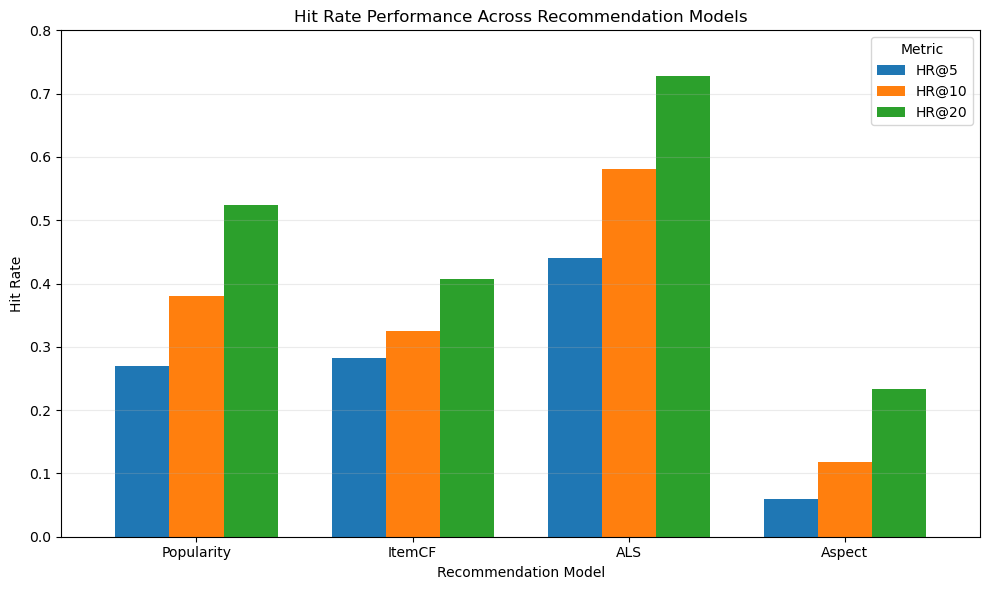

In [234]:
# 3. Figure — Hit Rate comparison

plot_models = [
    "Popularity",
    "ItemCF",
    "ALS",
    "Aspect"
]

hr_plot = (
    final_model_comparison
    .set_index("model")
    .loc[
        plot_models,
        [
            "HR@5",
            "HR@10",
            "HR@20"
        ]
    ]
)


ax = hr_plot.plot(
    kind="bar",
    figsize=(10, 6),
    width=0.75
)

ax.set_title(
    "Hit Rate Performance Across Recommendation Models"
)

ax.set_xlabel(
    "Recommendation Model"
)

ax.set_ylabel(
    "Hit Rate"
)

ax.set_ylim(
    0,
    0.8
)

ax.legend(
    title="Metric"
)

ax.grid(
    axis="y",
    alpha=0.25
)

plt.xticks(
    rotation=0
)

plt.tight_layout()

plt.savefig(
    "figure_final_HR_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## NDCG comparision

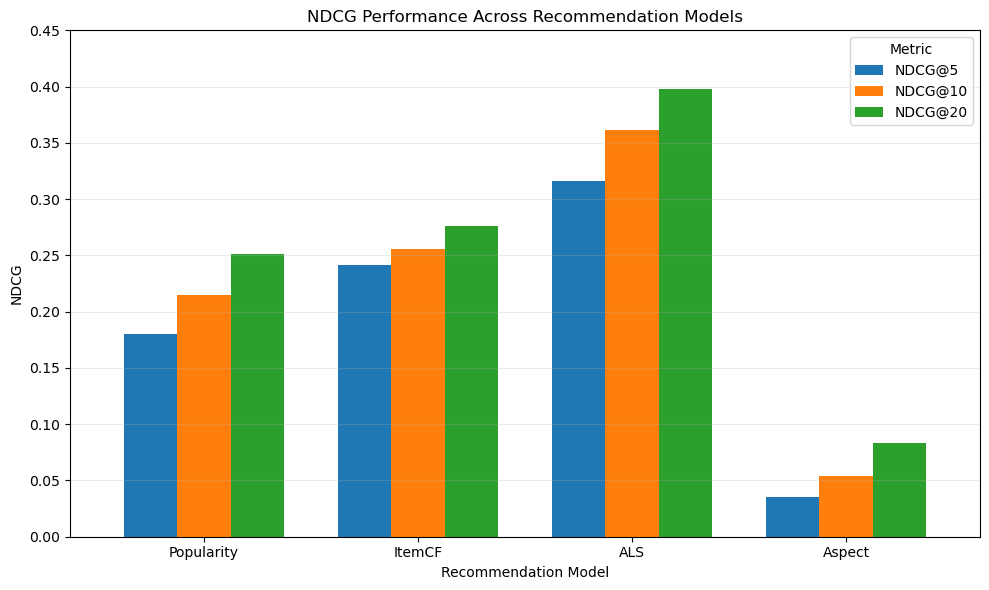

In [235]:
# 4. Figure — NDCG comparison

ndcg_plot = (
    final_model_comparison
    .set_index("model")
    .loc[
        plot_models,
        [
            "NDCG@5",
            "NDCG@10",
            "NDCG@20"
        ]
    ]
)


ax = ndcg_plot.plot(
    kind="bar",
    figsize=(10, 6),
    width=0.75
)

ax.set_title(
    "NDCG Performance Across Recommendation Models"
)

ax.set_xlabel(
    "Recommendation Model"
)

ax.set_ylabel(
    "NDCG"
)

ax.set_ylim(
    0,
    0.45
)

ax.legend(
    title="Metric"
)

ax.grid(
    axis="y",
    alpha=0.25
)

plt.xticks(
    rotation=0
)

plt.tight_layout()

plt.savefig(
    "figure_final_NDCG_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Hybrid weight sensitivity

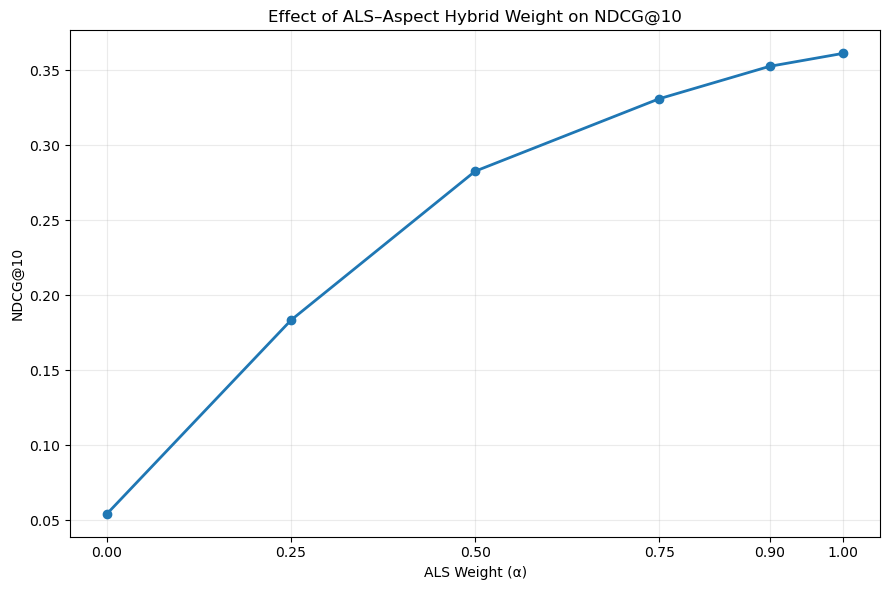

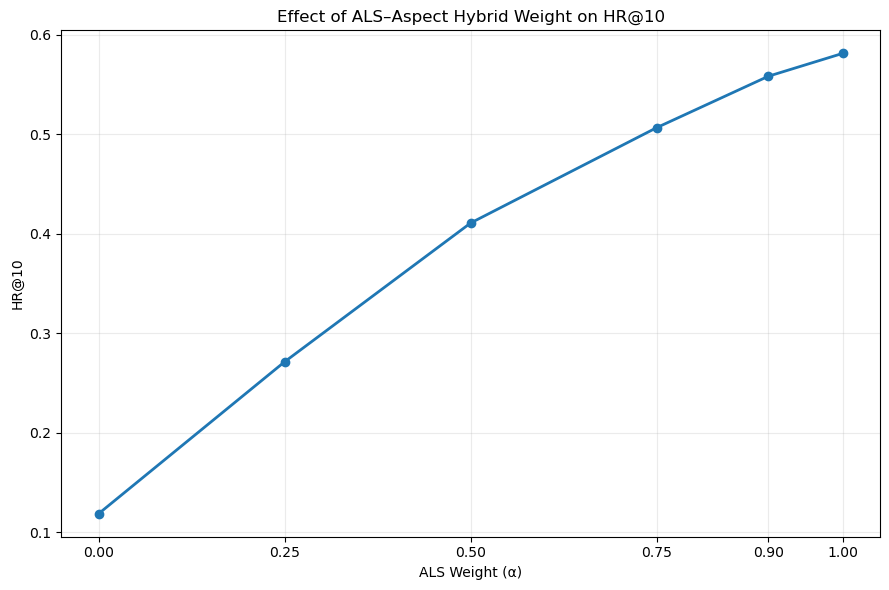

In [236]:
# Hybrid weight sensitivity

hybrid_plot = (
    hybrid_results
    .copy()
    .sort_values(
        "alpha_ALS"
    )
)


# 1. NDCG@10 sensitivity

plt.figure(
    figsize=(9, 6)
)

plt.plot(
    hybrid_plot[
        "alpha_ALS"
    ],
    hybrid_plot[
        "NDCG@10"
    ],
    marker="o",
    linewidth=2
)

plt.xlabel(
    "ALS Weight (α)"
)

plt.ylabel(
    "NDCG@10"
)

plt.title(
    "Effect of ALS–Aspect Hybrid Weight on NDCG@10"
)

plt.xticks(
    hybrid_plot[
        "alpha_ALS"
    ]
)

plt.grid(
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    "figure_hybrid_NDCG10_sensitivity.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# 2. HR@10 sensitivity

plt.figure(
    figsize=(9, 6)
)

plt.plot(
    hybrid_plot[
        "alpha_ALS"
    ],
    hybrid_plot[
        "HR@10"
    ],
    marker="o",
    linewidth=2
)

plt.xlabel(
    "ALS Weight (α)"
)

plt.ylabel(
    "HR@10"
)

plt.title(
    "Effect of ALS–Aspect Hybrid Weight on HR@10"
)

plt.xticks(
    hybrid_plot[
        "alpha_ALS"
    ]
)

plt.grid(
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    "figure_hybrid_HR10_sensitivity.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Explanation quality summary

In [237]:
# Explanation quality summary

explanation_summary = pd.DataFrame(
    {
        "Measure": [
            "Explanation coverage",
            "Positive overall aspect alignment",
            "Positive primary contribution",
            "Primary contribution > secondary",
            "Primary share >= 40%",
            "Primary share >= 50%",
            "Conflict ratio <= 0.50"
        ],

        "Percentage": [
            98.50,
            85.54,
            99.63,
            100.00,
            85.83,
            62.51,
            75.44
        ]
    }
)


display(
    explanation_summary
)


explanation_summary.to_csv(
    "table_explanation_quality.csv",
    index=False
)

,Measure,Percentage
0,Explanation coverage,98.50
1,Positive overall aspect alignment,85.54
2,Positive primary contribution,99.63
3,Primary contribution > secondary,100.00
4,Primary share >= 40%,85.83
5,Primary share >= 50%,62.51
6,Conflict ratio <= 0.50,75.44


## Primary explanation aspect distribution

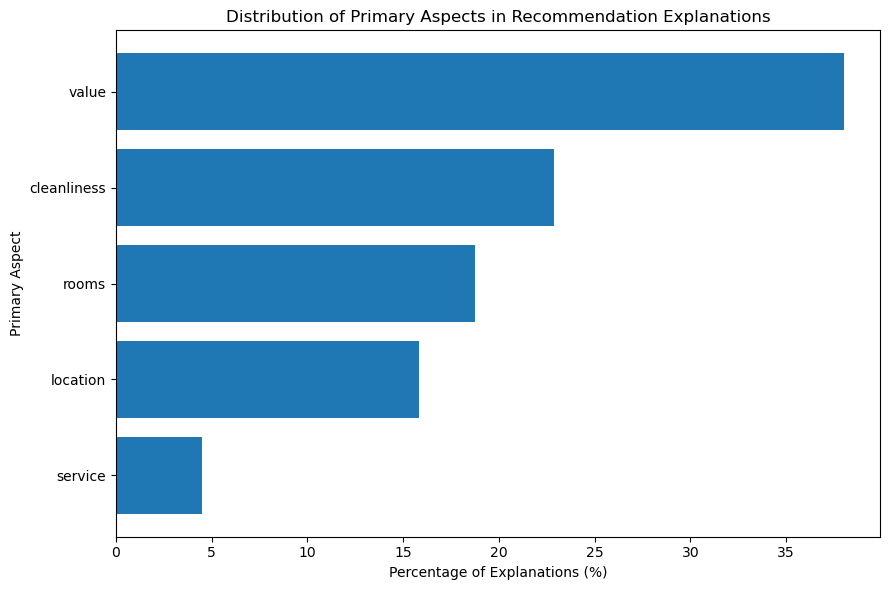

In [238]:
# 5. Primary explanation aspect distribution

primary_plot = (
    primary_distribution
    .copy()
    .sort_values(
        "percentage",
        ascending=True
    )
)


plt.figure(
    figsize=(9, 6)
)

plt.barh(
    primary_plot[
        "aspect"
    ],
    primary_plot[
        "percentage"
    ]
)

plt.xlabel(
    "Percentage of Explanations (%)"
)

plt.ylabel(
    "Primary Aspect"
)

plt.title(
    "Distribution of Primary Aspects in Recommendation Explanations"
)

plt.tight_layout()

plt.savefig(
    "figure_primary_aspect_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Final Results Summary

The results now give a clear picture of the proposed system:

- ALS is the strongest ranking model across every HR and NDCG cutoff.
- At @10:
    - HR @10: 0.5814
    - NDCG@10: 0.3612

- Compared with:
    - Popularity: 0.3801 / 0.2152
    - ItemCF: 0.3245 / 0.2554
    - Aspect-only: 0.1187 / 0.0544

- ALS improves NDCG@10 by 67.81% over Popularity and 41.45% over ItemCF.
- Hybrid experiments show that performance improves consistently as the ALS weight increases, with pure ALS performing best. Adding aspect scores therefore does not improve ranking.

The explanation results are also strong:

- 98.50% explanation coverage
- 85.54% positive aspect alignment
- 99.63% positive primary aspect contribution
- 85.83% have a primary aspect contributing at least 40%
- 62.51% have a primary aspect contributing at least 50%
- Most common primary aspects: Value (38.0%), Cleanliness (22.9%), Rooms (18.8%), Location (15.8%), and Service (4.5%).

**Final System Design**

ALS → Recommendation & Ranking
Aspect Matching → Post-hoc Personalised Explanation

The Aspect model should therefore not be described as a failed model. Its value is in interpretability and understanding user preferences, rather than improving ranking accuracy.

For the dissertation, we will keep the HR/NDCG comparison figures and the hybrid sensitivity figure for now. The hybrid figure is particularly valuable because it directly demonstrates why pure ALS was selected.

## Exporting dissertation-ready tables

In [239]:
# Export dissertation-ready tables

final_model_comparison.to_csv(
    "table_final_model_performance.csv",
    index=False
)

als_relative_improvement.to_csv(
    "table_ALS_relative_improvement.csv",
    index=False
)

hr_significance.to_csv(
    "table_HR_significance.csv",
    index=False
)

ndcg_significance.to_csv(
    "table_NDCG_significance.csv",
    index=False
)

ndcg_bootstrap_ci.to_csv(
    "table_NDCG_confidence_intervals.csv",
    index=False
)

hybrid_results.to_csv(
    "table_hybrid_weight_sensitivity.csv",
    index=False
)

primary_distribution.to_csv(
    "table_primary_aspect_distribution.csv",
    index=False
)


print(
    "Dissertation outputs saved successfully."
)

Dissertation outputs saved successfully.


# Final validation robustness check

The question is:

Does ALS remain the strongest model for users with short, medium, and long interaction histories?

That matters because aggregate performance can hide cases where one model only wins for highly active users.

In [240]:
# Robustness across user interaction-history groups

# 1. Build user training-history counts

user_history_counts = con.execute("""
SELECT
    user_index,
    COUNT(*) AS training_interactions
FROM train_interactions
GROUP BY user_index
""").fetchdf()


print(
    "Users with training history:",
    f"{len(user_history_counts):,}"
)

display(
    user_history_counts[
        "training_interactions"
    ].describe()
)

Users with training history: 2,027,012


count    2.027012e+06
mean     9.082696e+00
std      8.963648e+00
min      1.000000e+00
25%      4.000000e+00
50%      6.000000e+00
75%      1.000000e+01
max      5.790000e+02
Name: training_interactions, dtype: float64

In [241]:
# 2. Attach history size to aligned evaluation results

robustness_df = (
    final_user_results
    .merge(
        user_history_counts,
        on="user_index",
        how="left"
    )
)


print(
    "Evaluation users:",
    f"{len(robustness_df):,}"
)

print(
    "Missing history counts:",
    robustness_df[
        "training_interactions"
    ].isna().sum()
)


robustness_df[
    "training_interactions"
] = (
    robustness_df[
        "training_interactions"
    ]
    .fillna(0)
    .astype(int)
)

Evaluation users: 37,946
Missing history counts: 0


In [242]:
# 3. Create user-history groups

robustness_df[
    "history_group"
] = pd.cut(
    robustness_df[
        "training_interactions"
    ],
    bins=[
        0,
        2,
        5,
        10,
        20,
        np.inf
    ],
    labels=[
        "1-2",
        "3-5",
        "6-10",
        "11-20",
        "21+"
    ],
    include_lowest=True
)


history_counts = (
    robustness_df[
        "history_group"
    ]
    .value_counts()
    .sort_index()
)


print(
    "\nEVALUATION USERS BY HISTORY GROUP"
)

display(
    history_counts
)


EVALUATION USERS BY HISTORY GROUP


history_group
1-2        518
3-5      15661
6-10     12961
11-20     6252
21+       2554
Name: count, dtype: int64

In [243]:
# 4. Model performance by user-history group

models = [
    "Popularity",
    "ItemCF",
    "ALS",
    "Aspect"
]

metrics = [
    "HR@5",
    "NDCG@5",
    "HR@10",
    "NDCG@10",
    "HR@20",
    "NDCG@20"
]


history_performance_rows = []


for history_group, group_df in (
    robustness_df
    .groupby(
        "history_group",
        observed=True
    )
):

    for model in models:

        row = {
            "history_group":
                str(history_group),

            "model":
                model,

            "users":
                len(group_df),

            "mean_training_interactions":
                group_df[
                    "training_interactions"
                ].mean()
        }


        for metric in metrics:

            row[metric] = (
                group_df[
                    f"{model}_{metric}"
                ].mean()
            )


        history_performance_rows.append(
            row
        )


history_model_performance = pd.DataFrame(
    history_performance_rows
)


print(
    "\nMODEL PERFORMANCE BY USER HISTORY"
)

display(
    history_model_performance.round(6)
)


MODEL PERFORMANCE BY USER HISTORY


,history_group,model,users,mean_training_interactions,HR@5,NDCG@5,HR@10,NDCG@10,HR@20,NDCG@20
0,1-2,Popularity,518,1.702703,0.353282,0.211817,0.455598,0.244680,0.600386,0.280857
1,1-2,ItemCF,518,1.702703,0.277992,0.256799,0.332046,0.273861,0.411197,0.294035
2,1-2,ALS,518,1.702703,0.486486,0.360173,0.648649,0.412146,0.783784,0.446314
3,1-2,Aspect,518,1.702703,0.061776,0.036179,0.125483,0.056646,0.249035,0.087361
4,3-5,Popularity,15661,4.293276,0.271375,0.180545,0.377881,0.214839,0.522572,0.251252
5,3-5,ItemCF,15661,4.293276,0.240853,0.211959,0.287338,0.226766,0.377754,0.249470
6,3-5,ALS,15661,4.293276,0.433944,0.311198,0.575442,0.356926,0.724475,0.394665
7,3-5,Aspect,15661,4.293276,0.060341,0.036059,0.116851,0.054147,0.229487,0.082239
8,6-10,Popularity,12961,7.490703,0.269655,0.181031,0.382687,0.217278,0.524574,0.252955
9,6-10,ItemCF,12961,7.490703,0.274362,0.235572,0.313016,0.247821,0.397423,0.268924


In [244]:
# 5. HR@10 robustness table

hr10_history_table = (
    history_model_performance
    .pivot(
        index="history_group",
        columns="model",
        values="HR@10"
    )
    .reindex(
        [
            "1-2",
            "3-5",
            "6-10",
            "11-20",
            "21+"
        ]
    )
)


print(
    "\nHR@10 BY USER HISTORY"
)

display(
    hr10_history_table.round(4)
)


HR@10 BY USER HISTORY


model,ALS,Aspect,ItemCF,Popularity
history_group,,,,
1-2,0.6486,0.1255,0.3320,0.4556
3-5,0.5754,0.1169,0.2873,0.3779
6-10,0.5805,0.1217,0.3130,0.3827
11-20,0.5864,0.1147,0.3762,0.3796
21+,0.5963,0.1226,0.4832,0.3669


In [245]:
# 6. NDCG@10 robustness table

ndcg10_history_table = (
    history_model_performance
    .pivot(
        index="history_group",
        columns="model",
        values="NDCG@10"
    )
    .reindex(
        [
            "1-2",
            "3-5",
            "6-10",
            "11-20",
            "21+"
        ]
    )
)


print(
    "\nNDCG@10 BY USER HISTORY"
)

display(
    ndcg10_history_table.round(4)
)


NDCG@10 BY USER HISTORY


model,ALS,Aspect,ItemCF,Popularity
history_group,,,,
1-2,0.4121,0.0566,0.2739,0.2447
3-5,0.3569,0.0541,0.2268,0.2148
6-10,0.3613,0.0558,0.2478,0.2173
11-20,0.3636,0.0515,0.2949,0.2131
21+,0.3709,0.0554,0.3685,0.2066


In [246]:
# 7. ALS advantage within each history group

als_advantage_rows = []


for history_group, group_df in (
    robustness_df
    .groupby(
        "history_group",
        observed=True
    )
):

    row = {
        "history_group":
            str(history_group),

        "users":
            len(group_df),

        "mean_training_interactions":
            group_df[
                "training_interactions"
            ].mean()
    }


    for metric in [
        "HR@5",
        "NDCG@5",
        "HR@10",
        "NDCG@10",
        "HR@20",
        "NDCG@20"
    ]:

        als_score = (
            group_df[
                f"ALS_{metric}"
            ].mean()
        )


        baseline_scores = {
            model:
                group_df[
                    f"{model}_{metric}"
                ].mean()

            for model in [
                "Popularity",
                "ItemCF",
                "Aspect"
            ]
        }


        best_baseline_model = max(
            baseline_scores,
            key=baseline_scores.get
        )

        best_baseline_score = (
            baseline_scores[
                best_baseline_model
            ]
        )


        row[
            f"ALS_{metric}"
        ] = als_score

        row[
            f"best_baseline_{metric}"
        ] = best_baseline_score

        row[
            f"best_baseline_model_{metric}"
        ] = best_baseline_model

        row[
            f"ALS_advantage_{metric}"
        ] = (
            als_score
            - best_baseline_score
        )


    als_advantage_rows.append(
        row
    )


als_history_advantage = pd.DataFrame(
    als_advantage_rows
)


print(
    "\nALS ADVANTAGE BY HISTORY GROUP"
)

display(
    als_history_advantage.round(6)
)


ALS ADVANTAGE BY HISTORY GROUP


,history_group,users,mean_training_interactions,ALS_HR@5,best_baseline_HR@5,best_baseline_model_HR@5,ALS_advantage_HR@5,ALS_NDCG@5,best_baseline_NDCG@5,best_baseline_model_NDCG@5,...,best_baseline_model_NDCG@10,ALS_advantage_NDCG@10,ALS_HR@20,best_baseline_HR@20,best_baseline_model_HR@20,ALS_advantage_HR@20,ALS_NDCG@20,best_baseline_NDCG@20,best_baseline_model_NDCG@20,ALS_advantage_NDCG@20
0,1-2,518,1.702703,0.486486,0.353282,Popularity,0.133205,0.360173,0.256799,ItemCF,...,ItemCF,0.138286,0.783784,0.600386,Popularity,0.183398,0.446314,0.294035,ItemCF,0.152279
1,3-5,15661,4.293276,0.433944,0.271375,Popularity,0.162569,0.311198,0.211959,ItemCF,...,ItemCF,0.130160,0.724475,0.522572,Popularity,0.201903,0.394665,0.251252,Popularity,0.143412
2,6-10,12961,7.490703,0.441941,0.274362,ItemCF,0.167580,0.316520,0.235572,ItemCF,...,ItemCF,0.113443,0.726256,0.524574,Popularity,0.201682,0.398088,0.268924,ItemCF,0.129164
3,11-20,6252,14.159469,0.447537,0.339891,ItemCF,0.107646,0.318946,0.283198,ItemCF,...,ItemCF,0.068692,0.729367,0.522553,Popularity,0.206814,0.399779,0.312610,ItemCF,0.087170
4,21+,2554,33.345732,0.445967,0.435395,ItemCF,0.010572,0.322581,0.352981,ItemCF,...,ItemCF,0.002444,0.737275,0.536413,ItemCF,0.200861,0.406454,0.381860,ItemCF,0.024594


In [247]:
# 8. Bootstrap 95% CI for ALS performance by history group

rng = np.random.default_rng(42)

bootstrap_iterations = 2000

bootstrap_history_rows = []


for history_group, group_df in (
    robustness_df
    .groupby(
        "history_group",
        observed=True
    )
):

    for metric in [
        "HR@10",
        "NDCG@10"
    ]:

        values = (
            group_df[
                f"ALS_{metric}"
            ]
            .to_numpy(
                dtype=np.float64
            )
        )

        n = len(values)


        bootstrap_means = np.empty(
            bootstrap_iterations,
            dtype=np.float64
        )


        for b in range(
            bootstrap_iterations
        ):

            sample_indices = (
                rng.integers(
                    0,
                    n,
                    size=n
                )
            )

            bootstrap_means[b] = (
                values[
                    sample_indices
                ].mean()
            )


        bootstrap_history_rows.append(
            {
                "history_group":
                    str(history_group),

                "metric":
                    metric,

                "users":
                    n,

                "ALS_mean":
                    values.mean(),

                "CI_95_lower":
                    np.percentile(
                        bootstrap_means,
                        2.5
                    ),

                "CI_95_upper":
                    np.percentile(
                        bootstrap_means,
                        97.5
                    )
            }
        )


als_history_ci = pd.DataFrame(
    bootstrap_history_rows
)


print(
    "\nALS ROBUSTNESS — 95% BOOTSTRAP CI"
)

display(
    als_history_ci.round(6)
)


ALS ROBUSTNESS — 95% BOOTSTRAP CI


,history_group,metric,users,ALS_mean,CI_95_lower,CI_95_upper
0,1-2,HR@10,518,0.648649,0.609990,0.689189
1,1-2,NDCG@10,518,0.412146,0.380178,0.445641
2,3-5,HR@10,15661,0.575442,0.567587,0.583170
3,3-5,NDCG@10,15661,0.356926,0.351284,0.362556
4,6-10,HR@10,12961,0.580511,0.571868,0.588843
5,6-10,NDCG@10,12961,0.361264,0.354893,0.367496
6,11-20,HR@10,6252,0.586372,0.574696,0.598852
7,11-20,NDCG@10,6252,0.363575,0.354647,0.372767
8,21+,HR@10,2554,0.596319,0.577917,0.615897
9,21+,NDCG@10,2554,0.370949,0.356529,0.384858


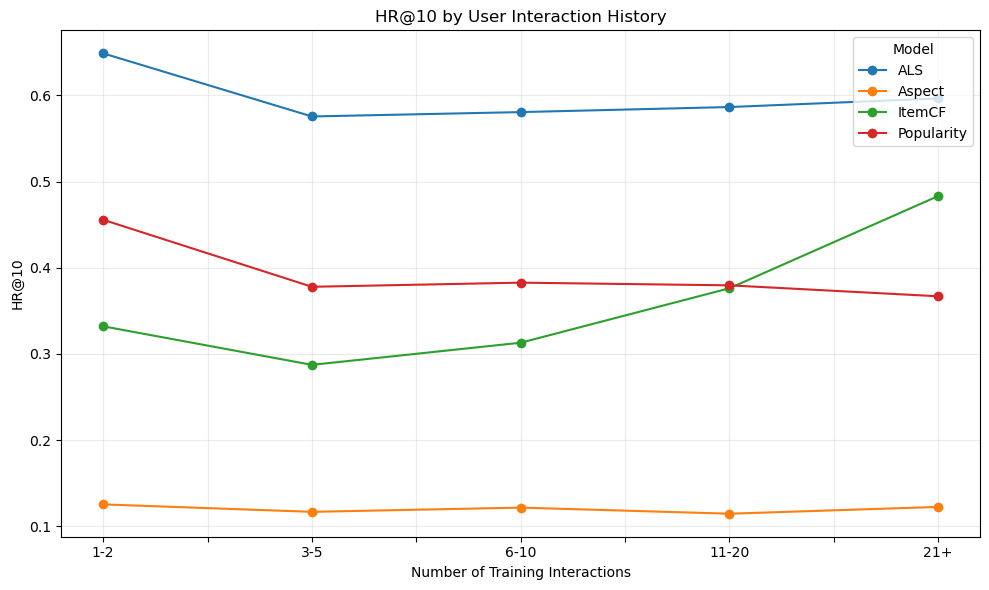

In [248]:
# 9. Figure — HR@10 by history group

history_order = [
    "1-2",
    "3-5",
    "6-10",
    "11-20",
    "21+"
]


hr10_plot = (
    history_model_performance[
        [
            "history_group",
            "model",
            "HR@10"
        ]
    ]
    .pivot(
        index="history_group",
        columns="model",
        values="HR@10"
    )
    .reindex(
        history_order
    )
)


ax = hr10_plot.plot(
    kind="line",
    marker="o",
    figsize=(10, 6)
)

ax.set_title(
    "HR@10 by User Interaction History"
)

ax.set_xlabel(
    "Number of Training Interactions"
)

ax.set_ylabel(
    "HR@10"
)

ax.grid(
    alpha=0.25
)

ax.legend(
    title="Model"
)

plt.tight_layout()

plt.savefig(
    "figure_HR10_by_user_history.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

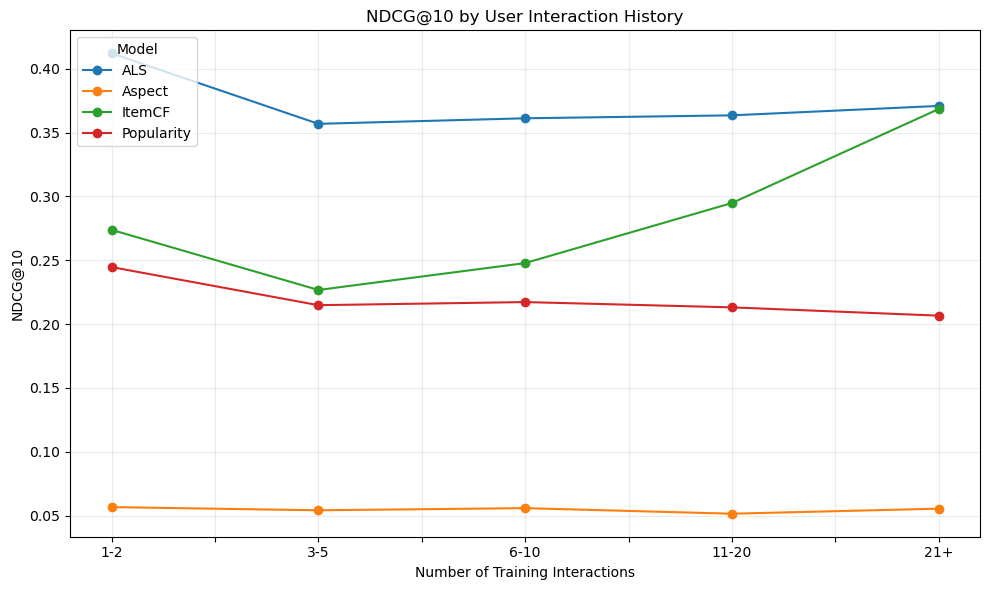

In [249]:
# 10. Figure — NDCG@10 by history group

ndcg10_plot = (
    history_model_performance[
        [
            "history_group",
            "model",
            "NDCG@10"
        ]
    ]
    .pivot(
        index="history_group",
        columns="model",
        values="NDCG@10"
    )
    .reindex(
        history_order
    )
)


ax = ndcg10_plot.plot(
    kind="line",
    marker="o",
    figsize=(10, 6)
)

ax.set_title(
    "NDCG@10 by User Interaction History"
)

ax.set_xlabel(
    "Number of Training Interactions"
)

ax.set_ylabel(
    "NDCG@10"
)

ax.grid(
    alpha=0.25
)

ax.legend(
    title="Model"
)

plt.tight_layout()

plt.savefig(
    "figure_NDCG10_by_user_history.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## SUMMARY

- ALS remains the best model across every user-history group for both HR@10 and NDCG@10.
- For users with 1–2 interactions, ALS performs particularly well:
    - HR@10 = 0.6486
    - Compared with Popularity = 0.4556 and ItemCF = 0.3320.

- For users with 21+ interactions, ItemCF becomes much more competitive:
    - ItemCF NDCG@10 = 0.3685
    - ALS NDCG@10 = 0.3709
    - ALS still wins, but the difference is very small.

- This shows that ALS is robust for both sparse and highly active users, while ItemCF benefits more from having richer user histories.
- Bootstrap confidence intervals support the reliability of the results. Smaller groups have wider intervals because of their smaller sample sizes, but there is no indication that the overall ALS performance is driven by one subgroup.
- Most evaluation users are in the 3–5 and 6–10 interaction groups, so the results should be interpreted with the subgroup sizes in mind.

**Final Technical Conclusion**

The evaluation is now sufficiently comprehensive, covering baseline comparisons, statistical significance, confidence intervals, hybrid sensitivity, aspect analysis, explanation validation, and user-history robustness.

Therefore:

ALS-64 → Final ranking model
Aspect information → Post-hoc explanation layer